# Pipeline radiomics para tesis/piloto con datos desbalanceados

Este notebook carga un CSV de características radiómicas, hace análisis exploratorio, revisa calidad de datos, analiza familias radiómicas, entrena varios modelos con técnicas para desbalance, busca hiperparámetros y exporta tablas a Excel.

**Nuevo:** incluye checkpoints persistentes en Google Drive. Si Colab se desconecta o cierras la tapa del computador, puedes volver a ejecutar el notebook y reutilizar resultados ya guardados: métricas por fold, mejores hiperparámetros, modelos finales entrenados, tablas de características y archivos Excel/CSV.

**Supuesto principal:** la columna objetivo se llama `y`, donde `1` es caso/target y `0` es control. Cambia `TARGET_COL` y `POS_LABEL` si tu archivo usa otros nombres.

In [ ]:
# ==========================================
# 1) Instalar librerías en Colab
# ==========================================
!pip -q install imbalanced-learn xgboost openpyxl shap


In [ ]:
# ==========================================
# 2) Importar librerías
# ==========================================
import os
import re
import json
import shutil
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    ParameterGrid,
    cross_val_predict
)
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    confusion_matrix,
    brier_score_loss,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

from xgboost import XGBClassifier

import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [ ]:
# ==========================================
# 3) Configuración principal
# ==========================================
TARGET_COL = "y"        # Columna objetivo
POS_LABEL = 1           # Clase positiva/casos
ID_CANDIDATES = ["id", "ID", "Id", "segmentation", "Segmentation", "seg_id", "patient_id", "Paciente", "paciente"]

RANDOM_STATE = 42

# Para piloto/desbalance fuerte:
# Se recomienda optimizar por average_precision / PR-AUC y no por accuracy.
MAIN_SCORING = "average_precision"

# Ajusta según tu computador/Colab.
N_ITER_SEARCH = 30      # Más alto = mejor búsqueda, pero tarda más
MAX_TOP_FEATURES = 30   # Número de características principales a reportar por modelo
CORR_THRESHOLD_DEFAULT = 0.90

# Umbral de clasificación:
# "f2" prioriza sensibilidad; "f1" balancea precisión/sensibilidad; "balanced_accuracy" balancea sensibilidad/especificidad.
THRESHOLD_METRIC = "f2"

# Si hay duplicados exactos de características:
DROP_DUPLICATED_FEATURE_ROWS = True

# Si hay filas con mismas features pero distinto target, lo más conservador es removerlas.
DROP_CONFLICTING_DUPLICATES = True

## Checkpoints en Google Drive

Ejecuta esta celda después de la configuración. Crea una carpeta fija en Drive para guardar resultados parciales y finales. Si la sesión se corta, vuelve a ejecutar desde el inicio hasta las celdas de entrenamiento; el notebook detectará archivos existentes y saltará lo ya calculado.

In [ ]:
# ==========================================
# 3B) Checkpoints persistentes en Google Drive
# ==========================================

# Cambia RUN_NAME si quieres crear una corrida nueva desde cero.
# Mantén el mismo RUN_NAME si quieres reanudar resultados previos.
RUN_NAME = "radiomica_piloto_desbalanceado_v1"

# Si True, guarda y carga checkpoints desde Google Drive.
USE_GOOGLE_DRIVE = True

# Si True, cuando un fold/modelo ya existe en Drive, lo carga y lo salta.
RESUME_FROM_CHECKPOINTS = True

# Si True, además guarda modelos finales entrenados en .joblib.
SAVE_FINAL_MODELS = True

# Carpeta base en Drive.
CHECKPOINT_BASE_DIR = "/content/drive/MyDrive/radiomica_colab_checkpoints"

try:
    from google.colab import drive
    if USE_GOOGLE_DRIVE:
        drive.mount("/content/drive")
        BASE_RESULTS_DIR = Path(CHECKPOINT_BASE_DIR) / RUN_NAME
    else:
        BASE_RESULTS_DIR = Path("/content") / "radiomica_colab_checkpoints" / RUN_NAME
except Exception as e:
    print("No se pudo montar Drive. Se usará almacenamiento temporal de Colab.")
    print("Detalle:", e)
    BASE_RESULTS_DIR = Path("/content") / "radiomica_colab_checkpoints" / RUN_NAME

FOLD_DIR = BASE_RESULTS_DIR / "folds"
FINAL_MODEL_DIR = BASE_RESULTS_DIR / "final_models"
TABLE_DIR = BASE_RESULTS_DIR / "tables"
EXPORT_DIR = BASE_RESULTS_DIR / "exports"

for d in [BASE_RESULTS_DIR, FOLD_DIR, FINAL_MODEL_DIR, TABLE_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Carpeta de resultados:", BASE_RESULTS_DIR)


def safe_name(name):
    """Nombre seguro para archivos."""
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", str(name))


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def save_table(df_table, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if isinstance(df_table, pd.DataFrame):
        df_table.to_csv(path, index=False)
    else:
        pd.DataFrame(df_table).to_csv(path, index=False)


def load_table(path):
    return pd.read_csv(path)


def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(obj, path)


def load_pickle(path):
    return joblib.load(path)


def checkpoint_exists(path):
    return Path(path).exists()


def fold_metric_path(model_name, fold_id):
    return FOLD_DIR / f"{safe_name(model_name)}__fold_{fold_id:02d}__metrics.json"


def fold_param_path(model_name, fold_id):
    return FOLD_DIR / f"{safe_name(model_name)}__fold_{fold_id:02d}__best_params.json"


def final_model_path(model_name):
    return FINAL_MODEL_DIR / f"{safe_name(model_name)}__final_model.joblib"


def final_feature_path(model_name):
    return FINAL_MODEL_DIR / f"{safe_name(model_name)}__final_features.csv"


def final_param_path(model_name):
    return FINAL_MODEL_DIR / f"{safe_name(model_name)}__final_params.json"


def export_all_tables(tables_dict, excel_name="resultados_radiomica_colab.xlsx"):
    """
    Exporta tablas a:
    1) Excel consolidado
    2) CSV individual por tabla
    3) Copia con timestamp
    """
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    TABLE_DIR.mkdir(parents=True, exist_ok=True)

    excel_path = EXPORT_DIR / excel_name
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    excel_timestamp_path = EXPORT_DIR / f"{Path(excel_name).stem}_{timestamp}.xlsx"

    valid_tables = {}
    for sheet, table in tables_dict.items():
        if table is not None and isinstance(table, pd.DataFrame) and len(table) > 0:
            valid_tables[sheet] = table.copy()
            csv_path = TABLE_DIR / f"{safe_name(sheet)}.csv"
            table.to_csv(csv_path, index=False)

    if len(valid_tables) == 0:
        print("No hay tablas para exportar todavía.")
        return None

    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        for sheet, table in valid_tables.items():
            table.to_excel(writer, sheet_name=sheet[:31], index=False)

    shutil.copy2(excel_path, excel_timestamp_path)

    manifest = {
        "run_name": RUN_NAME,
        "created_at": timestamp,
        "base_results_dir": str(BASE_RESULTS_DIR),
        "excel_path": str(excel_path),
        "excel_timestamp_path": str(excel_timestamp_path),
        "tables": list(valid_tables.keys())
    }
    save_json(manifest, EXPORT_DIR / "manifest_ultima_exportacion.json")

    print("Excel principal guardado en:", excel_path)
    print("Copia con timestamp guardada en:", excel_timestamp_path)
    print("CSV individuales guardados en:", TABLE_DIR)
    return excel_path


def load_previous_cv_results():
    """Carga métricas y parámetros de folds ya guardados."""
    metric_rows = []
    param_rows = []

    for p in sorted(FOLD_DIR.glob("*__metrics.json")):
        try:
            metric_rows.append(load_json(p))
        except Exception as e:
            print("No se pudo cargar", p, e)

    for p in sorted(FOLD_DIR.glob("*__best_params.json")):
        try:
            param_rows.append(load_json(p))
        except Exception as e:
            print("No se pudo cargar", p, e)

    fold_metrics_prev = pd.DataFrame(metric_rows)
    best_params_prev = pd.DataFrame(param_rows)

    print("Folds previos encontrados:", len(fold_metrics_prev))
    print("Parámetros previos encontrados:", len(best_params_prev))
    return fold_metrics_prev, best_params_prev


def load_previous_final_models_summary():
    """Carga tablas de features/parámetros de modelos finales ya guardados."""
    feature_tables = []
    param_rows = []

    for p in sorted(FINAL_MODEL_DIR.glob("*__final_features.csv")):
        try:
            feature_tables.append(pd.read_csv(p))
        except Exception as e:
            print("No se pudo cargar", p, e)

    for p in sorted(FINAL_MODEL_DIR.glob("*__final_params.json")):
        try:
            param_rows.append(load_json(p))
        except Exception as e:
            print("No se pudo cargar", p, e)

    features_prev = pd.concat(feature_tables, ignore_index=True) if len(feature_tables) else pd.DataFrame()
    params_prev = pd.DataFrame(param_rows)

    print("Tablas de features finales previas:", len(feature_tables))
    print("Parámetros finales previos:", len(params_prev))
    return features_prev, params_prev


def show_checkpoint_status():
    print("Base:", BASE_RESULTS_DIR)
    print("Folds guardados:", len(list(FOLD_DIR.glob("*__metrics.json"))))
    print("Modelos finales guardados:", len(list(FINAL_MODEL_DIR.glob("*__final_model.joblib"))))
    print("Tablas CSV guardadas:", len(list(TABLE_DIR.glob("*.csv"))))
    print("Excels exportados:", len(list(EXPORT_DIR.glob("*.xlsx"))))

show_checkpoint_status()

Mounted at /content/drive
Carpeta de resultados: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1
Base: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1
Folds guardados: 45
Modelos finales guardados: 9
Tablas CSV guardadas: 19
Excels exportados: 2


In [ ]:
# ==========================================
# 4) Cargar dataset desde Google Drive
# ==========================================
# El dataset de trabajo se mantiene en Drive y NO se sube a GitHub.
# Archivo: radiomica_pancreas_dataset_semana3.csv

from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

DATA_PATH = Path("/content/drive/MyDrive/radiomica_pancreas_dataset_semana3.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en {DATA_PATH}. "
        "Verifica que el archivo esté en la raíz de 'Mi unidad' con ese nombre."
    )

# Lectura robusta
try:
    df_raw = pd.read_csv(DATA_PATH, sep=None, engine="python")
except Exception:
    df_raw = pd.read_csv(DATA_PATH, sep=";")

if df_raw.shape[1] == 1:
    df_raw = pd.read_csv(DATA_PATH, sep=";")

print("Dataset:", DATA_PATH)
print("Dimensiones originales:", df_raw.shape)
display(df_raw.head())


Saving radiomica avamce 29 abril .csv to radiomica avamce 29 abril .csv
Archivo cargado: radiomica avamce 29 abril .csv
Dimensiones originales: (151, 109)


,seg_id,1_shape_elongation,1_shape_flatness,1_shape_leastaxislength,1_shape_majoraxislength,1_shape_maximum2ddiametercolumn,1_shape_maximum2ddiameterrow,1_shape_maximum2ddiameterslice,1_shape_maximum3ddiameter,1_shape_meshvolume,1_shape_minoraxislength,1_shape_sphericity,1_shape_surfacearea,1_shape_surfacevolumeratio,1_shape_voxelvolume,2_firstorder_10percentile,2_firstorder_90percentile,2_firstorder_energy,2_firstorder_entropy,2_firstorder_interquartilerange,2_firstorder_kurtosis,2_firstorder_maximum,2_firstorder_mean,2_firstorder_meanabsolutedeviation,2_firstorder_median,2_firstorder_minimum,2_firstorder_range,2_firstorder_robustmeanabsolutedeviation,2_firstorder_rootmeansquared,2_firstorder_skewness,2_firstorder_totalenergy,2_firstorder_uniformity,2_firstorder_variance,3_glcm_autocorrelation,3_glcm_clusterprominence,3_glcm_clustershade,3_glcm_clustertendency,3_glcm_contrast,3_glcm_correlation,3_glcm_differenceaverage,3_glcm_differenceentropy,3_glcm_differencevariance,3_glcm_id,3_glcm_idm,3_glcm_idmn,3_glcm_idn,3_glcm_imc1,3_glcm_imc2,3_glcm_inversevariance,3_glcm_jointaverage,3_glcm_jointenergy,3_glcm_jointentropy,3_glcm_mcc,3_glcm_maximumprobability,3_glcm_sumaverage,3_glcm_sumentropy,3_glcm_sumsquares,4_glrlm_graylevelnonuniformity,4_glrlm_graylevelnonuniformitynormalized,4_glrlm_graylevelvariance,4_glrlm_highgraylevelrunemphasis,4_glrlm_longrunemphasis,4_glrlm_longrunhighgraylevelemphasis,4_glrlm_longrunlowgraylevelemphasis,4_glrlm_lowgraylevelrunemphasis,4_glrlm_runentropy,4_glrlm_runlengthnonuniformity,4_glrlm_runlengthnonuniformitynormalized,4_glrlm_runpercentage,4_glrlm_runvariance,4_glrlm_shortrunemphasis,4_glrlm_shortrunhighgraylevelemphasis,4_glrlm_shortrunlowgraylevelemphasis,5_glszm_graylevelnonuniformity,5_glszm_graylevelnonuniformitynormalized,5_glszm_graylevelvariance,5_glszm_highgraylevelzoneemphasis,5_glszm_largeareaemphasis,5_glszm_largeareahighgraylevelemphasis,5_glszm_largearealowgraylevelemphasis,5_glszm_lowgraylevelzoneemphasis,5_glszm_sizezonenonuniformity,5_glszm_sizezonenonuniformitynormalized,5_glszm_smallareaemphasis,5_glszm_smallareahighgraylevelemphasis,5_glszm_smallarealowgraylevelemphasis,5_glszm_zoneentropy,5_glszm_zonepercentage,5_glszm_zonevariance,6_gldm_dependenceentropy,6_gldm_dependencenonuniformity,6_gldm_dependencenonuniformitynormalized,6_gldm_dependencevariance,6_gldm_graylevelnonuniformity,6_gldm_graylevelvariance,6_gldm_highgraylevelemphasis,6_gldm_largedependenceemphasis,6_gldm_largedependencehighgraylevelemphasis,6_gldm_largedependencelowgraylevelemphasis,6_gldm_lowgraylevelemphasis,6_gldm_smalldependenceemphasis,6_gldm_smalldependencehighgraylevelemphasis,6_gldm_smalldependencelowgraylevelemphasis,7_ngtdm_busyness,7_ngtdm_coarseness,7_ngtdm_complexity,7_ngtdm_contrast,7_ngtdm_strength,y
0,Seg_00001,0.356414,0.268099,39.083861,145.781570,95.763080,69.842451,93.749249,146.052042,86853.31548,51.958590,0.475943,19927.51595,0.229439,86915.59501,5,87,686689516,2.483627,42,4.168776,273,46.882111,25.884210,48,-219,492,17.614764,57.643580,-0.367907,2.888016e+08,0.216049,1124.849957,131.723337,117.785454,-3.858947,5.522835,1.539346,0.562209,0.892988,1.680291,0.722266,0.642364,0.615869,0.996208,0.958826,-0.126029,0.649174,0.489787,11.433607,0.062035,4.578412,0.566630,0.120008,22.867214,3.259355,1.765545,27315.216700,0.199628,2.172910,131.177747,3.295558,436.149848,0.026230,0.008246,3.961169,70277.46823,0.506612,0.662013,0.916931,0.733927,95.852903,0.006141,634.789078,0.125601,8.054382,123.049664,1.672903e+06,2.227944e+08,12789.842710,0.011215,1010.519193,0.199944,0.443884,53.086438,0.005239,6.444835,0.024456,1.671231e+06,6.453885,13349.336610,0.064595,18.308600,44648.94764,1.886314,131.743246,114.107021,15183.13545,0.889248,0.008115,0.032934,4.120944,0.000325,60.716778,0.000046,115.309117,0.005969,0.011569,1
1,Seg_00004,0.474868,0.260336,29.386635,112.879592,89.823265,70.656494,93.674090,120.273380,54612.65087,53.602921,0.471418,14766.37294,0.270384,54671.84830,36,98,995909461,2.135072,30

In [ ]:
# ==========================================
# 5) Detectar columnas, limpiar target y preparar X/y
# ==========================================
df = df_raw.copy()

# Limpiar nombres de columnas
df.columns = [str(c).strip() for c in df.columns]

if TARGET_COL not in df.columns:
    raise ValueError(f"No encuentro la columna target '{TARGET_COL}'. Columnas disponibles: {list(df.columns)}")

# Detectar columna ID si existe
id_cols = [c for c in df.columns if c in ID_CANDIDATES or "id" in c.lower() or "seg" in c.lower()]
ID_COL = id_cols[0] if len(id_cols) > 0 else None
print("Columna ID detectada:", ID_COL)

# Convertir target a binario 0/1
y_original = df[TARGET_COL]
y = (y_original == POS_LABEL).astype(int)

# Detectar columnas numéricas como features, excluyendo target e ID
exclude_cols = [TARGET_COL]
if ID_COL is not None:
    exclude_cols.append(ID_COL)

candidate_features = [c for c in df.columns if c not in exclude_cols]

# Intentar convertir features a numérico
for c in candidate_features:
    df[c] = pd.to_numeric(df[c], errors="coerce")

feature_cols = [c for c in candidate_features if pd.api.types.is_numeric_dtype(df[c])]
X = df[feature_cols].copy()

print("Número de features numéricas:", len(feature_cols))
print("Distribución del target:")
balance_table = pd.DataFrame({
    "clase": [0, 1],
    "n": [(y == 0).sum(), (y == 1).sum()],
    "porcentaje": [(y == 0).mean()*100, (y == 1).mean()*100]
})
display(balance_table)

if (y == 1).sum() == 0 or (y == 0).sum() == 0:
    raise ValueError("El target tiene una sola clase. No se puede entrenar un modelo binario.")

prevalence = y.mean()
print(f"Prevalencia de clase positiva: {prevalence:.4f} = {prevalence*100:.2f}%")
print(f"Baseline PR-AUC esperado por azar ≈ prevalencia = {prevalence:.4f}")

Columna ID detectada: seg_id
Número de features numéricas: 107
Distribución del target:


,clase,n,porcentaje
0,0,62,41.059603
1,1,89,58.940397


Prevalencia de clase positiva: 0.5894 = 58.94%
Baseline PR-AUC esperado por azar ≈ prevalencia = 0.5894


In [ ]:
# ==========================================
# 6) Funciones auxiliares
# ==========================================

def parse_radiomics_feature(col):
    '''
    Intenta separar familia radiomics y nombre específico.
    Ejemplos:
    2_firstorder_median -> familia firstorder, característica median
    3_glcm_correlation -> familia glcm, característica correlation
    '''
    s = str(col).strip()
    s2 = re.sub(r"^\d+_", "", s.lower())
    known_families = ["firstorder", "shape", "shape2d", "shape3d", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]
    for fam in known_families:
        if s2 == fam or s2.startswith(fam + "_"):
            char = s2.replace(fam + "_", "", 1)
            return fam, char
    parts = s2.split("_")
    if len(parts) >= 2:
        return parts[0], "_".join(parts[1:])
    return "unknown", s2


def benjamini_hochberg(pvalues):
    '''FDR Benjamini-Hochberg sin depender de statsmodels.'''
    p = np.asarray(pvalues, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty(n)
    out[order] = q
    return out


def cliffs_delta(x, y):
    '''Tamaño de efecto no paramétrico. Positivo = valores más altos en casos.'''
    x = np.asarray(x)
    y = np.asarray(y)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0:
        return np.nan
    # Cálculo eficiente razonable para datasets pequeños/medianos.
    gt = sum(np.sum(xi > y) for xi in x)
    lt = sum(np.sum(xi < y) for xi in x)
    return (gt - lt) / (len(x) * len(y))


class CorrelationFilter(BaseEstimator, TransformerMixin):
    '''
    Filtro no supervisado para eliminar features altamente correlacionadas.
    Se ajusta dentro de cada fold para evitar leakage.
    '''
    def __init__(self, threshold=0.90):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = np.asarray(X)
        n_features = X.shape[1]
        if self.threshold is None or self.threshold >= 1 or n_features <= 1:
            self.keep_mask_ = np.ones(n_features, dtype=bool)
            return self

        corr = pd.DataFrame(X).corr().abs().fillna(0).values
        upper = np.triu(corr, k=1)
        to_drop = np.where((upper > self.threshold).any(axis=0))[0]
        keep = np.ones(n_features, dtype=bool)
        keep[to_drop] = False
        self.keep_mask_ = keep
        return self

    def transform(self, X):
        return np.asarray(X)[:, self.keep_mask_]


def get_scores(estimator, X):
    '''Obtiene score continuo para ROC/PR.'''
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    return estimator.predict(X)


def safe_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan


def safe_ap(y_true, y_score):
    try:
        return average_precision_score(y_true, y_score)
    except Exception:
        return np.nan


def choose_threshold(y_true, y_score, metric="f2"):
    '''
    Elige umbral usando solo datos de entrenamiento.
    Para datos muy desbalanceados, f2 suele ser útil si quieres no perder casos.
    '''
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    if len(thresholds) == 0:
        return 0.5

    rows = []
    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        if metric == "f1":
            value = f1_score(y_true, pred, zero_division=0)
        elif metric == "f2":
            value = fbeta_score(y_true, pred, beta=2, zero_division=0)
        elif metric == "balanced_accuracy":
            value = balanced_accuracy_score(y_true, pred)
        else:
            value = f1_score(y_true, pred, zero_division=0)
        rows.append((thr, value))

    best_thr, best_value = sorted(rows, key=lambda z: z[1], reverse=True)[0]
    return float(best_thr)


def compute_metrics(y_true, y_score, threshold=0.5):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)

    labels = [0, 1]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=labels).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    return {
        "roc_auc": safe_auc(y_true, y_score),
        "pr_auc": safe_ap(y_true, y_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_ppv": precision_score(y_true, y_pred, zero_division=0),
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred) if len(np.unique(y_pred)) > 1 else 0,
        "brier": brier_score_loss(y_true, y_score) if np.all((np.asarray(y_score) >= 0) & (np.asarray(y_score) <= 1)) else np.nan,
        "threshold": threshold,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp
    }


def summarize_cv_results(fold_table):
    metric_cols = [
        "roc_auc", "pr_auc", "accuracy", "balanced_accuracy",
        "precision_ppv", "sensitivity_recall", "specificity",
        "f1", "f2", "mcc", "brier"
    ]
    rows = []
    for model, g in fold_table.groupby("model"):
        row = {"model": model, "n_folds": len(g)}
        for m in metric_cols:
            row[m + "_mean"] = g[m].mean()
            row[m + "_std"] = g[m].std()
        rows.append(row)
    return pd.DataFrame(rows).sort_values("pr_auc_mean", ascending=False)


def get_feature_names_after_pipeline(fitted_pipe, original_feature_names):
    '''
    Recupera nombres tras VarianceThreshold -> SelectKBest -> CorrelationFilter.
    '''
    names = np.array(original_feature_names)

    if "variance" in fitted_pipe.named_steps:
        vt = fitted_pipe.named_steps["variance"]
        if hasattr(vt, "get_support"):
            names = names[vt.get_support()]

    if "select" in fitted_pipe.named_steps:
        sel = fitted_pipe.named_steps["select"]
        if hasattr(sel, "get_support"):
            names = names[sel.get_support()]

    if "corr" in fitted_pipe.named_steps:
        corr = fitted_pipe.named_steps["corr"]
        if hasattr(corr, "keep_mask_"):
            names = names[corr.keep_mask_]

    return list(names)


def extract_model_features(fitted_pipe, original_feature_names, model_name, top_n=30):
    '''
    Extrae importancia interna del modelo:
    - coeficientes para modelos lineales
    - feature_importances_ para árboles
    '''
    names = get_feature_names_after_pipeline(fitted_pipe, original_feature_names)
    model = fitted_pipe.named_steps["model"]

    importance = None
    direction = None
    source = None

    if hasattr(model, "coef_"):
        coef = np.ravel(model.coef_)
        importance = np.abs(coef)
        direction = coef
        source = "coeficiente"
    elif hasattr(model, "feature_importances_"):
        importance = np.asarray(model.feature_importances_)
        direction = importance
        source = "feature_importance"
    else:
        return pd.DataFrame()

    n = min(len(names), len(importance))
    out = pd.DataFrame({
        "model": model_name,
        "feature": names[:n],
        "importance_abs": importance[:n],
        "direction_or_raw_value": direction[:n],
        "importance_source": source
    })

    fam_char = out["feature"].apply(parse_radiomics_feature)
    out["family"] = fam_char.apply(lambda z: z[0])
    out["radiomic_characteristic"] = fam_char.apply(lambda z: z[1])
    out = out.sort_values("importance_abs", ascending=False).head(top_n)
    return out


def make_search(estimator, param_grid, inner_cv):
    candidates = list(ParameterGrid(param_grid))
    if len(candidates) <= N_ITER_SEARCH:
        return GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=MAIN_SCORING,
            cv=inner_cv,
            n_jobs=-1,
            refit=True
        )
    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        n_iter=N_ITER_SEARCH,
        scoring=MAIN_SCORING,
        cv=inner_cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True
    )

In [ ]:
# ==========================================
# 7) Calidad de datos, duplicados y familias radiomics
# ==========================================

quality_rows = []

quality_rows.append({"item": "filas_originales", "valor": df.shape[0]})
quality_rows.append({"item": "columnas_originales", "valor": df.shape[1]})
quality_rows.append({"item": "n_features_numericas", "valor": len(feature_cols)})
quality_rows.append({"item": "casos_positivos", "valor": int((y == 1).sum())})
quality_rows.append({"item": "controles_negativos", "valor": int((y == 0).sum())})
quality_rows.append({"item": "prevalencia_positiva_pct", "valor": y.mean() * 100})
quality_rows.append({"item": "faltantes_totales_features", "valor": int(X.isna().sum().sum())})
quality_rows.append({"item": "features_con_faltantes", "valor": int((X.isna().sum() > 0).sum())})
quality_rows.append({"item": "duplicados_filas_completas", "valor": int(df.duplicated().sum())})

if ID_COL is not None:
    quality_rows.append({"item": f"ids_duplicados_en_{ID_COL}", "valor": int(df[ID_COL].duplicated().sum())})

# Duplicados por matriz X
dup_feature_mask = X.duplicated(keep=False)
n_dup_feature_rows = int(dup_feature_mask.sum())
quality_rows.append({"item": "filas_con_features_duplicadas", "valor": n_dup_feature_rows})

# Grupos de features duplicadas con target conflictivo
tmp_dup = pd.concat([X, y.rename("__target__")], axis=1)
group_counts = tmp_dup.groupby(feature_cols, dropna=False)["__target__"].nunique().reset_index(name="n_targets")
conflicting_feature_groups = group_counts[group_counts["n_targets"] > 1]
quality_rows.append({"item": "grupos_features_duplicadas_con_target_conflictivo", "valor": len(conflicting_feature_groups)})

quality_table = pd.DataFrame(quality_rows)
display(quality_table)

# Tabla de familias
feature_meta = pd.DataFrame({"feature": feature_cols})
feature_meta[["family", "radiomic_characteristic"]] = feature_meta["feature"].apply(
    lambda c: pd.Series(parse_radiomics_feature(c))
)
family_count_table = (
    feature_meta.groupby("family")
    .agg(
        n_features=("feature", "count"),
        ejemplos=("feature", lambda s: ", ".join(list(s.head(5))))
    )
    .reset_index()
    .sort_values("n_features", ascending=False)
)
display(family_count_table)

# Limpieza conservadora de duplicados
df_model = df.copy()
y_model = y.copy()
X_model = X.copy()

if DROP_CONFLICTING_DUPLICATES and len(conflicting_feature_groups) > 0:
    # Marcar filas cuyo patrón de features aparece con targets distintos
    conflict_keys = set(map(tuple, conflicting_feature_groups[feature_cols].to_numpy()))
    row_keys = list(map(tuple, X_model[feature_cols].to_numpy()))
    conflict_mask = pd.Series([rk in conflict_keys for rk in row_keys], index=df_model.index)
    print("Removiendo filas conflictivas por mismas features con distinto target:", int(conflict_mask.sum()))
    df_model = df_model.loc[~conflict_mask].copy()
    X_model = X_model.loc[~conflict_mask].copy()
    y_model = y_model.loc[~conflict_mask].copy()

if DROP_DUPLICATED_FEATURE_ROWS:
    before = len(df_model)
    keep_mask = ~X_model.duplicated(keep="first")
    df_model = df_model.loc[keep_mask].copy()
    X_model = X_model.loc[keep_mask].copy()
    y_model = y_model.loc[keep_mask].copy()
    print("Filas removidas por features duplicadas exactas:", before - len(df_model))

print("Dimensiones para modelado:", X_model.shape)
print("Distribución final para modelado:")
display(pd.DataFrame({
    "clase": [0, 1],
    "n": [(y_model == 0).sum(), (y_model == 1).sum()],
    "porcentaje": [(y_model == 0).mean()*100, (y_model == 1).mean()*100]
}))

,item,valor
0,filas_originales,151.000000
1,columnas_originales,109.000000
2,n_features_numericas,107.000000
3,casos_positivos,89.000000
4,controles_negativos,62.000000
5,prevalencia_positiva_pct,58.940397
6,faltantes_totales_features,0.000000
7,features_con_faltantes,0.000000
8,duplicados_filas_completas,0.000000
9,ids_duplicados_en_seg_id,1.000000


,family,n_features,ejemplos
1,glcm,24,"3_glcm_autocorrelation, 3_glcm_clusterprominen..."
0,firstorder,18,"2_firstorder_10percentile, 2_firstorder_90perc..."
3,glrlm,16,"4_glrlm_graylevelnonuniformity, 4_glrlm_grayle..."
4,glszm,16,"5_glszm_graylevelnonuniformity, 5_glszm_grayle..."
2,gldm,14,"6_gldm_dependenceentropy, 6_gldm_dependencenon..."
6,shape,14,"1_shape_elongation, 1_shape_flatness, 1_shape_..."
5,ngtdm,5,"7_ngtdm_busyness, 7_ngtdm_coarseness, 7_ngtdm_..."


Removiendo filas conflictivas por mismas features con distinto target: 4
Filas removidas por features duplicadas exactas: 3
Dimensiones para modelado: (144, 107)
Distribución final para modelado:


,clase,n,porcentaje
0,0,58,40.277778
1,1,86,59.722222


In [ ]:
# ==========================================
# 8) Análisis univariado de features
# ==========================================

univar_rows = []

for feat in feature_cols:
    x0 = X_model.loc[y_model == 0, feat].astype(float)
    x1 = X_model.loc[y_model == 1, feat].astype(float)

    # Imputación simple solo para estadística univariada
    all_values = X_model[feat].astype(float)
    med = all_values.median()
    x0 = x0.fillna(med)
    x1 = x1.fillna(med)

    # Mann-Whitney
    try:
        stat, p = mannwhitneyu(x1, x0, alternative="two-sided")
    except Exception:
        stat, p = np.nan, np.nan

    # AUC univariado
    try:
        scores = X_model[feat].astype(float).fillna(med).values
        auc_raw = roc_auc_score(y_model, scores)
        auc_oriented = max(auc_raw, 1 - auc_raw)
    except Exception:
        auc_raw, auc_oriented = np.nan, np.nan

    fam, char = parse_radiomics_feature(feat)

    univar_rows.append({
        "feature": feat,
        "family": fam,
        "radiomic_characteristic": char,
        "mean_control_0": x0.mean(),
        "mean_case_1": x1.mean(),
        "median_control_0": x0.median(),
        "median_case_1": x1.median(),
        "mannwhitney_p": p,
        "auc_raw": auc_raw,
        "auc_oriented": auc_oriented,
        "cliffs_delta_case_vs_control": cliffs_delta(x1.values, x0.values)
    })

univar_table = pd.DataFrame(univar_rows)
univar_table["fdr_bh"] = benjamini_hochberg(univar_table["mannwhitney_p"].fillna(1).values)
univar_table = univar_table.sort_values(["auc_oriented", "fdr_bh"], ascending=[False, True])

print("Top 20 features univariadas:")
display(univar_table.head(20))

# Top por familia
top_univar_by_family = (
    univar_table.sort_values(["family", "auc_oriented"], ascending=[True, False])
    .groupby("family")
    .head(10)
    .reset_index(drop=True)
)

family_univar_summary = (
    univar_table.groupby("family")
    .agg(
        n_features=("feature", "count"),
        best_auc_oriented=("auc_oriented", "max"),
        median_auc_oriented=("auc_oriented", "median"),
        n_fdr_lt_005=("fdr_bh", lambda s: int((s < 0.05).sum())),
        best_feature=("feature", lambda s: univar_table.loc[s.index].sort_values("auc_oriented", ascending=False)["feature"].iloc[0])
    )
    .reset_index()
    .sort_values("best_auc_oriented", ascending=False)
)

print("Resumen univariado por familia:")
display(family_univar_summary)

Top 20 features univariadas:


,feature,family,radiomic_characteristic,mean_control_0,mean_case_1,median_control_0,median_case_1,mannwhitney_p,auc_raw,auc_oriented,cliffs_delta_case_vs_control,fdr_bh
23,2_firstorder_median,firstorder,median,9.737931e+01,6.297674e+01,9.750000e+01,6.250000e+01,1.069671e-12,0.149459,0.850541,-0.701083,1.144548e-10
21,2_firstorder_mean,firstorder,mean,9.381002e+01,6.110291e+01,9.518749e+01,5.944894e+01,4.069535e-12,0.158581,0.841419,-0.682839,2.177201e-10
27,2_firstorder_rootmeansquared,firstorder,rootmeansquared,1.011732e+02,7.136151e+01,1.036214e+02,6.845550e+01,1.936725e-11,0.169607,0.830393,-0.660786,5.741702e-10
45,3_glcm_imc1,glcm,imc1,-1.299014e-01,-2.069792e-01,-1.338336e-01,-2.077664e-01,2.488286e-11,0.171411,0.828589,-0.657177,5.741702e-10
14,2_firstorder_10percentile,firstorder,10percentile,5.148276e+01,1.779070e+01,5.250000e+01,1.600000e+01,2.683038e-11,0.172013,0.827987,-0.655974,5.741702e-10
37,3_glcm_correlation,glcm,correlation,5.561206e-01,6.751634e-01,5.848230e-01,6.802383e-01,3.282119e-11,0.826584,0.826584,0.653168,5.853112e-10
46,3_glcm_imc2,glcm,imc2,6.311751e-01,7.557971e-01,6.632315e-01,7.674920e-01,4.956915e-11,0.823577,0.823577,0.647153,7.576999e-10
51,3_glcm_mcc,glcm,mcc,6.051351e-01,7.106127e-01,6.243956e-01,7.222036e-01,5.737317e-10,0.805132,0.805132,0.610265,7.673662e-09
29,2_firstorder_totalenergy,firstorder,totalenergy,8.620642e+08,4.408530e+08,8.399827e+08,3.171347e+08,9.352193e-10,0.198677,0.801323,-0.602646,1.111872e-08
15,2_firstorder_90percentile,firstorder,90percentile,1.310345e+02,1.006395e+02,1.350000e+02,9.850000e+01,1.991022e-09,0.204691,0.795309,-0.590617,2.130394e-08


Resumen univariado por familia:


,family,n_features,best_auc_oriented,median_auc_oriented,n_fdr_lt_005,best_feature
0,firstorder,18,0.850541,0.595379,8,2_firstorder_median
1,glcm,24,0.828589,0.672915,16,3_glcm_imc1
6,shape,14,0.791700,0.639134,10,1_shape_flatness
2,gldm,14,0.779270,0.643545,8,6_gldm_lowgraylevelemphasis
4,glszm,16,0.778669,0.672614,13,5_glszm_zonepercentage
3,glrlm,16,0.769046,0.678328,12,4_glrlm_lowgraylevelrunemphasis
5,ngtdm,5,0.615878,0.555533,1,7_ngtdm_busyness


In [ ]:
# ==========================================
# 9) Definir modelos y grids de hiperparámetros
# ==========================================

X_final = X_model[feature_cols].copy()
y_final = y_model.astype(int).copy()

n_pos = int((y_final == 1).sum())
n_neg = int((y_final == 0).sum())
min_class_count = min(n_pos, n_neg)
pos_weight = n_neg / max(n_pos, 1)

print("n positivos:", n_pos)
print("n negativos:", n_neg)
print("scale_pos_weight sugerido:", pos_weight)

if min_class_count < 2:
    raise ValueError(
        "Hay menos de 2 observaciones en una clase. No es válido hacer CV. "
        "Para un piloto así, reporta solo EDA/descriptivo o consigue más casos positivos."
    )

N_SPLITS_OUTER = min(5, min_class_count)
N_SPLITS_INNER = max(2, min(3, min_class_count - 1))

print("Folds externos:", N_SPLITS_OUTER)
print("Folds internos:", N_SPLITS_INNER)

k_candidates = [5, 10, 20, 30, 50, 75, 100, "all"]
k_options = [k for k in k_candidates if k == "all" or k < len(feature_cols)]
print("Opciones k SelectKBest:", k_options)


def build_pipe(model, sampler=None):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", RobustScaler()),
        ("select", SelectKBest(score_func=f_classif, k=min(20, len(feature_cols)))),
        ("corr", CorrelationFilter(threshold=CORR_THRESHOLD_DEFAULT)),
    ]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("model", model))
    return ImbPipeline(steps)


models = {}

# 1) Regresión logística Elastic Net con class_weight
models["LogReg_elasticnet_balanced"] = (
    build_pipe(LogisticRegression(
        solver="saga",
        penalty="elasticnet",
        class_weight="balanced",
        max_iter=10000,
        random_state=RANDOM_STATE
    )),
    {
        "select__k": k_options,
        "corr__threshold": [0.85, 0.90, 0.95, 0.99],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.1, 0.5, 0.9]
    }
)

# 2) Regresión logística con RandomOverSampler
models["LogReg_elasticnet_ROS"] = (
    build_pipe(
        LogisticRegression(
            solver="saga",
            penalty="elasticnet",
            max_iter=10000,
            random_state=RANDOM_STATE
        ),
        sampler=RandomOverSampler(random_state=RANDOM_STATE)
    ),
    {
        "select__k": k_options,
        "corr__threshold": [0.85, 0.90, 0.95],
        "model__C": [0.001, 0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.1, 0.5, 0.9]
    }
)

# 3) SVM lineal
models["SVM_linear_balanced"] = (
    build_pipe(SVC(
        kernel="linear",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )),
    {
        "select__k": k_options,
        "corr__threshold": [0.85, 0.90, 0.95],
        "model__C": [0.001, 0.01, 0.1, 1, 10]
    }
)

# 4) SVM RBF
models["SVM_RBF_balanced"] = (
    build_pipe(SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )),
    {
        "select__k": k_options,
        "corr__threshold": [0.85, 0.90, 0.95],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.001, 0.01, 0.1]
    }
)

# 5) Random Forest balanceado
models["RandomForest_balanced"] = (
    build_pipe(RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
    {
        "select__k": k_options,
        "corr__threshold": [0.85, 0.90, 0.95, 0.99],
        "model__max_depth": [None, 2, 3, 5, 8],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5]
    }
)

# 6) Extra Trees balanceado
models["ExtraTrees_balanced"] = (
    build_pipe(ExtraTreesClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
    {
        "select__k": k_options,
        "corr__threshold": [0.85, 0.90, 0.95, 0.99],
        "model__max_depth": [None, 2, 3, 5, 8],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5]
    }
)

# 7) Balanced Random Forest de imbalanced-learn
models["BalancedRandomForest"] = (
    build_pipe(BalancedRandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        replacement=True
    )),
    {
        "select__k": k_options,
        "corr__threshold": [0.85, 0.90, 0.95],
        "model__max_depth": [None, 2, 3, 5, 8],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5]
    }
)

# 8) XGBoost con scale_pos_weight
models["XGBoost_pos_weight"] = (
    build_pipe(XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
    {
        "select__k": k_options,
        "corr__threshold": [0.85, 0.90, 0.95],
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [2, 3, 4],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__subsample": [0.7, 0.9, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__min_child_weight": [1, 5, 10],
        "model__scale_pos_weight": [max(1, pos_weight*0.5), max(1, pos_weight), max(1, pos_weight*2)]
    }
)

# SMOTE solo si hay suficientes casos positivos
if n_pos >= 6:
    k_smote = min(5, n_pos - 1)
    models["LogReg_elasticnet_SMOTE"] = (
        build_pipe(
            LogisticRegression(
                solver="saga",
                penalty="elasticnet",
                max_iter=10000,
                random_state=RANDOM_STATE
            ),
            sampler=SMOTE(random_state=RANDOM_STATE, k_neighbors=k_smote)
        ),
        {
            "select__k": k_options,
            "corr__threshold": [0.85, 0.90, 0.95],
            "model__C": [0.001, 0.01, 0.1, 1, 10],
            "model__l1_ratio": [0.1, 0.5, 0.9]
        }
    )
else:
    print("SMOTE omitido: hay muy pocos positivos para generar vecinos de forma segura.")

n positivos: 86
n negativos: 58
scale_pos_weight sugerido: 0.6744186046511628
Folds externos: 5
Folds internos: 3
Opciones k SelectKBest: [5, 10, 20, 30, 50, 75, 100, 'all']


In [ ]:
# ==========================================
# 10) Validación cruzada anidada con búsqueda de hiperparámetros + checkpoints
# ==========================================

outer_cv = StratifiedKFold(n_splits=N_SPLITS_OUTER, shuffle=True, random_state=RANDOM_STATE)

all_fold_rows = []
all_best_params = []

for model_name, (pipe, param_grid) in models.items():
    print("\n==============================")
    print("Modelo:", model_name)
    print("==============================")

    fold_id = 0

    for train_idx, test_idx in outer_cv.split(X_final, y_final):
        fold_id += 1

        m_path = fold_metric_path(model_name, fold_id)
        p_path = fold_param_path(model_name, fold_id)

        # Reanudar si ya existe este fold.
        if RESUME_FROM_CHECKPOINTS and checkpoint_exists(m_path):
            print(f"Fold {fold_id}: cargado desde checkpoint, se salta entrenamiento.")
            metric_row = load_json(m_path)
            all_fold_rows.append(metric_row)
            if checkpoint_exists(p_path):
                all_best_params.append(load_json(p_path))
            continue

        X_train = X_final.iloc[train_idx]
        X_test = X_final.iloc[test_idx]
        y_train = y_final.iloc[train_idx]
        y_test = y_final.iloc[test_idx]

        inner_min_class = min(int((y_train == 0).sum()), int((y_train == 1).sum()))
        inner_splits = max(2, min(N_SPLITS_INNER, inner_min_class))
        inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_STATE + fold_id)

        search = make_search(pipe, param_grid, inner_cv)

        try:
            search.fit(X_train, y_train)
            best_est = search.best_estimator_
            best_params = search.best_params_

            # Score en entrenamiento para elegir threshold sin usar test.
            # Intento con predicción out-of-fold del mejor pipeline.
            try:
                train_scores = cross_val_predict(
                    clone(best_est),
                    X_train,
                    y_train,
                    cv=inner_cv,
                    method="predict_proba",
                    n_jobs=-1
                )[:, 1]
                threshold = choose_threshold(y_train, train_scores, metric=THRESHOLD_METRIC)
            except Exception:
                # Fallback menos ideal, pero evita que se caiga el notebook
                train_scores = get_scores(best_est, X_train)
                threshold = choose_threshold(y_train, train_scores, metric=THRESHOLD_METRIC)

            test_scores = get_scores(best_est, X_test)
            metric_row = compute_metrics(y_test, test_scores, threshold=threshold)

            # Convertir tipos numpy a tipos JSON nativos
            metric_row = {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v)
                          for k, v in metric_row.items()}

            metric_row.update({
                "model": model_name,
                "fold": int(fold_id),
                "best_inner_score_pr_auc": float(search.best_score_),
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "n_train_pos": int((y_train == 1).sum()),
                "n_test_pos": int((y_test == 1).sum()),
                "best_params_json": json.dumps(best_params)
            })

            param_row = {
                "model": model_name,
                "fold": int(fold_id),
                "best_inner_score_pr_auc": float(search.best_score_),
                "best_params_json": json.dumps(best_params)
            }

            all_fold_rows.append(metric_row)
            all_best_params.append(param_row)

            # Guardar inmediatamente después de cada fold.
            save_json(metric_row, m_path)
            save_json(param_row, p_path)

            # También guardar resumen acumulado en CSV para revisar mientras corre.
            pd.DataFrame(all_fold_rows).to_csv(TABLE_DIR / "metricas_folds_acumuladas.csv", index=False)
            pd.DataFrame(all_best_params).to_csv(TABLE_DIR / "mejores_parametros_folds_acumulados.csv", index=False)

            print(
                f"Fold {fold_id}: PR-AUC={metric_row['pr_auc']:.3f}, "
                f"ROC-AUC={metric_row['roc_auc']:.3f}, "
                f"BA={metric_row['balanced_accuracy']:.3f}, "
                f"Sens={metric_row['sensitivity_recall']:.3f}, "
                f"Esp={metric_row['specificity']:.3f}, "
                f"thr={threshold:.3f}"
            )

        except Exception as e:
            print(f"Error en {model_name}, fold {fold_id}: {e}")
            error_row = {
                "model": model_name,
                "fold": int(fold_id),
                "error": str(e)
            }
            all_fold_rows.append(error_row)
            save_json(error_row, m_path)

fold_metrics_table = pd.DataFrame(all_fold_rows)
best_params_table = pd.DataFrame(all_best_params)

# Quitar filas fallidas para resumen
fold_metrics_ok = fold_metrics_table[fold_metrics_table["error"].isna()] if "error" in fold_metrics_table.columns else fold_metrics_table.copy()
model_comparison_table = summarize_cv_results(fold_metrics_ok)

# Guardar tablas finales de esta celda
save_table(fold_metrics_table, TABLE_DIR / "06_metricas_folds.csv")
save_table(best_params_table, TABLE_DIR / "08_mejores_parametros_folds.csv")
save_table(model_comparison_table, TABLE_DIR / "07_comparacion_modelos.csv")

print("\nTabla comparativa de modelos:")
display(model_comparison_table)

print("\nMejores hiperparámetros por fold:")
display(best_params_table.head(20))

show_checkpoint_status()


Modelo: LogReg_elasticnet_balanced
Fold 1: cargado desde checkpoint, se salta entrenamiento.
Fold 2: cargado desde checkpoint, se salta entrenamiento.
Fold 3: cargado desde checkpoint, se salta entrenamiento.
Fold 4: cargado desde checkpoint, se salta entrenamiento.
Fold 5: cargado desde checkpoint, se salta entrenamiento.

Modelo: LogReg_elasticnet_ROS
Fold 1: cargado desde checkpoint, se salta entrenamiento.
Fold 2: cargado desde checkpoint, se salta entrenamiento.
Fold 3: cargado desde checkpoint, se salta entrenamiento.
Fold 4: cargado desde checkpoint, se salta entrenamiento.
Fold 5: cargado desde checkpoint, se salta entrenamiento.

Modelo: SVM_linear_balanced
Fold 1: cargado desde checkpoint, se salta entrenamiento.
Fold 2: cargado desde checkpoint, se salta entrenamiento.
Fold 3: cargado desde checkpoint, se salta entrenamiento.
Fold 4: cargado desde checkpoint, se salta entrenamiento.
Fold 5: cargado desde checkpoint, se salta entrenamiento.

Modelo: SVM_RBF_balanced
Fold 1: 

,model,n_folds,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_ppv_mean,precision_ppv_std,sensitivity_recall_mean,sensitivity_recall_std,specificity_mean,specificity_std,f1_mean,f1_std,f2_mean,f2_std,mcc_mean,mcc_std,brier_mean,brier_std
6,SVM_RBF_balanced,5,0.941533,0.053307,0.964700,0.031149,0.832759,0.100460,0.807605,0.129263,0.829690,0.137125,0.942484,0.039324,0.672727,0.285396,0.875777,0.066833,0.912643,0.024224,0.662487,0.199763,0.097702,0.045980
0,BalancedRandomForest,5,0.931655,0.035271,0.958384,0.022071,0.825862,0.045779,0.794979,0.061394,0.801016,0.063352,0.953595,0.049041,0.636364,0.146410,0.868238,0.028304,0.916809,0.029769,0.646792,0.100235,0.112518,0.020617
2,LogReg_elasticnet_ROS,5,0.917380,0.043648,0.951151,0.027331,0.819704,0.043867,0.790612,0.059152,0.800844,0.068000,0.941830,0.041620,0.639394,0.156600,0.862882,0.025964,0.907732,0.017050,0.633299,0.074634,0.112112,0.029713
7,SVM_linear_balanced,5,0.911765,0.047484,0.949748,0.028214,0.798030,0.069229,0.766117,0.099377,0.797044,0.127206,0.930719,0.075744,0.601515,0.262519,0.849472,0.038673,0.893976,0.033802,0.596111,0.152894,0.120680,0.033240
1,ExtraTrees_balanced,5,0.924540,0.051075,0.949368,0.035714,0.833005,0.031562,0.812181,0.042410,0.829107,0.064993,0.918301,0.067371,0.706061,0.128721,0.867946,0.022304,0.896578,0.042475,0.658995,0.072333,0.136747,0.021977
4,LogReg_elasticnet_balanced,5,0.917914,0.045300,0.945928,0.035925,0.839901,0.048266,0.814854,0.062916,0.824167,0.073279,0.941830,0.041620,0.687879,0.146253,0.876555,0.031990,0.913916,0.025924,0.671455,0.103938,0.122131,0.022991
3,LogReg_elasticnet_SMOTE,5,0.899851,0.043883,0.944306,0.026716,0.777586,0.063466,0.744326,0.084715,0.769621,0.082885,0.918954,0.051588,0.569697,0.210314,0.833614,0.034934,0.881465,0.021314,0.542272,0.119186,0.118401,0.030010
5,RandomForest_balanced,5,0.911289,0.059531,0.936711,0.043673,0.853695,0.063602,0.834730,0.079350,0.848415,0.081961,0.930065,0.026710,0.739394,0.164640,0.885332,0.044701,0.911070,0.025285,0.695778,0.131309,0.116307,0.028374
8,XGBoost_pos_weight,5,0.910547,0.078891,0.935865,0.058820,0.853448,0.081327,0.831848,0.090989,0.837310,0.071897,0.942484,0.057241,0.721212,0.135031,0.886178,0.061091,0.918953,0.057345,0.693497,0.178068,0.120458,0.047035



Mejores hiperparámetros por fold:


,model,fold,best_inner_score_pr_auc,best_params_json
0,LogReg_elasticnet_balanced,1,0.952685,"{""select__k"": 20, ""model__l1_ratio"": 0.5, ""mod..."
1,LogReg_elasticnet_balanced,2,0.938322,"{""select__k"": 20, ""model__l1_ratio"": 0.5, ""mod..."
2,LogReg_elasticnet_balanced,3,0.946145,"{""select__k"": 75, ""model__l1_ratio"": 0.5, ""mod..."
3,LogReg_elasticnet_balanced,4,0.955194,"{""select__k"": ""all"", ""model__l1_ratio"": 0.1, ""..."
4,LogReg_elasticnet_balanced,5,0.967604,"{""select__k"": 20, ""model__l1_ratio"": 0.5, ""mod..."
5,LogReg_elasticnet_ROS,1,0.958159,"{""select__k"": 20, ""model__l1_ratio"": 0.5, ""mod..."
6,LogReg_elasticnet_ROS,2,0.939739,"{""select__k"": 20, ""model__l1_ratio"": 0.9, ""mod..."
7,LogReg_elasticnet_ROS,3,0.942527,"{""select__k"": 20, ""model__l1_ratio"": 0.9, ""mod..."
8,LogReg_elasticnet_ROS,4,0.944692,"{""select__k"": 100, ""model__l1_ratio"": 0.5, ""mo..."
9,LogReg_elasticnet_ROS,5,0.968684,"{""select__k"": 30, ""model__l1_ratio"": 0.5, ""mod..."


Base: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1
Folds guardados: 45
Modelos finales guardados: 9
Tablas CSV guardadas: 19
Excels exportados: 2


In [ ]:
# ==========================================
# 11) Reentrenar modelos completos y extraer mejores features por modelo + checkpoints
# ==========================================

final_model_feature_tables = []
final_model_objects = {}
final_model_params = []

# Reentrenar cada modelo en todos los datos usando búsqueda interna.
full_cv = StratifiedKFold(
    n_splits=max(2, min(N_SPLITS_INNER, min_class_count)),
    shuffle=True,
    random_state=RANDOM_STATE
)

for model_name, (pipe, param_grid) in models.items():
    print("\nRevisando modelo completo:", model_name)

    model_path = final_model_path(model_name)
    features_path = final_feature_path(model_name)
    params_path = final_param_path(model_name)

    # Reanudar si ya existe el modelo final.
    if RESUME_FROM_CHECKPOINTS and checkpoint_exists(model_path) and checkpoint_exists(params_path):
        print("Cargando modelo final desde checkpoint:", model_path)
        try:
            final_model_objects[model_name] = load_pickle(model_path)

            if checkpoint_exists(features_path):
                ft = pd.read_csv(features_path)
                if len(ft) > 0:
                    final_model_feature_tables.append(ft)
                    print("Features cargadas:")
                    display(ft.head(10))

            param_row = load_json(params_path)
            final_model_params.append(param_row)
            continue
        except Exception as e:
            print("No se pudo cargar checkpoint. Se reentrenará.")
            print("Detalle:", e)

    print("Reentrenando modelo completo:", model_name)

    try:
        search = make_search(pipe, param_grid, full_cv)
        search.fit(X_final, y_final)

        final_estimator = search.best_estimator_
        final_model_objects[model_name] = final_estimator

        param_row = {
            "model": model_name,
            "best_cv_pr_auc": float(search.best_score_),
            "best_params_json": json.dumps(search.best_params_)
        }
        final_model_params.append(param_row)

        ft = extract_model_features(
            final_estimator,
            original_feature_names=feature_cols,
            model_name=model_name,
            top_n=MAX_TOP_FEATURES
        )

        if len(ft) > 0:
            final_model_feature_tables.append(ft)
            print("Top features:")
            display(ft.head(10))
        else:
            print("No se pudo extraer importancia interna para este modelo.")

        # Guardar inmediatamente después de cada modelo final.
        if SAVE_FINAL_MODELS:
            save_pickle(final_estimator, model_path)
        save_json(param_row, params_path)
        if len(ft) > 0:
            ft.to_csv(features_path, index=False)

        # Guardar acumulados también.
        pd.DataFrame(final_model_params).to_csv(TABLE_DIR / "09_parametros_finales_acumulados.csv", index=False)
        if len(final_model_feature_tables) > 0:
            pd.concat(final_model_feature_tables, ignore_index=True).to_csv(TABLE_DIR / "10_features_por_modelo_acumuladas.csv", index=False)

    except Exception as e:
        print("Error al reentrenar:", model_name, e)
        error_param = {
            "model": model_name,
            "best_cv_pr_auc": np.nan,
            "best_params_json": "{}",
            "error": str(e)
        }
        final_model_params.append(error_param)
        save_json(error_param, params_path)

final_params_table = pd.DataFrame(final_model_params)

if len(final_model_feature_tables) > 0:
    features_by_model_table = pd.concat(final_model_feature_tables, ignore_index=True)
else:
    features_by_model_table = pd.DataFrame()

# Guardar tablas finales de esta celda
save_table(final_params_table, TABLE_DIR / "09_parametros_finales.csv")
if len(features_by_model_table) > 0:
    save_table(features_by_model_table, TABLE_DIR / "10_features_por_modelo.csv")

print("\nTabla de mejores características por modelo:")
display(features_by_model_table.head(50))

show_checkpoint_status()


Revisando modelo completo: LogReg_elasticnet_balanced
Cargando modelo final desde checkpoint: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/final_models/LogReg_elasticnet_balanced__final_model.joblib
Features cargadas:


,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic
0,LogReg_elasticnet_balanced,2_firstorder_10percentile,0.581794,-0.581794,coeficiente,firstorder,10percentile
1,LogReg_elasticnet_balanced,1_shape_flatness,0.539008,0.539008,coeficiente,shape,flatness
2,LogReg_elasticnet_balanced,6_gldm_dependenceentropy,0.437527,0.437527,coeficiente,gldm,dependenceentropy
3,LogReg_elasticnet_balanced,3_glcm_correlation,0.418876,0.418876,coeficiente,glcm,correlation
4,LogReg_elasticnet_balanced,2_firstorder_skewness,0.351523,0.351523,coeficiente,firstorder,skewness
5,LogReg_elasticnet_balanced,2_firstorder_90percentile,0.312771,-0.312771,coeficiente,firstorder,90percentile
6,LogReg_elasticnet_balanced,1_shape_maximum2ddiameterslice,0.263576,-0.263576,coeficiente,shape,maximum2ddiameterslice
7,LogReg_elasticnet_balanced,4_glrlm_lowgraylevelrunemphasis,0.218988,0.218988,coeficiente,glrlm,lowgraylevelrunemphasis
8,LogReg_elasticnet_balanced,5_glszm_largearealowgraylevelemphasis,0.204165,0.204165,coeficiente,glszm,largearealowgraylevelemphasis
9,LogReg_elasticnet_balanced,2_firstorder_totalenergy,0.191233,-0.191233,coeficiente,firstorder,totalenergy



Revisando modelo completo: LogReg_elasticnet_ROS
Cargando modelo final desde checkpoint: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/final_models/LogReg_elasticnet_ROS__final_model.joblib
Features cargadas:


,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic
0,LogReg_elasticnet_ROS,6_gldm_dependenceentropy,3.575185,3.575185,coeficiente,gldm,dependenceentropy
1,LogReg_elasticnet_ROS,4_glrlm_lowgraylevelrunemphasis,2.407996,2.407996,coeficiente,glrlm,lowgraylevelrunemphasis
2,LogReg_elasticnet_ROS,5_glszm_lowgraylevelzoneemphasis,2.337395,-2.337395,coeficiente,glszm,lowgraylevelzoneemphasis
3,LogReg_elasticnet_ROS,1_shape_flatness,2.234392,2.234392,coeficiente,shape,flatness
4,LogReg_elasticnet_ROS,2_firstorder_mean,2.035669,-2.035669,coeficiente,firstorder,mean
5,LogReg_elasticnet_ROS,2_firstorder_90percentile,1.808021,-1.808021,coeficiente,firstorder,90percentile
6,LogReg_elasticnet_ROS,4_glrlm_longrunlowgraylevelemphasis,1.774400,1.774400,coeficiente,glrlm,longrunlowgraylevelemphasis
7,LogReg_elasticnet_ROS,3_glcm_imc1,1.582220,-1.582220,coeficiente,glcm,imc1
8,LogReg_elasticnet_ROS,1_shape_maximum2ddiameterslice,1.451571,-1.451571,coeficiente,shape,maximum2ddiameterslice
9,LogReg_elasticnet_ROS,4_glrlm_runentropy,1.344407,-1.344407,coeficiente,glrlm,runentropy



Revisando modelo completo: SVM_linear_balanced
Cargando modelo final desde checkpoint: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/final_models/SVM_linear_balanced__final_model.joblib
Features cargadas:


...


Revisando modelo completo: LogReg_elasticnet_SMOTE
Cargando modelo final desde checkpoint: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/final_models/LogReg_elasticnet_SMOTE__final_model.joblib
Features cargadas:


,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic
0,LogReg_elasticnet_SMOTE,1_shape_flatness,1.589268,1.589268,coeficiente,shape,flatness
1,LogReg_elasticnet_SMOTE,6_gldm_dependenceentropy,1.467230,1.467230,coeficiente,gldm,dependenceentropy
2,LogReg_elasticnet_SMOTE,2_firstorder_10percentile,1.316076,-1.316076,coeficiente,firstorder,10percentile
3,LogReg_elasticnet_SMOTE,1_shape_maximum2ddiameterslice,0.848051,-0.848051,coeficiente,shape,maximum2ddiameterslice
4,LogReg_elasticnet_SMOTE,2_firstorder_90percentile,0.839628,-0.839628,coeficiente,firstorder,90percentile
5,LogReg_elasticnet_SMOTE,4_glrlm_longrunlowgraylevelemphasis,0.616654,0.616654,coeficiente,glrlm,longrunlowgraylevelemphasis
6,LogReg_elasticnet_SMOTE,4_glrlm_lowgraylevelrunemphasis,0.559639,0.559639,coeficiente,glrlm,lowgraylevelrunemphasis
7,LogReg_elasticnet_SMOTE,2_firstorder_energy,0.476289,0.476289,coeficiente,firstorder,energy
8,LogReg_elasticnet_SMOTE,1_shape_majoraxislength,0.438028,0.438028,coeficiente,shape,majoraxislength
9,LogReg_elasticnet_SMOTE,5_glszm_zonepercentage,0.033110,-0.033110,coeficiente,glszm,zonepercentage



Tabla de mejores características por modelo:


,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic
0,LogReg_elasticnet_balanced,2_firstorder_10percentile,0.581794,-0.581794,coeficiente,firstorder,10percentile
1,LogReg_elasticnet_balanced,1_shape_flatness,0.539008,0.539008,coeficiente,shape,flatness
2,LogReg_elasticnet_balanced,6_gldm_dependenceentropy,0.437527,0.437527,coeficiente,gldm,dependenceentropy
3,LogReg_elasticnet_balanced,3_glcm_correlation,0.418876,0.418876,coeficiente,glcm,correlation
4,LogReg_elasticnet_balanced,2_firstorder_skewness,0.351523,0.351523,coeficiente,firstorder,skewness
5,LogReg_elasticnet_balanced,2_firstorder_90percentile,0.312771,-0.312771,coeficiente,firstorder,90percentile
6,LogReg_elasticnet_balanced,1_shape_maximum2ddiameterslice,0.263576,-0.263576,coeficiente,shape,maximum2ddiameterslice
7,LogReg_elasticnet_balanced,4_glrlm_lowgraylevelrunemphasis,0.218988,0.218988,coeficiente,glrlm,lowgraylevelrunemphasis
8,LogReg_elasticnet_balanced,5_glszm_largearealowgraylevelemphasis,0.204165,0.204165,coeficiente,glszm,largearealowgraylevelemphasis
9,LogReg_elasticnet_balanced,2_firstorder_totalenergy,0.191233,-0.191233,coeficiente,firstorder,totalenergy


Base: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1
Folds guardados: 45
Modelos finales guardados: 9
Tablas CSV guardadas: 19
Excels exportados: 2


In [ ]:
# ==========================================
# 12) Tablas por familia radiomics + guardado
# ==========================================

if len(features_by_model_table) > 0:
    # Importancia agregada por modelo y familia
    model_family_importance_table = (
        features_by_model_table
        .groupby(["model", "family"])
        .agg(
            n_top_features=("feature", "count"),
            mean_importance=("importance_abs", "mean"),
            max_importance=("importance_abs", "max"),
            top_features=("feature", lambda s: ", ".join(list(s.head(10))))
        )
        .reset_index()
        .sort_values(["model", "max_importance"], ascending=[True, False])
    )

    # Top características por familia y modelo
    top_features_by_model_family_table = (
        features_by_model_table
        .sort_values(["model", "family", "importance_abs"], ascending=[True, True, False])
        .groupby(["model", "family"])
        .head(5)
        .reset_index(drop=True)
    )

    # Frecuencia de aparición de features entre modelos
    feature_frequency_table = (
        features_by_model_table
        .groupby(["feature", "family", "radiomic_characteristic"])
        .agg(
            n_models=("model", "nunique"),
            models=("model", lambda s: ", ".join(sorted(set(s)))),
            mean_importance=("importance_abs", "mean"),
            max_importance=("importance_abs", "max")
        )
        .reset_index()
        .sort_values(["n_models", "max_importance"], ascending=[False, False])
    )

else:
    model_family_importance_table = pd.DataFrame()
    top_features_by_model_family_table = pd.DataFrame()
    feature_frequency_table = pd.DataFrame()

# Guardar tablas inmediatamente
if len(model_family_importance_table) > 0:
    save_table(model_family_importance_table, TABLE_DIR / "11_importancia_modelo_familia.csv")
if len(top_features_by_model_family_table) > 0:
    save_table(top_features_by_model_family_table, TABLE_DIR / "12_top_features_modelo_familia.csv")
if len(feature_frequency_table) > 0:
    save_table(feature_frequency_table, TABLE_DIR / "13_frecuencia_features_modelos.csv")

print("Importancia agregada por modelo y familia:")
display(model_family_importance_table.head(50))

print("Top features por modelo y familia:")
display(top_features_by_model_family_table.head(50))

print("Features que más se repiten entre modelos:")
display(feature_frequency_table.head(50))

show_checkpoint_status()

Importancia agregada por modelo y familia:


,model,family,n_top_features,mean_importance,max_importance,top_features
1,BalancedRandomForest,glcm,6,0.035662,0.138606,"3_glcm_correlation, 3_glcm_jointaverage, 3_glc..."
0,BalancedRandomForest,firstorder,5,0.053614,0.126272,"2_firstorder_10percentile, 2_firstorder_90perc..."
6,BalancedRandomForest,shape,10,0.035742,0.099398,"1_shape_majoraxislength, 1_shape_flatness, 1_s..."
2,BalancedRandomForest,gldm,2,0.023161,0.041666,"6_gldm_dependenceentropy, 6_gldm_smalldependen..."
4,BalancedRandomForest,glszm,3,0.019738,0.038988,"5_glszm_sizezonenonuniformitynormalized, 5_gls..."
3,BalancedRandomForest,glrlm,2,0.018750,0.030909,"4_glrlm_longrunlowgraylevelemphasis, 4_glrlm_r..."
5,BalancedRandomForest,ngtdm,1,0.017503,0.017503,7_ngtdm_busyness
7,ExtraTrees_balanced,firstorder,7,0.044374,0.095964,"2_firstorder_10percentile, 2_firstorder_90perc..."
8,ExtraTrees_balanced,glcm,4,0.030172,0.077052,"3_glcm_correlation, 3_glcm_jointaverage, 3_glc..."
12,ExtraTrees_balanced,shape,10,0.027041,0.066300,"1_shape_flatness, 1_shape_majoraxislength, 1_s..."


Top features por modelo y familia:


,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic
0,BalancedRandomForest,2_firstorder_10percentile,0.126272,0.126272,feature_importance,firstorder,10percentile
1,BalancedRandomForest,2_firstorder_90percentile,0.076662,0.076662,feature_importance,firstorder,90percentile
2,BalancedRandomForest,2_firstorder_skewness,0.032895,0.032895,feature_importance,firstorder,skewness
3,BalancedRandomForest,2_firstorder_energy,0.021889,0.021889,feature_importance,firstorder,energy
4,BalancedRandomForest,2_firstorder_interquartilerange,0.010353,0.010353,feature_importance,firstorder,interquartilerange
5,BalancedRandomForest,3_glcm_correlation,0.138606,0.138606,feature_importance,glcm,correlation
6,BalancedRandomForest,3_glcm_jointaverage,0.051402,0.051402,feature_importance,glcm,jointaverage
7,BalancedRandomForest,3_glcm_idmn,0.008409,0.008409,feature_importance,glcm,idmn
8,BalancedRandomForest,3_glcm_contrast,0.006762,0.006762,feature_importance,glcm,contrast
9,BalancedRandomForest,3_glcm_clusterprominence,0.005402,0.005402,feature_importance,glcm,clusterprominence


Features que más se repiten entre modelos:


,feature,family,radiomic_characteristic,n_models,models,mean_importance,max_importance
41,6_gldm_dependenceentropy,gldm,dependenceentropy,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.721326,3.575185
1,1_shape_flatness,shape,flatness,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.604442,2.234392
11,2_firstorder_90percentile,firstorder,90percentile,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.424319,1.808021
30,4_glrlm_longrunlowgraylevelemphasis,glrlm,longrunlowgraylevelemphasis,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.339908,1.774400
5,1_shape_maximum2ddiameterslice,shape,maximum2ddiameterslice,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.343304,1.451571
10,2_firstorder_10percentile,firstorder,10percentile,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.390911,1.316076
3,1_shape_majoraxislength,shape,majoraxislength,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.251197,0.974981
22,3_glcm_correlation,glcm,correlation,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.198591,0.627803
12,2_firstorder_energy,firstorder,energy,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.136225,0.476289
38,5_glszm_sizezonenonuniformitynormalized,glszm,sizezonenonuniformitynormalized,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.057889,0.142855


Base: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1
Folds guardados: 45
Modelos finales guardados: 9
Tablas CSV guardadas: 19
Excels exportados: 2


In [ ]:
# ==========================================
# 13) Recomendación automática de mejor modelo
# ==========================================

if len(model_comparison_table) > 0:
    best_model_name = model_comparison_table.iloc[0]["model"]
    print("Mejor modelo por PR-AUC promedio:", best_model_name)

    best_model_summary = model_comparison_table[model_comparison_table["model"] == best_model_name]
    display(best_model_summary)

    if best_model_name in final_model_objects:
        best_final_model = final_model_objects[best_model_name]
        print("Pipeline final del mejor modelo:")
        print(best_final_model)
else:
    best_model_name = None
    print("No hay comparación de modelos disponible.")

Mejor modelo por PR-AUC promedio: SVM_RBF_balanced


,model,n_folds,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_ppv_mean,precision_ppv_std,sensitivity_recall_mean,sensitivity_recall_std,specificity_mean,specificity_std,f1_mean,f1_std,f2_mean,f2_std,mcc_mean,mcc_std,brier_mean,brier_std
6,SVM_RBF_balanced,5,0.941533,0.053307,0.9647,0.031149,0.832759,0.10046,0.807605,0.129263,0.82969,0.137125,0.942484,0.039324,0.672727,0.285396,0.875777,0.066833,0.912643,0.024224,0.662487,0.199763,0.097702,0.04598


Pipeline final del mejor modelo:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('variance', VarianceThreshold()), ('scaler', RobustScaler()),
                ('select', SelectKBest(k=50)), ('corr', CorrelationFilter()),
                ('model',
                 SVC(C=10, class_weight='balanced', gamma=0.001,
                     probability=True, random_state=42))])


In [ ]:
# ==========================================
# 14) Exportar todas las tablas a Excel, CSV y Drive
# ==========================================

output_excel = "resultados_radiomica_colab.xlsx"

tables_to_export = {
    "00_balance_target": balance_table,
    "01_calidad_datos": quality_table,
    "02_familias_features": family_count_table,
    "03_univariado_top": univar_table,
    "04_univariado_por_familia": family_univar_summary,
    "05_top_univariado_familia": top_univar_by_family,
    "06_metricas_folds": fold_metrics_table,
    "07_comparacion_modelos": model_comparison_table,
    "08_mejores_parametros_folds": best_params_table,
    "09_parametros_finales": final_params_table,
    "10_features_por_modelo": features_by_model_table,
    "11_importancia_modelo_familia": model_family_importance_table,
    "12_top_features_modelo_familia": top_features_by_model_family_table,
    "13_frecuencia_features_modelos": feature_frequency_table,
    "14_feature_metadata": feature_meta
}

excel_path = export_all_tables(tables_to_export, excel_name=output_excel)

# Descargar también a la computadora si estás en Colab.
try:
    from google.colab import files
    if excel_path is not None:
        files.download(str(excel_path))
except Exception as e:
    print("No se descargó automáticamente, pero quedó guardado en Drive.")
    print("Detalle:", e)

show_checkpoint_status()

Excel principal guardado en: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/exports/resultados_radiomica_colab.xlsx
Copia con timestamp guardada en: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/exports/resultados_radiomica_colab_20260503_220716.xlsx
CSV individuales guardados en: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/tables


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Base: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1
Folds guardados: 45
Modelos finales guardados: 9
Tablas CSV guardadas: 19
Excels exportados: 3


In [ ]:
# ==========================================
# 16) OPCIONAL: Recargar resultados guardados sin reentrenar
# ==========================================
# Usa esta celda si Colab se cerró y solo quieres volver a cargar resultados previos
# para comparar modelos, ver features o reexportar Excel.

fold_metrics_prev, best_params_prev = load_previous_cv_results()
features_prev, final_params_prev = load_previous_final_models_summary()

if len(fold_metrics_prev) > 0:
    fold_metrics_table = fold_metrics_prev.copy()
    fold_metrics_ok = fold_metrics_table[fold_metrics_table["error"].isna()] if "error" in fold_metrics_table.columns else fold_metrics_table.copy()
    model_comparison_table = summarize_cv_results(fold_metrics_ok)
    print("Comparación de modelos recargada:")
    display(model_comparison_table)

if len(best_params_prev) > 0:
    best_params_table = best_params_prev.copy()

if len(features_prev) > 0:
    features_by_model_table = features_prev.copy()
    print("Features por modelo recargadas:")
    display(features_by_model_table.head(30))

if len(final_params_prev) > 0:
    final_params_table = final_params_prev.copy()
    print("Parámetros finales recargados:")
    display(final_params_table)

# Recargar objetos de modelos finales .joblib, si existen
final_model_objects = {}
for p in sorted(FINAL_MODEL_DIR.glob("*__final_model.joblib")):
    model_name_loaded = p.name.replace("__final_model.joblib", "")
    try:
        final_model_objects[model_name_loaded] = load_pickle(p)
    except Exception as e:
        print("No se pudo cargar modelo:", p, e)

print("Modelos finales .joblib cargados:", list(final_model_objects.keys()))
show_checkpoint_status()

Folds previos encontrados: 45
Parámetros previos encontrados: 45
Tablas de features finales previas: 8
Parámetros finales previos: 9
Comparación de modelos recargada:


,model,n_folds,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_ppv_mean,precision_ppv_std,sensitivity_recall_mean,sensitivity_recall_std,specificity_mean,specificity_std,f1_mean,f1_std,f2_mean,f2_std,mcc_mean,mcc_std,brier_mean,brier_std
6,SVM_RBF_balanced,5,0.941533,0.053307,0.964700,0.031149,0.832759,0.100460,0.807605,0.129263,0.829690,0.137125,0.942484,0.039324,0.672727,0.285396,0.875777,0.066833,0.912643,0.024224,0.662487,0.199763,0.097702,0.045980
0,BalancedRandomForest,5,0.931655,0.035271,0.958384,0.022071,0.825862,0.045779,0.794979,0.061394,0.801016,0.063352,0.953595,0.049041,0.636364,0.146410,0.868238,0.028304,0.916809,0.029769,0.646792,0.100235,0.112518,0.020617
2,LogReg_elasticnet_ROS,5,0.917380,0.043648,0.951151,0.027331,0.819704,0.043867,0.790612,0.059152,0.800844,0.068000,0.941830,0.041620,0.639394,0.156600,0.862882,0.025964,0.907732,0.017050,0.633299,0.074634,0.112112,0.029713
7,SVM_linear_balanced,5,0.911765,0.047484,0.949748,0.028214,0.798030,0.069229,0.766117,0.099377,0.797044,0.127206,0.930719,0.075744,0.601515,0.262519,0.849472,0.038673,0.893976,0.033802,0.596111,0.152894,0.120680,0.033240
1,ExtraTrees_balanced,5,0.924540,0.051075,0.949368,0.035714,0.833005,0.031562,0.812181,0.042410,0.829107,0.064993,0.918301,0.067371,0.706061,0.128721,0.867946,0.022304,0.896578,0.042475,0.658995,0.072333,0.136747,0.021977
4,LogReg_elasticnet_balanced,5,0.917914,0.045300,0.945928,0.035925,0.839901,0.048266,0.814854,0.062916,0.824167,0.073279,0.941830,0.041620,0.687879,0.146253,0.876555,0.031990,0.913916,0.025924,0.671455,0.103938,0.122131,0.022991
3,LogReg_elasticnet_SMOTE,5,0.899851,0.043883,0.944306,0.026716,0.777586,0.063466,0.744326,0.084715,0.769621,0.082885,0.918954,0.051588,0.569697,0.210314,0.833614,0.034934,0.881465,0.021314,0.542272,0.119186,0.118401,0.030010
5,RandomForest_balanced,5,0.911289,0.059531,0.936711,0.043673,0.853695,0.063602,0.834730,0.079350,0.848415,0.081961,0.930065,0.026710,0.739394,0.164640,0.885332,0.044701,0.911070,0.025285,0.695778,0.131309,0.116307,0.028374
8,XGBoost_pos_weight,5,0.910547,0.078891,0.935865,0.058820,0.853448,0.081327,0.831848,0.090989,0.837310,0.071897,0.942484,0.057241,0.721212,0.135031,0.886178,0.061091,0.918953,0.057345,0.693497,0.178068,0.120458,0.047035


Features por modelo recargadas:


,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic
0,BalancedRandomForest,3_glcm_correlation,0.138606,0.138606,feature_importance,glcm,correlation
1,BalancedRandomForest,2_firstorder_10percentile,0.126272,0.126272,feature_importance,firstorder,10percentile
2,BalancedRandomForest,1_shape_majoraxislength,0.099398,0.099398,feature_importance,shape,majoraxislength
3,BalancedRandomForest,1_shape_flatness,0.094468,0.094468,feature_importance,shape,flatness
4,BalancedRandomForest,2_firstorder_90percentile,0.076662,0.076662,feature_importance,firstorder,90percentile
5,BalancedRandomForest,3_glcm_jointaverage,0.051402,0.051402,feature_importance,glcm,jointaverage
6,BalancedRandomForest,6_gldm_dependenceentropy,0.041666,0.041666,feature_importance,gldm,dependenceentropy
7,BalancedRandomForest,5_glszm_sizezonenonuniformitynormalized,0.038988,0.038988,feature_importance,glszm,sizezonenonuniformitynormalized
8,BalancedRandomForest,2_firstorder_skewness,0.032895,0.032895,feature_importance,firstorder,skewness
9,BalancedRandomForest,1_shape_maximum2ddiameterslice,0.032871,0.032871,feature_importance,shape,maximum2ddiameterslice


Parámetros finales recargados:


,model,best_cv_pr_auc,best_params_json
0,BalancedRandomForest,0.951971,"{""select__k"": 75, ""model__min_samples_leaf"": 1..."
1,ExtraTrees_balanced,0.950435,"{""select__k"": 75, ""model__min_samples_leaf"": 5..."
2,LogReg_elasticnet_ROS,0.954999,"{""select__k"": 30, ""model__l1_ratio"": 0.1, ""mod..."
3,LogReg_elasticnet_SMOTE,0.954036,"{""select__k"": 30, ""model__l1_ratio"": 0.5, ""mod..."
4,LogReg_elasticnet_balanced,0.957543,"{""select__k"": 50, ""model__l1_ratio"": 0.1, ""mod..."
5,RandomForest_balanced,0.952053,"{""select__k"": 75, ""model__min_samples_leaf"": 5..."
6,SVM_RBF_balanced,0.956444,"{""select__k"": 50, ""model__gamma"": 0.001, ""mode..."
7,SVM_linear_balanced,0.954321,"{""select__k"": 30, ""model__C"": 0.01, ""corr__thr..."
8,XGBoost_pos_weight,0.952251,"{""select__k"": 75, ""model__subsample"": 0.9, ""mo..."


Modelos finales .joblib cargados: ['BalancedRandomForest', 'ExtraTrees_balanced', 'LogReg_elasticnet_ROS', 'LogReg_elasticnet_SMOTE', 'LogReg_elasticnet_balanced', 'RandomForest_balanced', 'SVM_RBF_balanced', 'SVM_linear_balanced', 'XGBoost_pos_weight']
Base: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1
Folds guardados: 45
Modelos finales guardados: 9
Tablas CSV guardadas: 19
Excels exportados: 3


In [ ]:
# ==========================================
# 17) Texto breve para informe/tesis
# ==========================================

print("""
Texto sugerido para metodología:

Se desarrolló un pipeline piloto de clasificación binaria basado en características radiómicas.
Debido al desbalance de clases, la selección de modelos e hiperparámetros se optimizó usando
PR-AUC / average precision, complementado con ROC-AUC, balanced accuracy, sensibilidad,
especificidad, F1, F2 y MCC. Para reducir riesgo de sobreajuste, la imputación, escalado,
selección de características y filtrado por correlación se realizaron dentro de cada fold de
validación cruzada. Se evaluaron modelos lineales, SVM, ensambles balanceados y XGBoost con
ponderación de clase. Dado el carácter piloto y el posible bajo número de casos positivos, los
resultados deben interpretarse como exploratorios y requieren validación externa o una cohorte
independiente antes de uso clínico.

Nota importante:
Si la clase positiva representa alrededor de 1%, la accuracy no debe usarse como métrica principal,
porque un clasificador que predice todo como control puede alcanzar cerca de 99% de accuracy.
Por eso se priorizó PR-AUC, sensibilidad, especificidad, balanced accuracy y MCC.
""")


Texto sugerido para metodología:

Se desarrolló un pipeline piloto de clasificación binaria basado en características radiómicas.
Debido al desbalance de clases, la selección de modelos e hiperparámetros se optimizó usando
PR-AUC / average precision, complementado con ROC-AUC, balanced accuracy, sensibilidad,
especificidad, F1, F2 y MCC. Para reducir riesgo de sobreajuste, la imputación, escalado,
selección de características y filtrado por correlación se realizaron dentro de cada fold de
validación cruzada. Se evaluaron modelos lineales, SVM, ensambles balanceados y XGBoost con
ponderación de clase. Dado el carácter piloto y el posible bajo número de casos positivos, los
resultados deben interpretarse como exploratorios y requieren validación externa o una cohorte
independiente antes de uso clínico.

Nota importante:
Si la clase positiva representa alrededor de 1%, la accuracy no debe usarse como métrica principal,
porque un clasificador que predice todo como control puede alcanzar c

In [ ]:
# ==========================================
# 18) Ver archivos guardados en Drive
# ==========================================
print("Carpeta base:", BASE_RESULTS_DIR)
print("\nArchivos Excel:")
for p in sorted(EXPORT_DIR.glob("*.xlsx")):
    print("-", p)

print("\nTablas CSV:")
for p in sorted(TABLE_DIR.glob("*.csv")):
    print("-", p)

print("\nModelos finales:")
for p in sorted(FINAL_MODEL_DIR.glob("*.joblib")):
    print("-", p)

Carpeta base: /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1

Archivos Excel:
- /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/exports/resultados_radiomica_colab.xlsx
- /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/exports/resultados_radiomica_colab_20260503_163923.xlsx
- /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/exports/resultados_radiomica_colab_20260503_220716.xlsx

Tablas CSV:
- /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/tables/00_balance_target.csv
- /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/tables/01_calidad_datos.csv
- /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/tables/02_familias_features.csv
- /content/drive/MyDrive/radiomica_colab_checkpoints/radiomica_piloto_desbalanceado_v1/tables/03_univariado_

# 19) Sección final limpia para entrega, gráficos, C-index, umbrales y predicción nueva

Ejecuta estas celdas después del entrenamiento o después de la celda de recarga de checkpoints.  
Incluye: estructura de carpetas, cinco corridas/folds, tablas finales, gráficos, C-index, umbrales, visualizaciones por modelo, predicción de casos nuevos y exportación.

In [ ]:
# ============================================================
# 19.1) SET_SEED Y ESTRUCTURA DE CARPETAS PARA ENTREGA
# ============================================================

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

try:
    import joblib
except Exception:
    !pip -q install joblib
    import joblib


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(RANDOM_STATE if "RANDOM_STATE" in globals() else 42)

PROJECT_NAME = "radiomica_semana_1"
BASE_DIR_ENTREGA = Path("/content/drive/MyDrive") / PROJECT_NAME

DATA_DIR_ENTREGA = BASE_DIR_ENTREGA / "data"
RESULTS_DIR_ENTREGA = BASE_DIR_ENTREGA / "results"
FIGURES_DIR_ENTREGA = BASE_DIR_ENTREGA / "figures"
MODELS_DIR_ENTREGA = BASE_DIR_ENTREGA / "models"
TABLES_DIR_ENTREGA = BASE_DIR_ENTREGA / "tables"
REPORTS_DIR_ENTREGA = BASE_DIR_ENTREGA / "reports"
VIS_DIR_ENTREGA = BASE_DIR_ENTREGA / "visualizaciones_por_modelo"
THRESHOLD_DIR_ENTREGA = BASE_DIR_ENTREGA / "cindex_umbrales"

for folder in [
    BASE_DIR_ENTREGA,
    DATA_DIR_ENTREGA,
    RESULTS_DIR_ENTREGA,
    FIGURES_DIR_ENTREGA,
    MODELS_DIR_ENTREGA,
    TABLES_DIR_ENTREGA,
    REPORTS_DIR_ENTREGA,
    VIS_DIR_ENTREGA,
    THRESHOLD_DIR_ENTREGA
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Carpeta de entrega:", BASE_DIR_ENTREGA)
print("Figuras:", FIGURES_DIR_ENTREGA)
print("Tablas:", TABLES_DIR_ENTREGA)

Carpeta de entrega: /content/drive/MyDrive/radiomica_semana_1
Figuras: /content/drive/MyDrive/radiomica_semana_1/figures
Tablas: /content/drive/MyDrive/radiomica_semana_1/tables


In [ ]:
# ============================================================
# 19.2) FUNCIONES PARA FEATURES, FAMILIAS Y ECUACIONES LATEX
# ============================================================

TOP_N_VIS = 20
TOP_N_EQUATION = 8


def clean_filename(s):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))


def latex_escape_text(s):
    s = str(s)
    replacements = {
        "_": r"\_",
        "%": r"\%",
        "&": r"\&",
        "#": r"\#",
        "$": r"\$",
        "{": r"\{",
        "}": r"\}",
    }
    for k, v in replacements.items():
        s = s.replace(k, v)
    return s


def get_model_threshold(model_name, default=0.5):
    if "fold_metrics_ok" in globals() and fold_metrics_ok is not None and len(fold_metrics_ok) > 0:
        if "model" in fold_metrics_ok.columns and "threshold" in fold_metrics_ok.columns:
            row = fold_metrics_ok[fold_metrics_ok["model"] == model_name]
            if len(row) > 0:
                val = row["threshold"].mean()
                if not pd.isna(val):
                    return float(val)

    if "latex_equations_table" in globals() and latex_equations_table is not None and len(latex_equations_table) > 0:
        if "model" in latex_equations_table.columns and "threshold" in latex_equations_table.columns:
            row = latex_equations_table[latex_equations_table["model"] == model_name]
            if len(row) > 0:
                val = row["threshold"].iloc[0]
                if not pd.isna(val):
                    return float(val)

    return default


def get_top_features_for_model(model_name, top_n=TOP_N_VIS):
    if "features_by_model_table" not in globals() or features_by_model_table is None or len(features_by_model_table) == 0:
        return pd.DataFrame()

    dfm = features_by_model_table[features_by_model_table["model"] == model_name].copy()
    if len(dfm) == 0:
        return pd.DataFrame()

    dfm = dfm.sort_values("importance_abs", ascending=False).head(top_n).reset_index(drop=True)
    dfm.insert(0, "rank", np.arange(1, len(dfm) + 1))

    if "direction_or_raw_value" in dfm.columns:
        dfm["signo"] = np.where(dfm["direction_or_raw_value"] >= 0, "positivo", "negativo")
    else:
        dfm["signo"] = "no_aplica"

    return dfm


def family_counts_for_model(model_name, top_n=TOP_N_VIS):
    dfm = get_top_features_for_model(model_name, top_n=top_n)
    if len(dfm) == 0:
        return pd.DataFrame()

    fam = (
        dfm
        .groupby("family")
        .agg(
            n_features=("feature", "count"),
            mean_importance=("importance_abs", "mean"),
            max_importance=("importance_abs", "max"),
            top_features=("feature", lambda s: ", ".join(list(s.head(10))))
        )
        .reset_index()
        .sort_values(["n_features", "max_importance"], ascending=[False, False])
    )
    fam.insert(0, "model", model_name)
    return fam


def build_linear_latex_equation(model_name, top_n=TOP_N_EQUATION):
    if "final_model_objects" not in globals() or model_name not in final_model_objects:
        return None

    pipe = final_model_objects[model_name]
    if not hasattr(pipe, "named_steps") or "model" not in pipe.named_steps:
        return None

    model = pipe.named_steps["model"]
    if not hasattr(model, "coef_"):
        return None

    try:
        names = get_feature_names_after_pipeline(pipe, feature_cols)
    except Exception:
        names = [f"x_{i+1}" for i in range(len(np.ravel(model.coef_)))]

    coef = np.ravel(model.coef_)
    intercept = float(np.ravel(model.intercept_)[0]) if hasattr(model, "intercept_") else 0.0

    n = min(len(names), len(coef))
    eq_df = pd.DataFrame({
        "feature": names[:n],
        "coef": coef[:n],
        "abs_coef": np.abs(coef[:n])
    }).sort_values("abs_coef", ascending=False).head(top_n)

    terms = [f"{intercept:.4f}"]
    for _, row in eq_df.iterrows():
        beta = float(row["coef"])
        fname = latex_escape_text(row["feature"])
        sign = "+" if beta >= 0 else "-"
        terms.append(f"{sign} {abs(beta):.4f}\\,z_{{\\mathrm{{{fname}}}}}")

    tau = get_model_threshold(model_name, default=0.5)

    return (
        r"\log\left(\frac{p}{1-p}\right) = "
        + " ".join(terms)
        + r", \quad "
        + r"\hat{y}=1 \; \mathrm{si} \; p \geq "
        + f"{tau:.3f}"
    )


def build_general_latex_rule(model_name):
    tau = get_model_threshold(model_name, default=0.5)
    m = latex_escape_text(model_name)
    return (
        r"s_{\mathrm{" + m + r"}}(x)=f_{\mathrm{" + m + r"}}(x), \quad "
        r"\hat{y}=1 \; \mathrm{si} \; "
        r"s_{\mathrm{" + m + r"}}(x) \geq "
        + f"{tau:.3f}"
    )


def make_latex_equations_table(model_names):
    rows = []
    for model_name in model_names:
        eq = build_linear_latex_equation(model_name)
        if eq is not None:
            eq_type = "modelo_lineal_con_coeficientes"
            note = "Ecuación aproximada con características transformadas dentro del pipeline."
        else:
            eq = build_general_latex_rule(model_name)
            eq_type = "modelo_no_lineal_regla_por_score"
            note = "No tiene ecuación lineal simple; se reporta regla por score y umbral."

        rows.append({
            "model": model_name,
            "equation_type": eq_type,
            "threshold": get_model_threshold(model_name),
            "latex_equation": eq,
            "nota": note
        })
    return pd.DataFrame(rows)


MODELO: BalancedRandomForest


,rank,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic,signo
0,1,BalancedRandomForest,3_glcm_correlation,0.138606,0.138606,feature_importance,glcm,correlation,positivo
1,2,BalancedRandomForest,2_firstorder_10percentile,0.126272,0.126272,feature_importance,firstorder,10percentile,positivo
2,3,BalancedRandomForest,1_shape_majoraxislength,0.099398,0.099398,feature_importance,shape,majoraxislength,positivo
3,4,BalancedRandomForest,1_shape_flatness,0.094468,0.094468,feature_importance,shape,flatness,positivo
4,5,BalancedRandomForest,2_firstorder_90percentile,0.076662,0.076662,feature_importance,firstorder,90percentile,positivo
5,6,BalancedRandomForest,3_glcm_jointaverage,0.051402,0.051402,feature_importance,glcm,jointaverage,positivo
6,7,BalancedRandomForest,6_gldm_dependenceentropy,0.041666,0.041666,feature_importance,gldm,dependenceentropy,positivo
7,8,BalancedRandomForest,5_glszm_sizezonenonuniformitynormalized,0.038988,0.038988,feature_importance,glszm,sizezonenonuniformitynormalized,positivo
8,9,BalancedRandomForest,2_firstorder_skewness,0.032895,0.032895,feature_importance,firstorder,skewness,positivo
9,10,BalancedRandomForest,1_shape_maximum2ddiameterslice,0.032871,0.032871,feature_importance,shape,maximum2ddiameterslice,positivo


,model,family,n_features,mean_importance,max_importance,top_features
6,BalancedRandomForest,shape,10,0.035742,0.099398,"1_shape_majoraxislength, 1_shape_flatness, 1_s..."
0,BalancedRandomForest,firstorder,4,0.064429,0.126272,"2_firstorder_10percentile, 2_firstorder_90perc..."
1,BalancedRandomForest,glcm,2,0.095004,0.138606,"3_glcm_correlation, 3_glcm_jointaverage"
2,BalancedRandomForest,gldm,1,0.041666,0.041666,6_gldm_dependenceentropy
4,BalancedRandomForest,glszm,1,0.038988,0.038988,5_glszm_sizezonenonuniformitynormalized
3,BalancedRandomForest,glrlm,1,0.030909,0.030909,4_glrlm_longrunlowgraylevelemphasis
5,BalancedRandomForest,ngtdm,1,0.017503,0.017503,7_ngtdm_busyness


Ecuación/regla LaTeX:
s_{\mathrm{BalancedRandomForest}}(x)=f_{\mathrm{BalancedRandomForest}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{BalancedRandomForest}}(x) \geq 0.306


```latex
s_{\mathrm{BalancedRandomForest}}(x)=f_{\mathrm{BalancedRandomForest}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{BalancedRandomForest}}(x) \geq 0.306
```

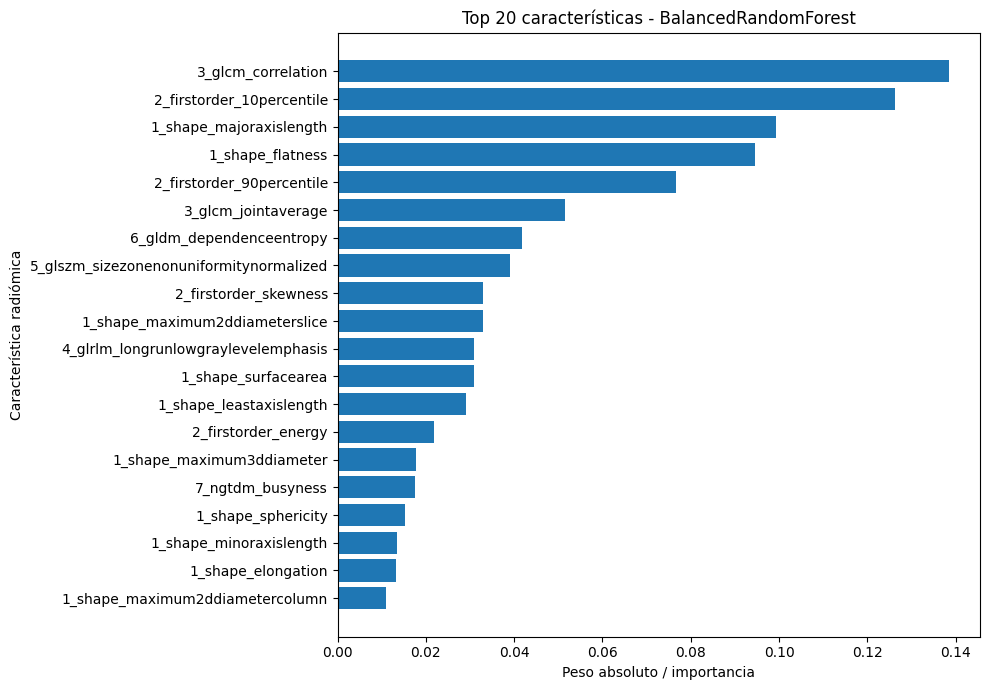

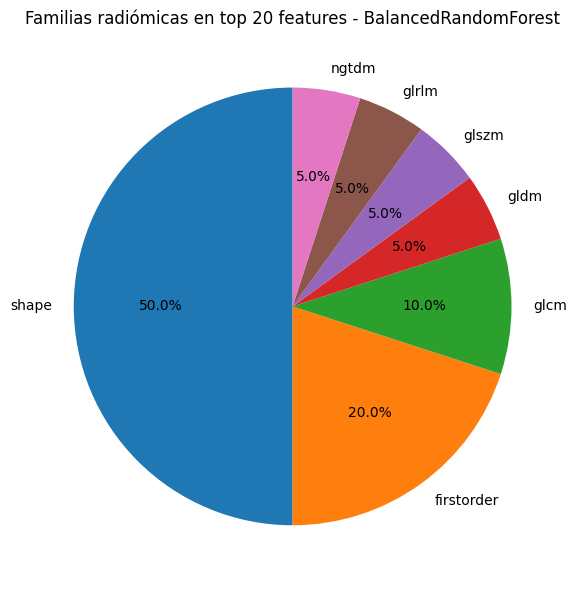

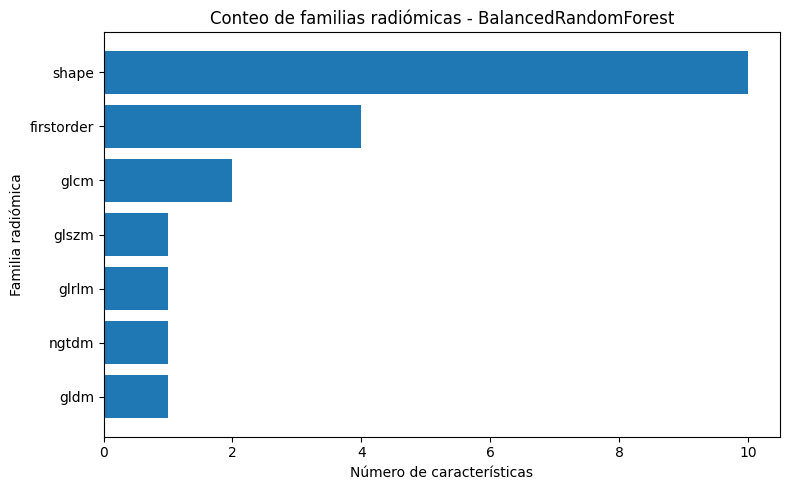


MODELO: ExtraTrees_balanced


,rank,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic,signo
0,1,ExtraTrees_balanced,2_firstorder_10percentile,0.095964,0.095964,feature_importance,firstorder,10percentile,positivo
1,2,ExtraTrees_balanced,2_firstorder_90percentile,0.078927,0.078927,feature_importance,firstorder,90percentile,positivo
2,3,ExtraTrees_balanced,2_firstorder_totalenergy,0.077939,0.077939,feature_importance,firstorder,totalenergy,positivo
3,4,ExtraTrees_balanced,3_glcm_correlation,0.077052,0.077052,feature_importance,glcm,correlation,positivo
4,5,ExtraTrees_balanced,1_shape_flatness,0.066300,0.066300,feature_importance,shape,flatness,positivo
5,6,ExtraTrees_balanced,1_shape_majoraxislength,0.065274,0.065274,feature_importance,shape,majoraxislength,positivo
6,7,ExtraTrees_balanced,6_gldm_dependenceentropy,0.058455,0.058455,feature_importance,gldm,dependenceentropy,positivo
7,8,ExtraTrees_balanced,4_glrlm_lowgraylevelrunemphasis,0.042710,0.042710,feature_importance,glrlm,lowgraylevelrunemphasis,positivo
8,9,ExtraTrees_balanced,5_glszm_sizezonenonuniformitynormalized,0.041841,0.041841,feature_importance,glszm,sizezonenonuniformitynormalized,positivo
9,10,ExtraTrees_balanced,4_glrlm_longrunlowgraylevelemphasis,0.036559,0.036559,feature_importance,glrlm,longrunlowgraylevelemphasis,positivo


,model,family,n_features,mean_importance,max_importance,top_features
5,ExtraTrees_balanced,shape,7,0.033581,0.066300,"1_shape_flatness, 1_shape_majoraxislength, 1_s..."
0,ExtraTrees_balanced,firstorder,5,0.057622,0.095964,"2_firstorder_10percentile, 2_firstorder_90perc..."
4,ExtraTrees_balanced,glszm,3,0.025601,0.041841,"5_glszm_sizezonenonuniformitynormalized, 5_gls..."
1,ExtraTrees_balanced,glcm,2,0.050307,0.077052,"3_glcm_correlation, 3_glcm_jointaverage"
3,ExtraTrees_balanced,glrlm,2,0.039635,0.042710,"4_glrlm_lowgraylevelrunemphasis, 4_glrlm_longr..."
2,ExtraTrees_balanced,gldm,1,0.058455,0.058455,6_gldm_dependenceentropy


Ecuación/regla LaTeX:
s_{\mathrm{ExtraTrees\_balanced}}(x)=f_{\mathrm{ExtraTrees\_balanced}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{ExtraTrees\_balanced}}(x) \geq 0.410


```latex
s_{\mathrm{ExtraTrees\_balanced}}(x)=f_{\mathrm{ExtraTrees\_balanced}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{ExtraTrees\_balanced}}(x) \geq 0.410
```

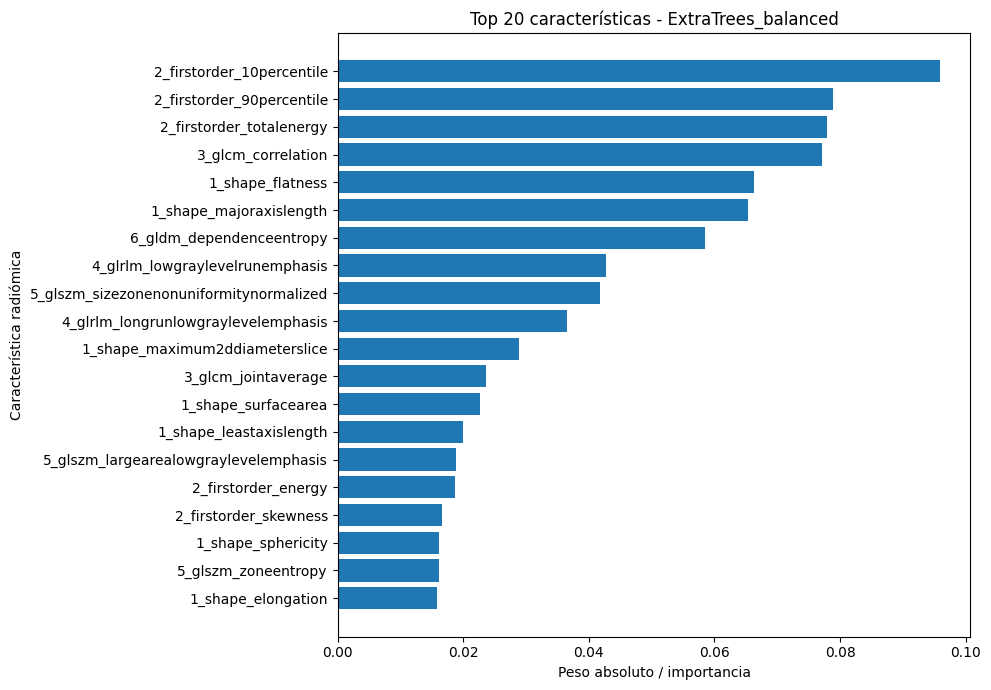

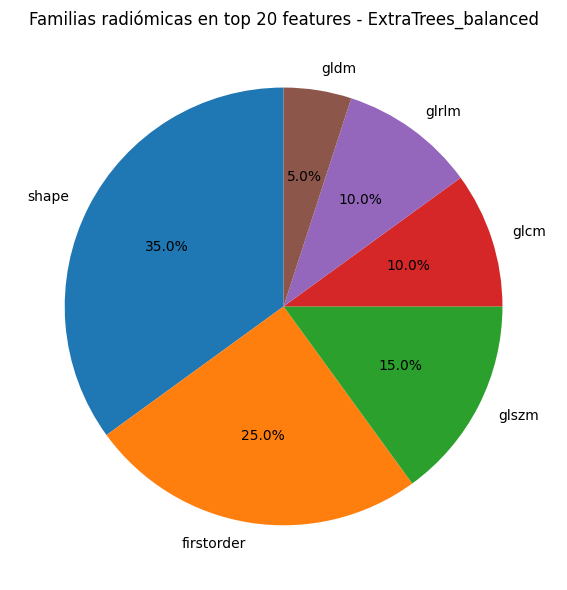

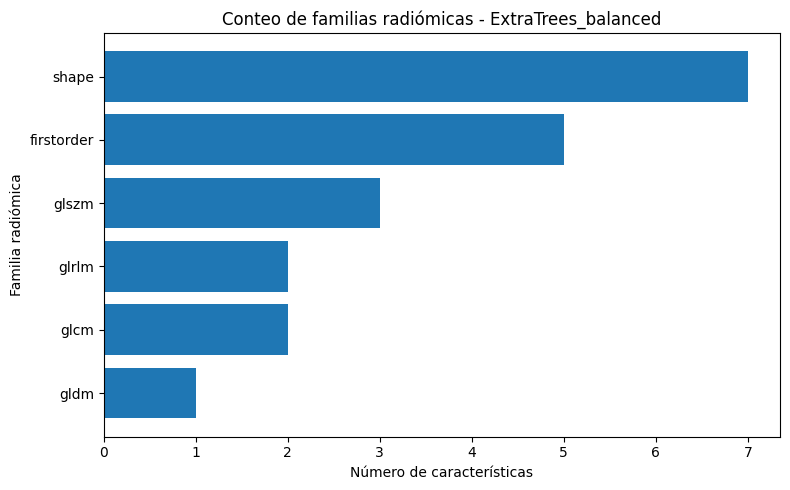


MODELO: LogReg_elasticnet_ROS


,rank,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic,signo
0,1,LogReg_elasticnet_ROS,6_gldm_dependenceentropy,3.575185,3.575185,coeficiente,gldm,dependenceentropy,positivo
1,2,LogReg_elasticnet_ROS,4_glrlm_lowgraylevelrunemphasis,2.407996,2.407996,coeficiente,glrlm,lowgraylevelrunemphasis,positivo
2,3,LogReg_elasticnet_ROS,5_glszm_lowgraylevelzoneemphasis,2.337395,-2.337395,coeficiente,glszm,lowgraylevelzoneemphasis,negativo
3,4,LogReg_elasticnet_ROS,1_shape_flatness,2.234392,2.234392,coeficiente,shape,flatness,positivo
4,5,LogReg_elasticnet_ROS,2_firstorder_mean,2.035669,-2.035669,coeficiente,firstorder,mean,negativo
5,6,LogReg_elasticnet_ROS,2_firstorder_90percentile,1.808021,-1.808021,coeficiente,firstorder,90percentile,negativo
6,7,LogReg_elasticnet_ROS,4_glrlm_longrunlowgraylevelemphasis,1.774400,1.774400,coeficiente,glrlm,longrunlowgraylevelemphasis,positivo
7,8,LogReg_elasticnet_ROS,3_glcm_imc1,1.582220,-1.582220,coeficiente,glcm,imc1,negativo
8,9,LogReg_elasticnet_ROS,1_shape_maximum2ddiameterslice,1.451571,-1.451571,coeficiente,shape,maximum2ddiameterslice,negativo
9,10,LogReg_elasticnet_ROS,4_glrlm_runentropy,1.344407,-1.344407,coeficiente,glrlm,runentropy,negativo


,model,family,n_features,mean_importance,max_importance,top_features
0,LogReg_elasticnet_ROS,firstorder,5,1.174459,2.035669,"2_firstorder_mean, 2_firstorder_90percentile, ..."
1,LogReg_elasticnet_ROS,glcm,4,0.839022,1.582220,"3_glcm_imc1, 3_glcm_differenceaverage, 3_glcm_..."
3,LogReg_elasticnet_ROS,glrlm,3,1.842267,2.407996,"4_glrlm_lowgraylevelrunemphasis, 4_glrlm_longr..."
4,LogReg_elasticnet_ROS,glszm,3,1.004685,2.337395,"5_glszm_lowgraylevelzoneemphasis, 5_glszm_zone..."
5,LogReg_elasticnet_ROS,shape,3,1.553648,2.234392,"1_shape_flatness, 1_shape_maximum2ddiametersli..."
2,LogReg_elasticnet_ROS,gldm,1,3.575185,3.575185,6_gldm_dependenceentropy


Ecuación/regla LaTeX:
\log\left(\frac{p}{1-p}\right) = 0.1534 + 3.5752\,z_{\mathrm{6\_gldm\_dependenceentropy}} + 2.4080\,z_{\mathrm{4\_glrlm\_lowgraylevelrunemphasis}} - 2.3374\,z_{\mathrm{5\_glszm\_lowgraylevelzoneemphasis}} + 2.2344\,z_{\mathrm{1\_shape\_flatness}} - 2.0357\,z_{\mathrm{2\_firstorder\_mean}} - 1.8080\,z_{\mathrm{2\_firstorder\_90percentile}} + 1.7744\,z_{\mathrm{4\_glrlm\_longrunlowgraylevelemphasis}} - 1.5822\,z_{\mathrm{3\_glcm\_imc1}}, \quad \hat{y}=1 \; \mathrm{si} \; p \geq 0.189


```latex
\log\left(\frac{p}{1-p}\right) = 0.1534 + 3.5752\,z_{\mathrm{6\_gldm\_dependenceentropy}} + 2.4080\,z_{\mathrm{4\_glrlm\_lowgraylevelrunemphasis}} - 2.3374\,z_{\mathrm{5\_glszm\_lowgraylevelzoneemphasis}} + 2.2344\,z_{\mathrm{1\_shape\_flatness}} - 2.0357\,z_{\mathrm{2\_firstorder\_mean}} - 1.8080\,z_{\mathrm{2\_firstorder\_90percentile}} + 1.7744\,z_{\mathrm{4\_glrlm\_longrunlowgraylevelemphasis}} - 1.5822\,z_{\mathrm{3\_glcm\_imc1}}, \quad \hat{y}=1 \; \mathrm{si} \; p \geq 0.189
```

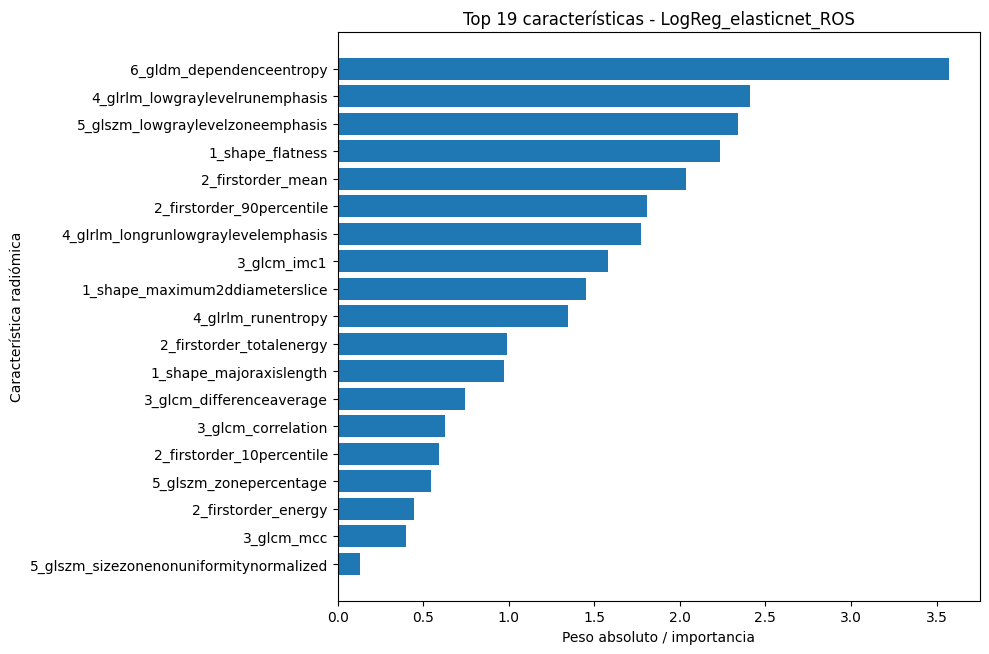

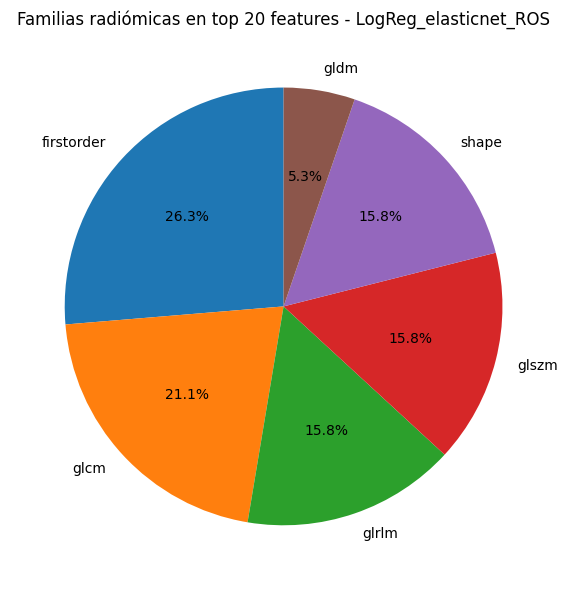

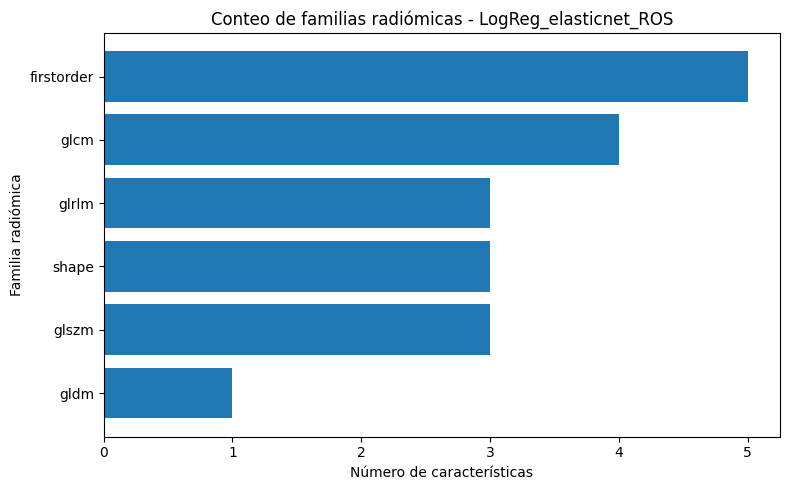


MODELO: LogReg_elasticnet_SMOTE


,rank,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic,signo
0,1,LogReg_elasticnet_SMOTE,1_shape_flatness,1.589268,1.589268,coeficiente,shape,flatness,positivo
1,2,LogReg_elasticnet_SMOTE,6_gldm_dependenceentropy,1.467230,1.467230,coeficiente,gldm,dependenceentropy,positivo
2,3,LogReg_elasticnet_SMOTE,2_firstorder_10percentile,1.316076,-1.316076,coeficiente,firstorder,10percentile,negativo
3,4,LogReg_elasticnet_SMOTE,1_shape_maximum2ddiameterslice,0.848051,-0.848051,coeficiente,shape,maximum2ddiameterslice,negativo
4,5,LogReg_elasticnet_SMOTE,2_firstorder_90percentile,0.839628,-0.839628,coeficiente,firstorder,90percentile,negativo
5,6,LogReg_elasticnet_SMOTE,4_glrlm_longrunlowgraylevelemphasis,0.616654,0.616654,coeficiente,glrlm,longrunlowgraylevelemphasis,positivo
6,7,LogReg_elasticnet_SMOTE,4_glrlm_lowgraylevelrunemphasis,0.559639,0.559639,coeficiente,glrlm,lowgraylevelrunemphasis,positivo
7,8,LogReg_elasticnet_SMOTE,2_firstorder_energy,0.476289,0.476289,coeficiente,firstorder,energy,positivo
8,9,LogReg_elasticnet_SMOTE,1_shape_majoraxislength,0.438028,0.438028,coeficiente,shape,majoraxislength,positivo
9,10,LogReg_elasticnet_SMOTE,5_glszm_zonepercentage,0.033110,-0.033110,coeficiente,glszm,zonepercentage,negativo


,model,family,n_features,mean_importance,max_importance,top_features
0,LogReg_elasticnet_SMOTE,firstorder,4,0.657998,1.316076,"2_firstorder_10percentile, 2_firstorder_90perc..."
5,LogReg_elasticnet_SMOTE,shape,3,0.958449,1.589268,"1_shape_flatness, 1_shape_maximum2ddiametersli..."
3,LogReg_elasticnet_SMOTE,glrlm,2,0.588147,0.616654,"4_glrlm_longrunlowgraylevelemphasis, 4_glrlm_l..."
4,LogReg_elasticnet_SMOTE,glszm,2,0.019348,0.033110,"5_glszm_zonepercentage, 5_glszm_sizezonenonuni..."
1,LogReg_elasticnet_SMOTE,glcm,2,0.000000,0.000000,"3_glcm_differenceaverage, 3_glcm_correlation"
2,LogReg_elasticnet_SMOTE,gldm,1,1.467230,1.467230,6_gldm_dependenceentropy


Ecuación/regla LaTeX:
\log\left(\frac{p}{1-p}\right) = 0.2588 + 1.5893\,z_{\mathrm{1\_shape\_flatness}} + 1.4672\,z_{\mathrm{6\_gldm\_dependenceentropy}} - 1.3161\,z_{\mathrm{2\_firstorder\_10percentile}} - 0.8481\,z_{\mathrm{1\_shape\_maximum2ddiameterslice}} - 0.8396\,z_{\mathrm{2\_firstorder\_90percentile}} + 0.6167\,z_{\mathrm{4\_glrlm\_longrunlowgraylevelemphasis}} + 0.5596\,z_{\mathrm{4\_glrlm\_lowgraylevelrunemphasis}} + 0.4763\,z_{\mathrm{2\_firstorder\_energy}}, \quad \hat{y}=1 \; \mathrm{si} \; p \geq 0.189


```latex
\log\left(\frac{p}{1-p}\right) = 0.2588 + 1.5893\,z_{\mathrm{1\_shape\_flatness}} + 1.4672\,z_{\mathrm{6\_gldm\_dependenceentropy}} - 1.3161\,z_{\mathrm{2\_firstorder\_10percentile}} - 0.8481\,z_{\mathrm{1\_shape\_maximum2ddiameterslice}} - 0.8396\,z_{\mathrm{2\_firstorder\_90percentile}} + 0.6167\,z_{\mathrm{4\_glrlm\_longrunlowgraylevelemphasis}} + 0.5596\,z_{\mathrm{4\_glrlm\_lowgraylevelrunemphasis}} + 0.4763\,z_{\mathrm{2\_firstorder\_energy}}, \quad \hat{y}=1 \; \mathrm{si} \; p \geq 0.189
```

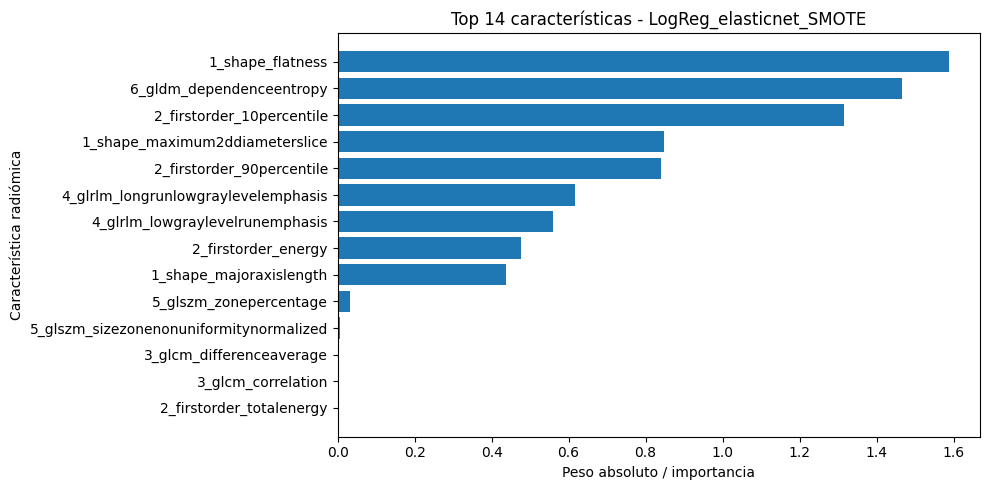

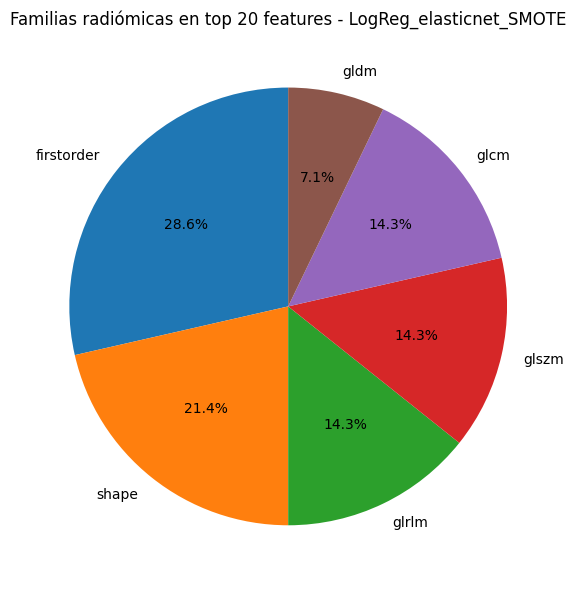

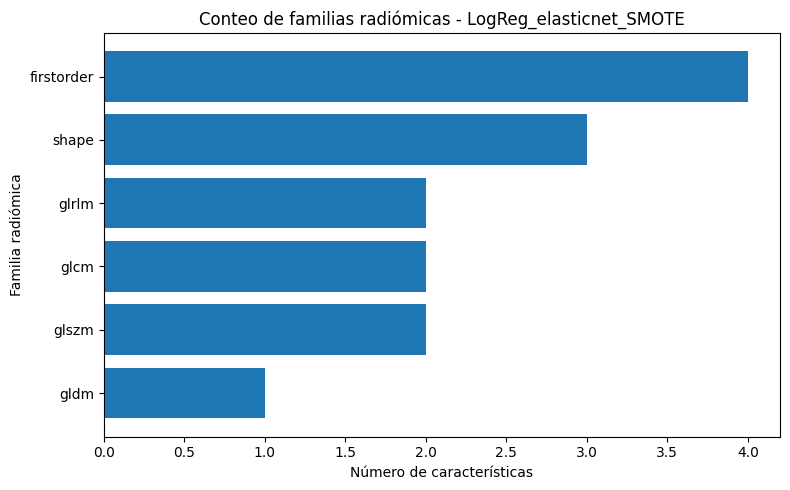


MODELO: LogReg_elasticnet_balanced


,rank,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic,signo
0,1,LogReg_elasticnet_balanced,2_firstorder_10percentile,0.581794,-0.581794,coeficiente,firstorder,10percentile,negativo
1,2,LogReg_elasticnet_balanced,1_shape_flatness,0.539008,0.539008,coeficiente,shape,flatness,positivo
2,3,LogReg_elasticnet_balanced,6_gldm_dependenceentropy,0.437527,0.437527,coeficiente,gldm,dependenceentropy,positivo
3,4,LogReg_elasticnet_balanced,3_glcm_correlation,0.418876,0.418876,coeficiente,glcm,correlation,positivo
4,5,LogReg_elasticnet_balanced,2_firstorder_skewness,0.351523,0.351523,coeficiente,firstorder,skewness,positivo
5,6,LogReg_elasticnet_balanced,2_firstorder_90percentile,0.312771,-0.312771,coeficiente,firstorder,90percentile,negativo
6,7,LogReg_elasticnet_balanced,1_shape_maximum2ddiameterslice,0.263576,-0.263576,coeficiente,shape,maximum2ddiameterslice,negativo
7,8,LogReg_elasticnet_balanced,4_glrlm_lowgraylevelrunemphasis,0.218988,0.218988,coeficiente,glrlm,lowgraylevelrunemphasis,positivo
8,9,LogReg_elasticnet_balanced,5_glszm_largearealowgraylevelemphasis,0.204165,0.204165,coeficiente,glszm,largearealowgraylevelemphasis,positivo
9,10,LogReg_elasticnet_balanced,2_firstorder_totalenergy,0.191233,-0.191233,coeficiente,firstorder,totalenergy,negativo


,model,family,n_features,mean_importance,max_importance,top_features
0,LogReg_elasticnet_balanced,firstorder,5,0.300666,0.581794,"2_firstorder_10percentile, 2_firstorder_skewne..."
5,LogReg_elasticnet_balanced,shape,5,0.203173,0.539008,"1_shape_flatness, 1_shape_maximum2ddiametersli..."
4,LogReg_elasticnet_balanced,glszm,4,0.136625,0.204165,"5_glszm_largearealowgraylevelemphasis, 5_glszm..."
1,LogReg_elasticnet_balanced,glcm,3,0.154989,0.418876,"3_glcm_correlation, 3_glcm_idmn, 3_glcm_contrast"
3,LogReg_elasticnet_balanced,glrlm,2,0.167392,0.218988,"4_glrlm_lowgraylevelrunemphasis, 4_glrlm_longr..."
2,LogReg_elasticnet_balanced,gldm,1,0.437527,0.437527,6_gldm_dependenceentropy


Ecuación/regla LaTeX:
\log\left(\frac{p}{1-p}\right) = 0.3585 - 0.5818\,z_{\mathrm{2\_firstorder\_10percentile}} + 0.5390\,z_{\mathrm{1\_shape\_flatness}} + 0.4375\,z_{\mathrm{6\_gldm\_dependenceentropy}} + 0.4189\,z_{\mathrm{3\_glcm\_correlation}} + 0.3515\,z_{\mathrm{2\_firstorder\_skewness}} - 0.3128\,z_{\mathrm{2\_firstorder\_90percentile}} - 0.2636\,z_{\mathrm{1\_shape\_maximum2ddiameterslice}} + 0.2190\,z_{\mathrm{4\_glrlm\_lowgraylevelrunemphasis}}, \quad \hat{y}=1 \; \mathrm{si} \; p \geq 0.264


```latex
\log\left(\frac{p}{1-p}\right) = 0.3585 - 0.5818\,z_{\mathrm{2\_firstorder\_10percentile}} + 0.5390\,z_{\mathrm{1\_shape\_flatness}} + 0.4375\,z_{\mathrm{6\_gldm\_dependenceentropy}} + 0.4189\,z_{\mathrm{3\_glcm\_correlation}} + 0.3515\,z_{\mathrm{2\_firstorder\_skewness}} - 0.3128\,z_{\mathrm{2\_firstorder\_90percentile}} - 0.2636\,z_{\mathrm{1\_shape\_maximum2ddiameterslice}} + 0.2190\,z_{\mathrm{4\_glrlm\_lowgraylevelrunemphasis}}, \quad \hat{y}=1 \; \mathrm{si} \; p \geq 0.264
```

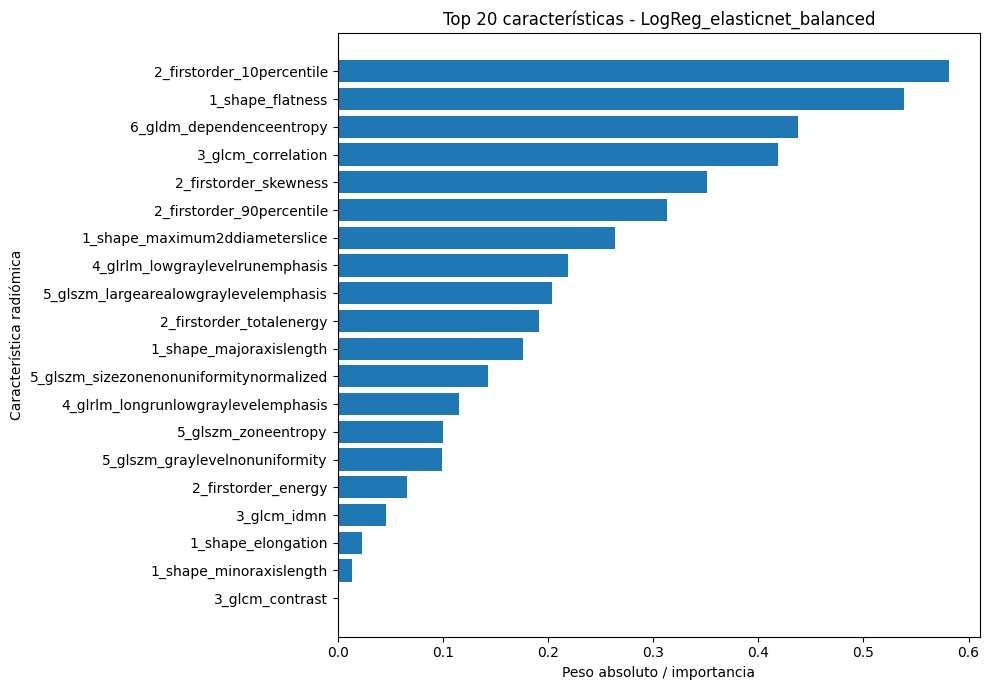

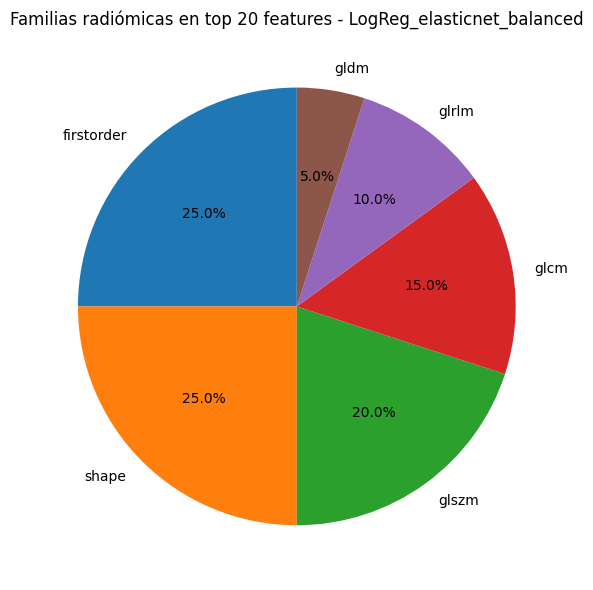

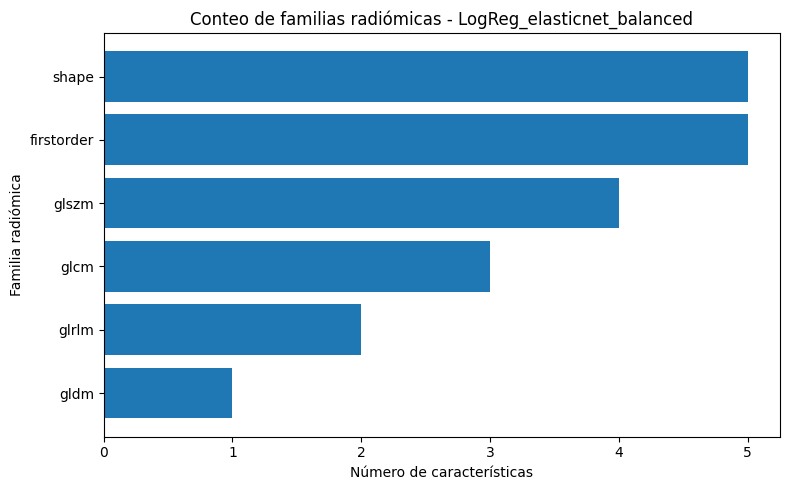


MODELO: RandomForest_balanced


,rank,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic,signo
0,1,RandomForest_balanced,3_glcm_correlation,0.113506,0.113506,feature_importance,glcm,correlation,positivo
1,2,RandomForest_balanced,2_firstorder_10percentile,0.106447,0.106447,feature_importance,firstorder,10percentile,positivo
2,3,RandomForest_balanced,1_shape_majoraxislength,0.082414,0.082414,feature_importance,shape,majoraxislength,positivo
3,4,RandomForest_balanced,2_firstorder_totalenergy,0.075771,0.075771,feature_importance,firstorder,totalenergy,positivo
4,5,RandomForest_balanced,1_shape_flatness,0.068119,0.068119,feature_importance,shape,flatness,positivo
5,6,RandomForest_balanced,2_firstorder_90percentile,0.062949,0.062949,feature_importance,firstorder,90percentile,positivo
6,7,RandomForest_balanced,3_glcm_jointaverage,0.047643,0.047643,feature_importance,glcm,jointaverage,positivo
7,8,RandomForest_balanced,6_gldm_dependenceentropy,0.033465,0.033465,feature_importance,gldm,dependenceentropy,positivo
8,9,RandomForest_balanced,1_shape_leastaxislength,0.030847,0.030847,feature_importance,shape,leastaxislength,positivo
9,10,RandomForest_balanced,4_glrlm_lowgraylevelrunemphasis,0.029985,0.029985,feature_importance,glrlm,lowgraylevelrunemphasis,positivo


,model,family,n_features,mean_importance,max_importance,top_features
6,RandomForest_balanced,shape,7,0.036608,0.082414,"1_shape_majoraxislength, 1_shape_flatness, 1_s..."
0,RandomForest_balanced,firstorder,4,0.066688,0.106447,"2_firstorder_10percentile, 2_firstorder_totale..."
1,RandomForest_balanced,glcm,3,0.059954,0.113506,"3_glcm_correlation, 3_glcm_jointaverage, 3_glc..."
3,RandomForest_balanced,glrlm,2,0.028959,0.029985,"4_glrlm_lowgraylevelrunemphasis, 4_glrlm_longr..."
4,RandomForest_balanced,glszm,2,0.027654,0.028081,"5_glszm_largearealowgraylevelemphasis, 5_glszm..."
2,RandomForest_balanced,gldm,1,0.033465,0.033465,6_gldm_dependenceentropy
5,RandomForest_balanced,ngtdm,1,0.012958,0.012958,7_ngtdm_busyness


Ecuación/regla LaTeX:
s_{\mathrm{RandomForest\_balanced}}(x)=f_{\mathrm{RandomForest\_balanced}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{RandomForest\_balanced}}(x) \geq 0.389


```latex
s_{\mathrm{RandomForest\_balanced}}(x)=f_{\mathrm{RandomForest\_balanced}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{RandomForest\_balanced}}(x) \geq 0.389
```

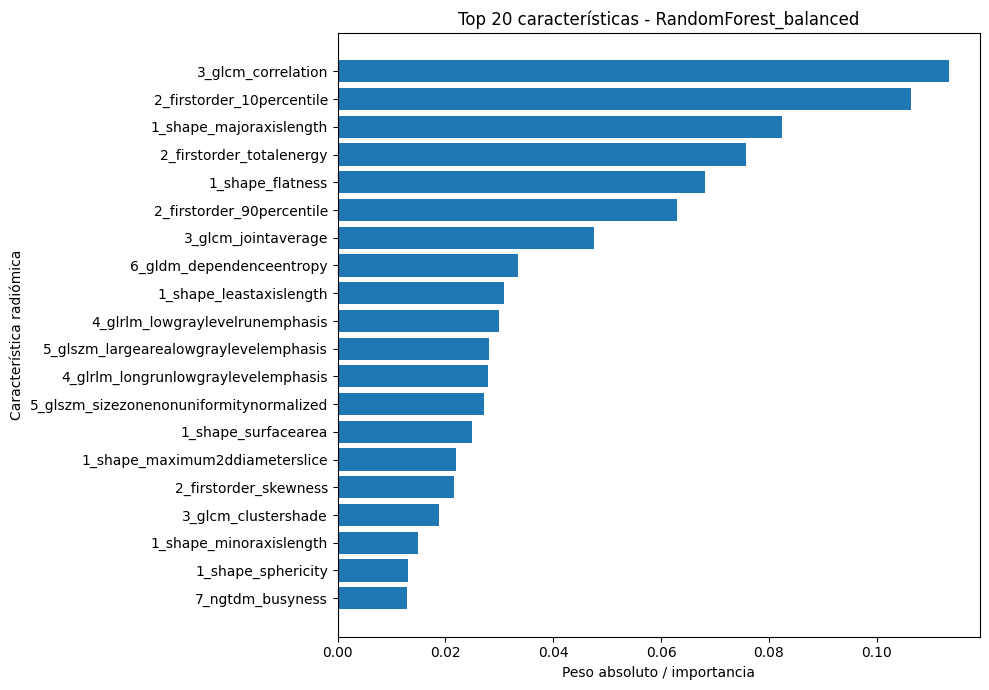

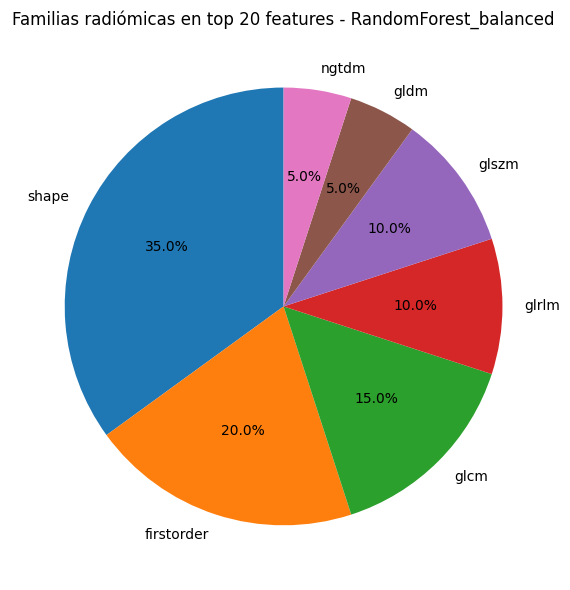

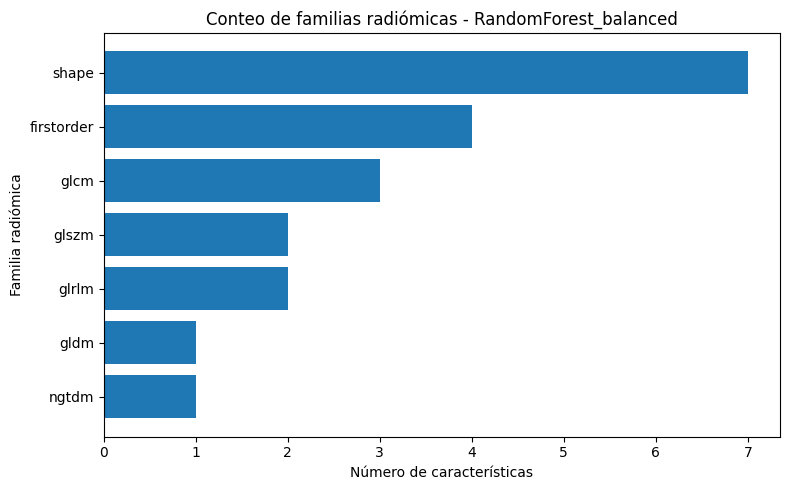


MODELO: SVM_RBF_balanced
Ecuación/regla LaTeX:
s_{\mathrm{SVM\_RBF\_balanced}}(x)=f_{\mathrm{SVM\_RBF\_balanced}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{SVM\_RBF\_balanced}}(x) \geq 0.352


```latex
s_{\mathrm{SVM\_RBF\_balanced}}(x)=f_{\mathrm{SVM\_RBF\_balanced}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{SVM\_RBF\_balanced}}(x) \geq 0.352
```


MODELO: SVM_linear_balanced


,rank,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic,signo
0,1,SVM_linear_balanced,2_firstorder_10percentile,0.216287,-0.216287,coeficiente,firstorder,10percentile,negativo
1,2,SVM_linear_balanced,1_shape_flatness,0.198955,0.198955,coeficiente,shape,flatness,positivo
2,3,SVM_linear_balanced,2_firstorder_mean,0.177609,-0.177609,coeficiente,firstorder,mean,negativo
3,4,SVM_linear_balanced,4_glrlm_lowgraylevelrunemphasis,0.134480,0.134480,coeficiente,glrlm,lowgraylevelrunemphasis,positivo
4,5,SVM_linear_balanced,6_gldm_dependenceentropy,0.132511,0.132511,coeficiente,gldm,dependenceentropy,positivo
5,6,SVM_linear_balanced,1_shape_majoraxislength,0.131885,-0.131885,coeficiente,shape,majoraxislength,negativo
6,7,SVM_linear_balanced,2_firstorder_90percentile,0.127368,-0.127368,coeficiente,firstorder,90percentile,negativo
7,8,SVM_linear_balanced,3_glcm_correlation,0.125830,0.125830,coeficiente,glcm,correlation,positivo
8,9,SVM_linear_balanced,3_glcm_mcc,0.120306,0.120306,coeficiente,glcm,mcc,positivo
9,10,SVM_linear_balanced,3_glcm_imc1,0.116436,-0.116436,coeficiente,glcm,imc1,negativo


,model,family,n_features,mean_importance,max_importance,top_features
0,SVM_linear_balanced,firstorder,5,0.132441,0.216287,"2_firstorder_10percentile, 2_firstorder_mean, ..."
1,SVM_linear_balanced,glcm,4,0.092674,0.125830,"3_glcm_correlation, 3_glcm_mcc, 3_glcm_imc1, 3..."
5,SVM_linear_balanced,shape,3,0.139577,0.198955,"1_shape_flatness, 1_shape_majoraxislength, 1_s..."
3,SVM_linear_balanced,glrlm,3,0.097452,0.134480,"4_glrlm_lowgraylevelrunemphasis, 4_glrlm_longr..."
4,SVM_linear_balanced,glszm,3,0.054223,0.084965,"5_glszm_zonepercentage, 5_glszm_sizezonenonuni..."
2,SVM_linear_balanced,gldm,1,0.132511,0.132511,6_gldm_dependenceentropy


Ecuación/regla LaTeX:
\log\left(\frac{p}{1-p}\right) = 0.2083 - 0.2163\,z_{\mathrm{2\_firstorder\_10percentile}} + 0.1990\,z_{\mathrm{1\_shape\_flatness}} - 0.1776\,z_{\mathrm{2\_firstorder\_mean}} + 0.1345\,z_{\mathrm{4\_glrlm\_lowgraylevelrunemphasis}} + 0.1325\,z_{\mathrm{6\_gldm\_dependenceentropy}} - 0.1319\,z_{\mathrm{1\_shape\_majoraxislength}} - 0.1274\,z_{\mathrm{2\_firstorder\_90percentile}} + 0.1258\,z_{\mathrm{3\_glcm\_correlation}}, \quad \hat{y}=1 \; \mathrm{si} \; p \geq 0.302


```latex
\log\left(\frac{p}{1-p}\right) = 0.2083 - 0.2163\,z_{\mathrm{2\_firstorder\_10percentile}} + 0.1990\,z_{\mathrm{1\_shape\_flatness}} - 0.1776\,z_{\mathrm{2\_firstorder\_mean}} + 0.1345\,z_{\mathrm{4\_glrlm\_lowgraylevelrunemphasis}} + 0.1325\,z_{\mathrm{6\_gldm\_dependenceentropy}} - 0.1319\,z_{\mathrm{1\_shape\_majoraxislength}} - 0.1274\,z_{\mathrm{2\_firstorder\_90percentile}} + 0.1258\,z_{\mathrm{3\_glcm\_correlation}}, \quad \hat{y}=1 \; \mathrm{si} \; p \geq 0.302
```

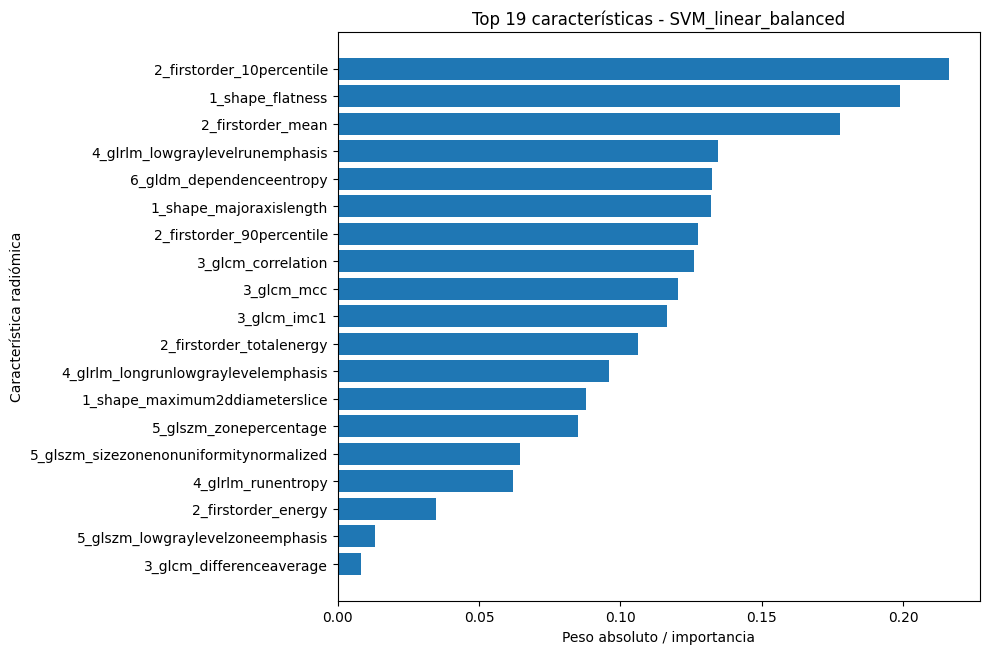

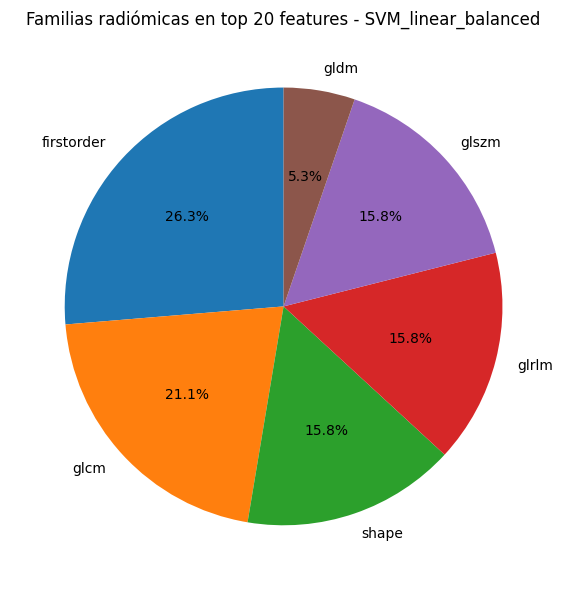

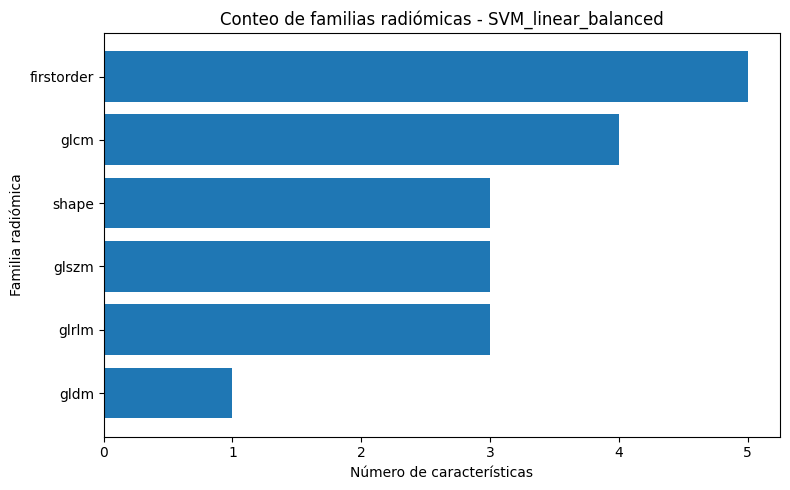


MODELO: XGBoost_pos_weight


,rank,model,feature,importance_abs,direction_or_raw_value,importance_source,family,radiomic_characteristic,signo
0,1,XGBoost_pos_weight,2_firstorder_totalenergy,0.120831,0.120831,feature_importance,firstorder,totalenergy,positivo
1,2,XGBoost_pos_weight,2_firstorder_10percentile,0.092004,0.092004,feature_importance,firstorder,10percentile,positivo
2,3,XGBoost_pos_weight,2_firstorder_90percentile,0.088223,0.088223,feature_importance,firstorder,90percentile,positivo
3,4,XGBoost_pos_weight,3_glcm_correlation,0.087056,0.087056,feature_importance,glcm,correlation,positivo
4,5,XGBoost_pos_weight,5_glszm_largearealowgraylevelemphasis,0.045605,0.045605,feature_importance,glszm,largearealowgraylevelemphasis,positivo
5,6,XGBoost_pos_weight,1_shape_flatness,0.045027,0.045027,feature_importance,shape,flatness,positivo
6,7,XGBoost_pos_weight,3_glcm_clustershade,0.044210,0.044210,feature_importance,glcm,clustershade,positivo
7,8,XGBoost_pos_weight,1_shape_majoraxislength,0.041679,0.041679,feature_importance,shape,majoraxislength,positivo
8,9,XGBoost_pos_weight,1_shape_maximum3ddiameter,0.030877,0.030877,feature_importance,shape,maximum3ddiameter,positivo
9,10,XGBoost_pos_weight,2_firstorder_skewness,0.029221,0.029221,feature_importance,firstorder,skewness,positivo


,model,family,n_features,mean_importance,max_importance,top_features
6,XGBoost_pos_weight,shape,8,0.029674,0.045027,"1_shape_flatness, 1_shape_majoraxislength, 1_s..."
0,XGBoost_pos_weight,firstorder,4,0.082570,0.120831,"2_firstorder_totalenergy, 2_firstorder_10perce..."
1,XGBoost_pos_weight,glcm,3,0.052800,0.087056,"3_glcm_correlation, 3_glcm_clustershade, 3_glc..."
3,XGBoost_pos_weight,glrlm,2,0.020046,0.020957,"4_glrlm_longrunlowgraylevelemphasis, 4_glrlm_l..."
4,XGBoost_pos_weight,glszm,1,0.045605,0.045605,5_glszm_largearealowgraylevelemphasis
2,XGBoost_pos_weight,gldm,1,0.024568,0.024568,6_gldm_dependenceentropy
5,XGBoost_pos_weight,ngtdm,1,0.019170,0.019170,7_ngtdm_busyness


Ecuación/regla LaTeX:
s_{\mathrm{XGBoost\_pos\_weight}}(x)=f_{\mathrm{XGBoost\_pos\_weight}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{XGBoost\_pos\_weight}}(x) \geq 0.314


```latex
s_{\mathrm{XGBoost\_pos\_weight}}(x)=f_{\mathrm{XGBoost\_pos\_weight}}(x), \quad \hat{y}=1 \; \mathrm{si} \; s_{\mathrm{XGBoost\_pos\_weight}}(x) \geq 0.314
```

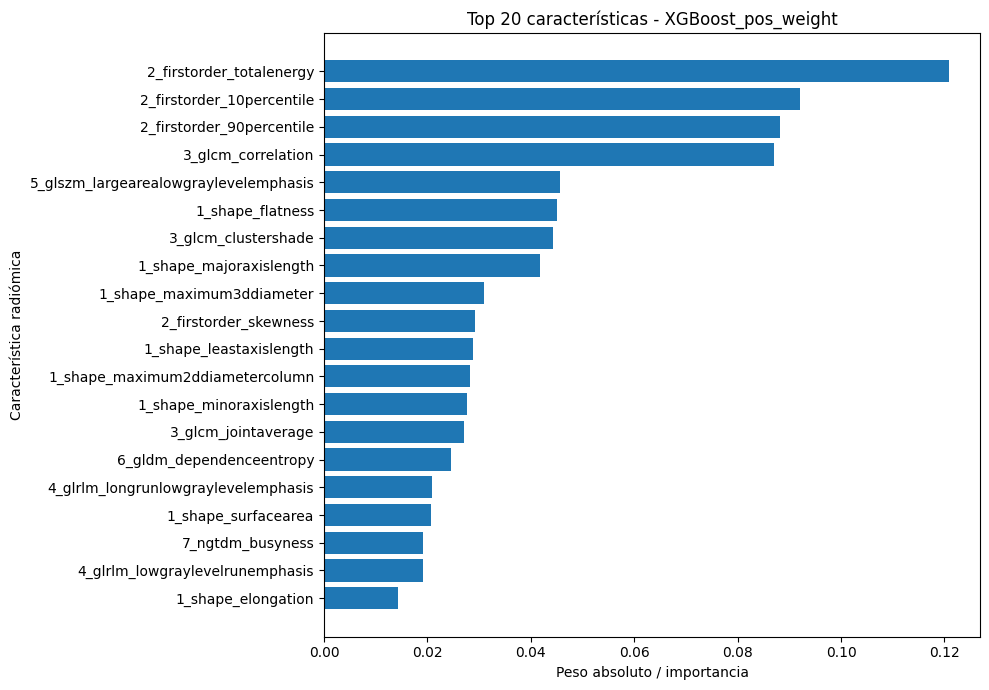

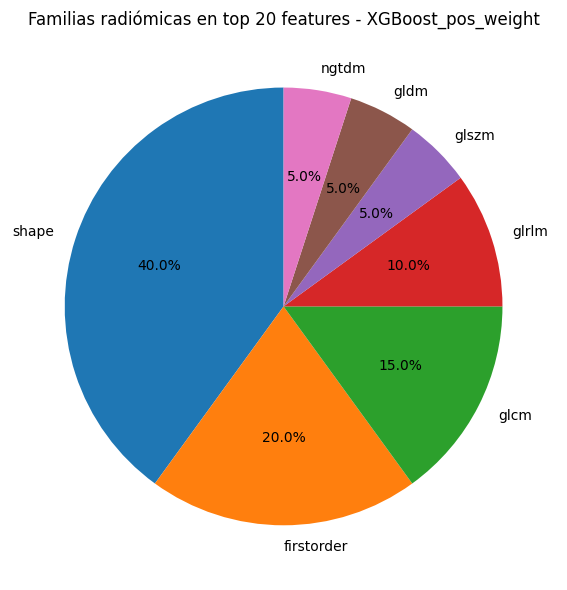

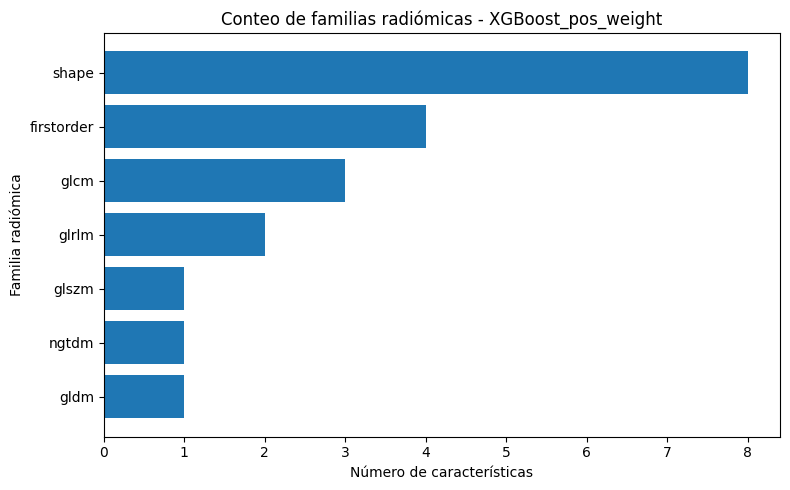

Matriz modelo x familia:


family,model,firstorder,glcm,gldm,glrlm,glszm,ngtdm,shape
0,BalancedRandomForest,4,2,1,1,1,1,10
1,ExtraTrees_balanced,5,2,1,2,3,0,7
2,LogReg_elasticnet_ROS,5,4,1,3,3,0,3
3,LogReg_elasticnet_SMOTE,4,2,1,2,2,0,3
4,LogReg_elasticnet_balanced,5,3,1,2,4,0,5
5,RandomForest_balanced,4,3,1,2,2,1,7
6,SVM_linear_balanced,5,4,1,3,3,0,3
7,XGBoost_pos_weight,4,3,1,2,1,1,8


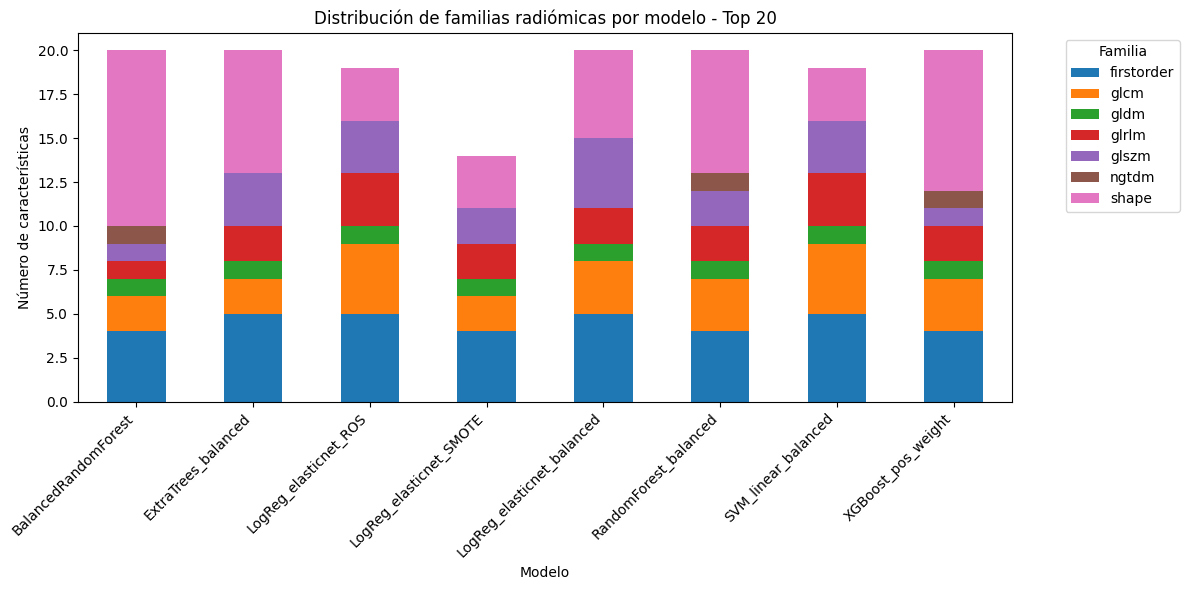

In [ ]:
# ============================================================
# 19.3) TABLAS Y GRÁFICOS POR MODELO
# ============================================================

if "final_model_objects" in globals() and isinstance(final_model_objects, dict) and len(final_model_objects) > 0:
    model_names_visual = list(final_model_objects.keys())
elif "features_by_model_table" in globals() and features_by_model_table is not None and len(features_by_model_table) > 0:
    model_names_visual = sorted(features_by_model_table["model"].unique())
else:
    raise ValueError("No encuentro modelos ni features. Ejecuta entrenamiento o recarga checkpoints primero.")

latex_equations_table = make_latex_equations_table(model_names_visual)

all_top_features = []
all_family_counts = []
figure_rows = []

for model_name in model_names_visual:
    print("\n" + "=" * 80)
    print("MODELO:", model_name)
    print("=" * 80)

    tf = get_top_features_for_model(model_name, top_n=TOP_N_VIS)
    if len(tf) > 0:
        display(tf)
        all_top_features.append(tf)

    fam = family_counts_for_model(model_name, top_n=TOP_N_VIS)
    if len(fam) > 0:
        display(fam)
        all_family_counts.append(fam)

    eq_row = latex_equations_table[latex_equations_table["model"] == model_name]
    if len(eq_row) > 0:
        print("Ecuación/regla LaTeX:")
        print(eq_row["latex_equation"].iloc[0])
        display(Markdown("```latex\n" + eq_row["latex_equation"].iloc[0] + "\n```"))

    # Barras de features
    if len(tf) > 0:
        plot_df = tf.sort_values("importance_abs", ascending=True)
        plt.figure(figsize=(10, max(5, 0.35 * len(plot_df))))
        plt.barh(plot_df["feature"], plot_df["importance_abs"])
        plt.xlabel("Peso absoluto / importancia")
        plt.ylabel("Característica radiómica")
        plt.title(f"Top {len(plot_df)} características - {model_name}")
        plt.tight_layout()
        p1 = VIS_DIR_ENTREGA / f"{clean_filename(model_name)}_top_features_barras.png"
        plt.savefig(p1, dpi=300, bbox_inches="tight")
        plt.show()
    else:
        p1 = None

    # Pie y barras de familias
    if len(fam) > 0:
        plt.figure(figsize=(6, 6))
        plt.pie(fam["n_features"], labels=fam["family"], autopct="%1.1f%%", startangle=90)
        plt.title(f"Familias radiómicas en top {TOP_N_VIS} features - {model_name}")
        plt.tight_layout()
        p2 = VIS_DIR_ENTREGA / f"{clean_filename(model_name)}_familias_pie.png"
        plt.savefig(p2, dpi=300, bbox_inches="tight")
        plt.show()

        plot_fam = fam.sort_values("n_features", ascending=True)
        plt.figure(figsize=(8, 5))
        plt.barh(plot_fam["family"], plot_fam["n_features"])
        plt.xlabel("Número de características")
        plt.ylabel("Familia radiómica")
        plt.title(f"Conteo de familias radiómicas - {model_name}")
        plt.tight_layout()
        p3 = VIS_DIR_ENTREGA / f"{clean_filename(model_name)}_familias_barras.png"
        plt.savefig(p3, dpi=300, bbox_inches="tight")
        plt.show()
    else:
        p2 = None
        p3 = None

    figure_rows.append({
        "model": model_name,
        "top_features_bar": str(p1) if p1 else None,
        "family_pie": str(p2) if p2 else None,
        "family_bar": str(p3) if p3 else None
    })

top_features_per_model_table = pd.concat(all_top_features, ignore_index=True) if len(all_top_features) > 0 else pd.DataFrame()
family_counts_per_model_table = pd.concat(all_family_counts, ignore_index=True) if len(all_family_counts) > 0 else pd.DataFrame()
figures_index_table = pd.DataFrame(figure_rows)

if len(family_counts_per_model_table) > 0:
    model_family_count_matrix = (
        family_counts_per_model_table
        .pivot_table(index="model", columns="family", values="n_features", aggfunc="sum", fill_value=0)
        .reset_index()
    )
else:
    model_family_count_matrix = pd.DataFrame()

print("Matriz modelo x familia:")
display(model_family_count_matrix)

# Gráfico global modelo x familia
if len(model_family_count_matrix) > 0:
    stack_df = model_family_count_matrix.set_index("model")
    ax = stack_df.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_xlabel("Modelo")
    ax.set_ylabel("Número de características")
    ax.set_title(f"Distribución de familias radiómicas por modelo - Top {TOP_N_VIS}")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Familia", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    p_global_fam = VIS_DIR_ENTREGA / "global_modelo_por_familia_barras_apiladas.png"
    plt.savefig(p_global_fam, dpi=300, bbox_inches="tight")
    plt.show()

# Guardar tablas
for name, table in {
    "top_features_per_model": top_features_per_model_table,
    "family_counts_per_model": family_counts_per_model_table,
    "model_family_count_matrix": model_family_count_matrix,
    "latex_equations": latex_equations_table,
    "figures_index": figures_index_table,
}.items():
    if table is not None and len(table) > 0:
        table.to_csv(VIS_DIR_ENTREGA / f"{name}.csv", index=False)

,model,ROC-AUC,PR-AUC,Accuracy,Balanced Accuracy,Precisión / PPV,Sensibilidad,Especificidad,F1,F2,MCC,Brier
6,SVM_RBF_balanced,0.941533,0.964700,0.832759,0.807605,0.829690,0.942484,0.672727,0.875777,0.912643,0.662487,0.097702
0,BalancedRandomForest,0.931655,0.958384,0.825862,0.794979,0.801016,0.953595,0.636364,0.868238,0.916809,0.646792,0.112518
2,LogReg_elasticnet_ROS,0.917380,0.951151,0.819704,0.790612,0.800844,0.941830,0.639394,0.862882,0.907732,0.633299,0.112112
7,SVM_linear_balanced,0.911765,0.949748,0.798030,0.766117,0.797044,0.930719,0.601515,0.849472,0.893976,0.596111,0.120680
1,ExtraTrees_balanced,0.924540,0.949368,0.833005,0.812181,0.829107,0.918301,0.706061,0.867946,0.896578,0.658995,0.136747
4,LogReg_elasticnet_balanced,0.917914,0.945928,0.839901,0.814854,0.824167,0.941830,0.687879,0.876555,0.913916,0.671455,0.122131
3,LogReg_elasticnet_SMOTE,0.899851,0.944306,0.777586,0.744326,0.769621,0.918954,0.569697,0.833614,0.881465,0.542272,0.118401
5,RandomForest_balanced,0.911289,0.936711,0.853695,0.834730,0.848415,0.930065,0.739394,0.885332,0.911070,0.695778,0.116307
8,XGBoost_pos_weight,0.910547,0.935865,0.853448,0.831848,0.837310,0.942484,0.721212,0.886178,0.918953,0.693497,0.120458


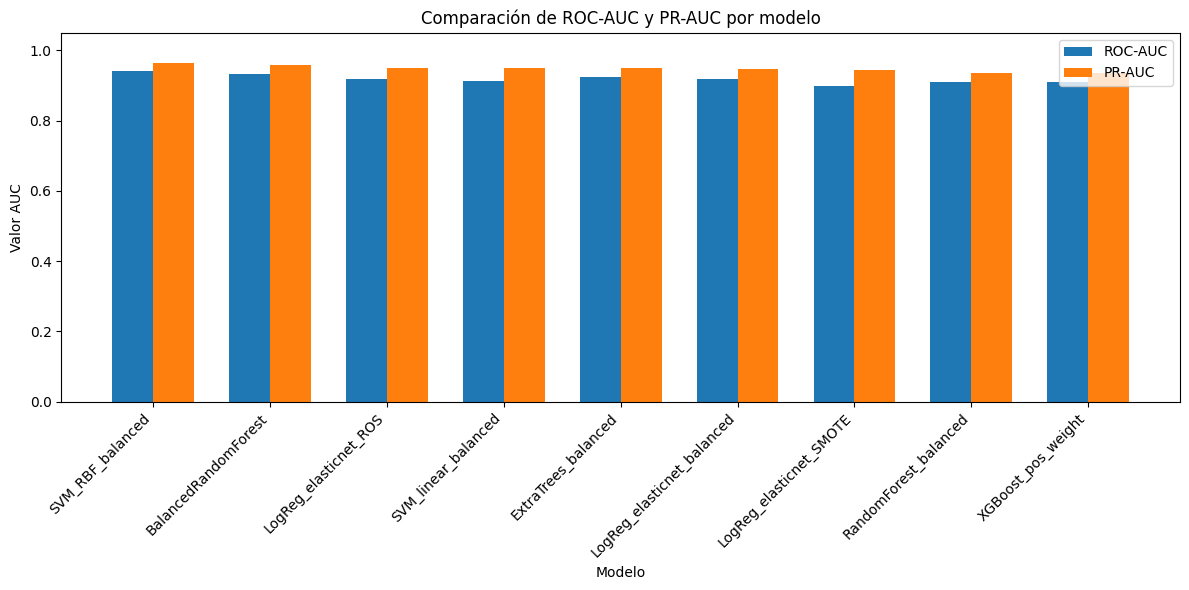

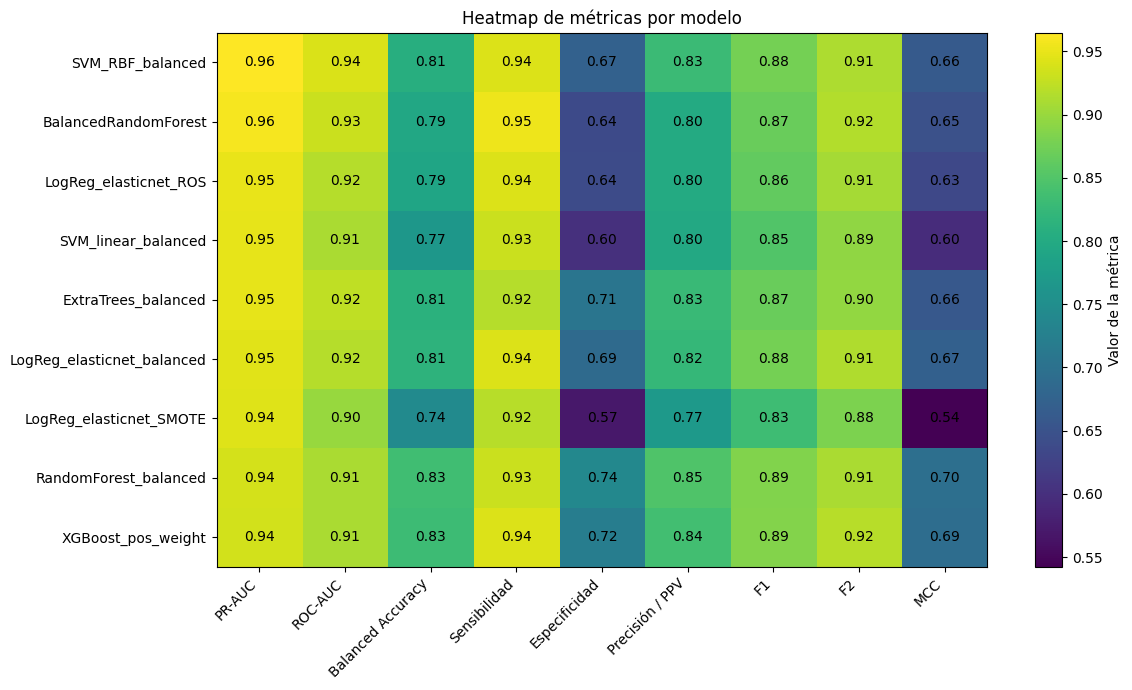

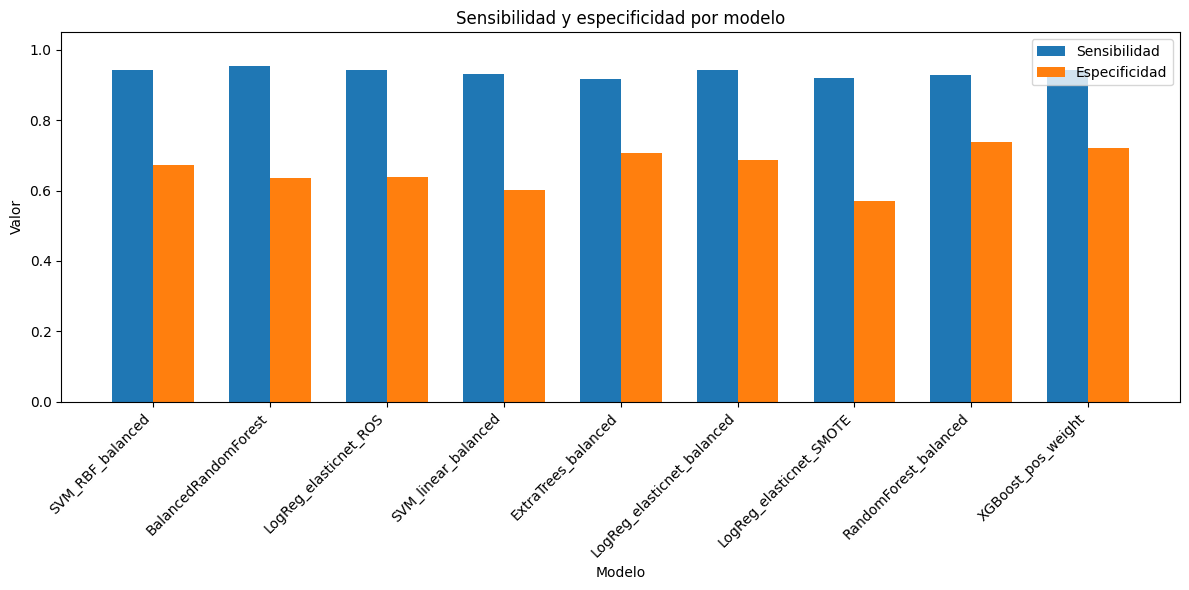

Figuras guardadas en: /content/drive/MyDrive/radiomica_semana_1/figures


In [ ]:
# ============================================================
# 19.4) GRÁFICOS COMPARATIVOS DE MÉTRICAS ENTRE MODELOS
# ============================================================

if "model_comparison_table" not in globals() or model_comparison_table is None or len(model_comparison_table) == 0:
    raise ValueError("No existe model_comparison_table. Ejecuta entrenamiento o recarga checkpoints primero.")

metric_map = {
    "roc_auc_mean": "ROC-AUC",
    "pr_auc_mean": "PR-AUC",
    "accuracy_mean": "Accuracy",
    "balanced_accuracy_mean": "Balanced Accuracy",
    "precision_ppv_mean": "Precisión / PPV",
    "sensitivity_recall_mean": "Sensibilidad",
    "specificity_mean": "Especificidad",
    "f1_mean": "F1",
    "f2_mean": "F2",
    "mcc_mean": "MCC",
    "brier_mean": "Brier"
}

available_metric_cols = [c for c in metric_map if c in model_comparison_table.columns]
metrics_plot_table = model_comparison_table[["model"] + available_metric_cols].copy()
metrics_plot_table = metrics_plot_table.rename(columns=metric_map)

if "PR-AUC" in metrics_plot_table.columns:
    metrics_plot_table = metrics_plot_table.sort_values("PR-AUC", ascending=False)
elif "ROC-AUC" in metrics_plot_table.columns:
    metrics_plot_table = metrics_plot_table.sort_values("ROC-AUC", ascending=False)

display(metrics_plot_table)

# AUC comparativo
auc_metrics = [m for m in ["ROC-AUC", "PR-AUC"] if m in metrics_plot_table.columns]
x = np.arange(len(metrics_plot_table))
width = 0.35

plt.figure(figsize=(12, 6))
for i, metric in enumerate(auc_metrics):
    offset = (i - (len(auc_metrics) - 1) / 2) * width
    plt.bar(x + offset, metrics_plot_table[metric], width=width, label=metric)

plt.xticks(x, metrics_plot_table["model"], rotation=45, ha="right")
plt.ylabel("Valor AUC")
plt.xlabel("Modelo")
plt.title("Comparación de ROC-AUC y PR-AUC por modelo")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
fig_auc_path = FIGURES_DIR_ENTREGA / "grafico_1_auc_modelos.png"
plt.savefig(fig_auc_path, dpi=300, bbox_inches="tight")
plt.show()

# Heatmap
metrics_to_plot = [
    "PR-AUC", "ROC-AUC", "Balanced Accuracy",
    "Sensibilidad", "Especificidad", "Precisión / PPV", "F1", "F2", "MCC"
]
metrics_to_plot = [m for m in metrics_to_plot if m in metrics_plot_table.columns]
heat_df = metrics_plot_table.set_index("model")[metrics_to_plot].copy()

plt.figure(figsize=(12, 7))
plt.imshow(heat_df.values, aspect="auto")
plt.xticks(np.arange(len(heat_df.columns)), heat_df.columns, rotation=45, ha="right")
plt.yticks(np.arange(len(heat_df.index)), heat_df.index)
plt.colorbar(label="Valor de la métrica")
plt.title("Heatmap de métricas por modelo")

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        value = heat_df.values[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.tight_layout()
fig_heatmap_path = FIGURES_DIR_ENTREGA / "grafico_2_heatmap_metricas_modelos.png"
plt.savefig(fig_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

# Sensibilidad vs especificidad
if "Sensibilidad" in metrics_plot_table.columns and "Especificidad" in metrics_plot_table.columns:
    x = np.arange(len(metrics_plot_table))
    width = 0.35
    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, metrics_plot_table["Sensibilidad"], width, label="Sensibilidad")
    plt.bar(x + width/2, metrics_plot_table["Especificidad"], width, label="Especificidad")
    plt.xticks(x, metrics_plot_table["model"], rotation=45, ha="right")
    plt.ylabel("Valor")
    plt.xlabel("Modelo")
    plt.title("Sensibilidad y especificidad por modelo")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    fig_sens_path = FIGURES_DIR_ENTREGA / "grafico_3_sensibilidad_especificidad_modelos.png"
    plt.savefig(fig_sens_path, dpi=300, bbox_inches="tight")
    plt.show()
else:
    fig_sens_path = None

metrics_plot_table.to_csv(TABLES_DIR_ENTREGA / "tabla_metricas_comparativas_modelos.csv", index=False)
print("Figuras guardadas en:", FIGURES_DIR_ENTREGA)

,model,c_index_mean,c_index_std,roc_auc_mean,pr_auc_mean,balanced_accuracy_mean,sensitivity_recall_mean,specificity_mean,mcc_mean
6,SVM_RBF_balanced,0.941533,0.053307,0.941533,0.964700,0.807605,0.942484,0.672727,0.662487
0,BalancedRandomForest,0.931655,0.035271,0.931655,0.958384,0.794979,0.953595,0.636364,0.646792
1,ExtraTrees_balanced,0.924540,0.051075,0.924540,0.949368,0.812181,0.918301,0.706061,0.658995
4,LogReg_elasticnet_balanced,0.917914,0.045300,0.917914,0.945928,0.814854,0.941830,0.687879,0.671455
2,LogReg_elasticnet_ROS,0.917380,0.043648,0.917380,0.951151,0.790612,0.941830,0.639394,0.633299
7,SVM_linear_balanced,0.911765,0.047484,0.911765,0.949748,0.766117,0.930719,0.601515,0.596111
5,RandomForest_balanced,0.911289,0.059531,0.911289,0.936711,0.834730,0.930065,0.739394,0.695778
8,XGBoost_pos_weight,0.910547,0.078891,0.910547,0.935865,0.831848,0.942484,0.721212,0.693497
3,LogReg_elasticnet_SMOTE,0.899851,0.043883,0.899851,0.944306,0.744326,0.918954,0.569697,0.542272


,model,threshold_mean,threshold_std,threshold_min,threshold_max
3,LogReg_elasticnet_SMOTE,0.188512,0.095060,0.029633,0.266826
2,LogReg_elasticnet_ROS,0.188733,0.072976,0.076006,0.246147
4,LogReg_elasticnet_balanced,0.264495,0.047839,0.214277,0.324665
7,SVM_linear_balanced,0.302446,0.160365,0.100007,0.470930
0,BalancedRandomForest,0.305747,0.037359,0.262141,0.357300
8,XGBoost_pos_weight,0.314186,0.099133,0.187541,0.449267
6,SVM_RBF_balanced,0.351617,0.155768,0.210659,0.592201
5,RandomForest_balanced,0.389392,0.031725,0.344175,0.419905
1,ExtraTrees_balanced,0.409861,0.057006,0.356991,0.490000


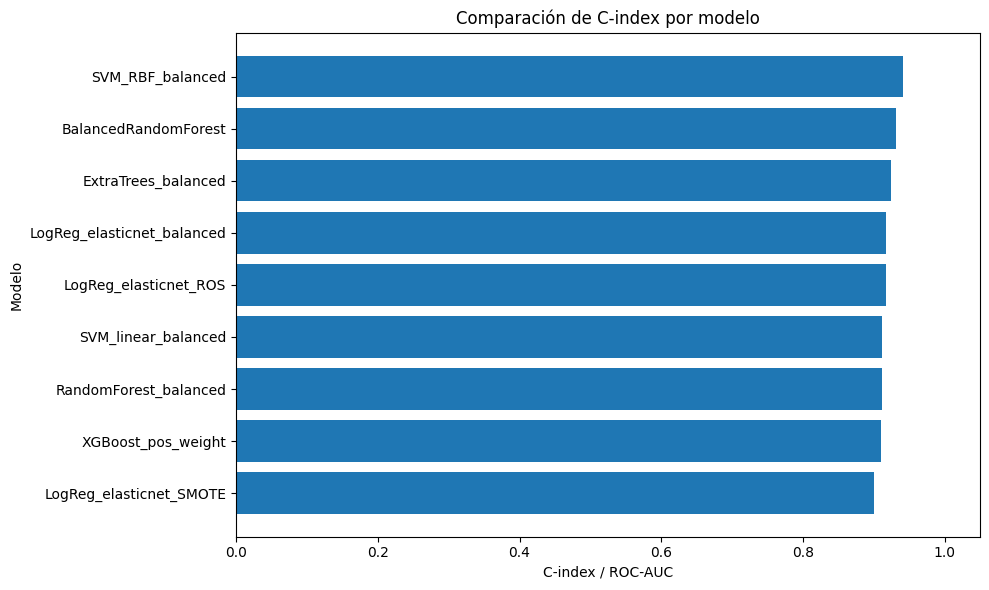

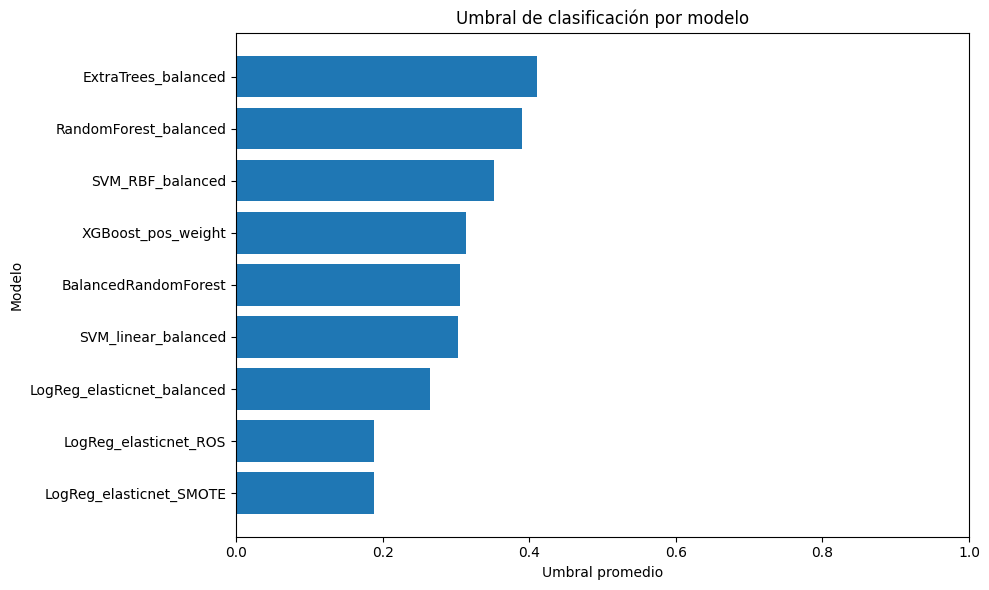

In [ ]:
# ============================================================
# 19.5) C-INDEX, UMBRALES Y GRÁFICOS DE UMBRAL
# ============================================================

# En clasificación binaria, el C-index es equivalente al ROC-AUC.
cindex_table = model_comparison_table.copy()

if "roc_auc_mean" in cindex_table.columns:
    cindex_table["c_index_mean"] = cindex_table["roc_auc_mean"]
if "roc_auc_std" in cindex_table.columns:
    cindex_table["c_index_std"] = cindex_table["roc_auc_std"]

cols_cindex = ["model"]
for c in [
    "c_index_mean", "c_index_std",
    "roc_auc_mean", "pr_auc_mean",
    "balanced_accuracy_mean",
    "sensitivity_recall_mean", "specificity_mean", "mcc_mean"
]:
    if c in cindex_table.columns:
        cols_cindex.append(c)

cindex_table = cindex_table[cols_cindex]
if "c_index_mean" in cindex_table.columns:
    cindex_table = cindex_table.sort_values("c_index_mean", ascending=False)

display(cindex_table)

if "fold_metrics_ok" in globals() and "threshold" in fold_metrics_ok.columns:
    threshold_table = (
        fold_metrics_ok
        .groupby("model")
        .agg(
            threshold_mean=("threshold", "mean"),
            threshold_std=("threshold", "std"),
            threshold_min=("threshold", "min"),
            threshold_max=("threshold", "max")
        )
        .reset_index()
        .sort_values("threshold_mean", ascending=True)
    )
else:
    threshold_table = latex_equations_table[["model", "threshold"]].rename(columns={"threshold": "threshold_mean"})

display(threshold_table)

# Gráfico C-index
if "c_index_mean" in cindex_table.columns:
    plot_df = cindex_table.sort_values("c_index_mean", ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["model"], plot_df["c_index_mean"])
    plt.xlabel("C-index / ROC-AUC")
    plt.ylabel("Modelo")
    plt.title("Comparación de C-index por modelo")
    plt.xlim(0, 1.05)
    plt.tight_layout()
    path_cindex = THRESHOLD_DIR_ENTREGA / "cindex_por_modelo.png"
    plt.savefig(path_cindex, dpi=300, bbox_inches="tight")
    plt.show()

# Gráfico umbrales
plt.figure(figsize=(10, 6))
plt.barh(threshold_table["model"], threshold_table["threshold_mean"])
plt.xlabel("Umbral promedio")
plt.ylabel("Modelo")
plt.title("Umbral de clasificación por modelo")
plt.xlim(0, 1)
plt.tight_layout()
path_thresholds = THRESHOLD_DIR_ENTREGA / "umbrales_por_modelo.png"
plt.savefig(path_thresholds, dpi=300, bbox_inches="tight")
plt.show()

cindex_table.to_csv(THRESHOLD_DIR_ENTREGA / "cindex_por_modelo.csv", index=False)
threshold_table.to_csv(THRESHOLD_DIR_ENTREGA / "umbrales_por_modelo.csv", index=False)

Calculando OOF: BalancedRandomForest
Calculando OOF: ExtraTrees_balanced
Calculando OOF: LogReg_elasticnet_ROS
Calculando OOF: LogReg_elasticnet_SMOTE
Calculando OOF: LogReg_elasticnet_balanced
Calculando OOF: RandomForest_balanced
Calculando OOF: SVM_RBF_balanced
Calculando OOF: SVM_linear_balanced
Calculando OOF: XGBoost_pos_weight


,row_index,model,y_true,score
0,0,BalancedRandomForest,1,0.601633
1,1,BalancedRandomForest,1,0.810253
2,2,BalancedRandomForest,1,0.647674
3,3,BalancedRandomForest,1,0.522009
4,4,BalancedRandomForest,1,0.793285


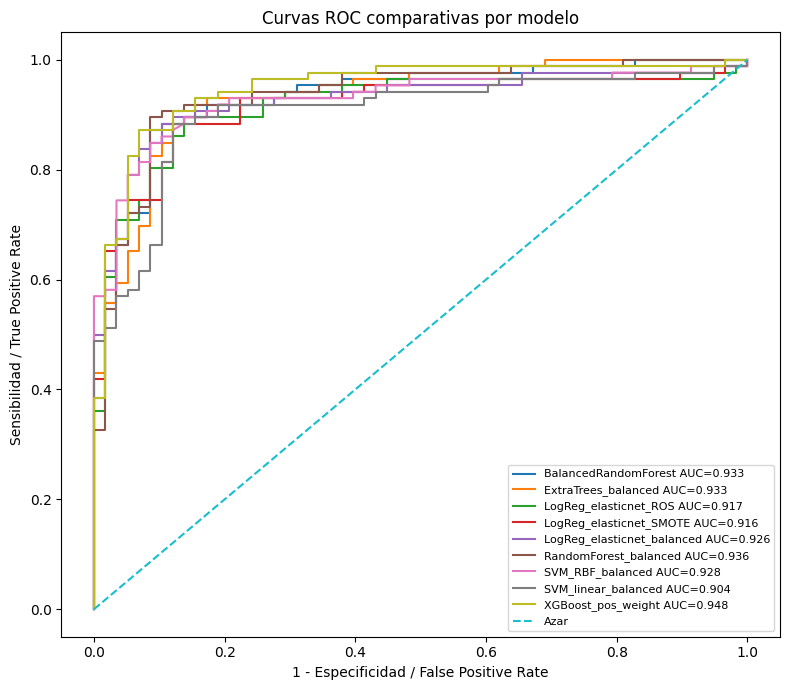

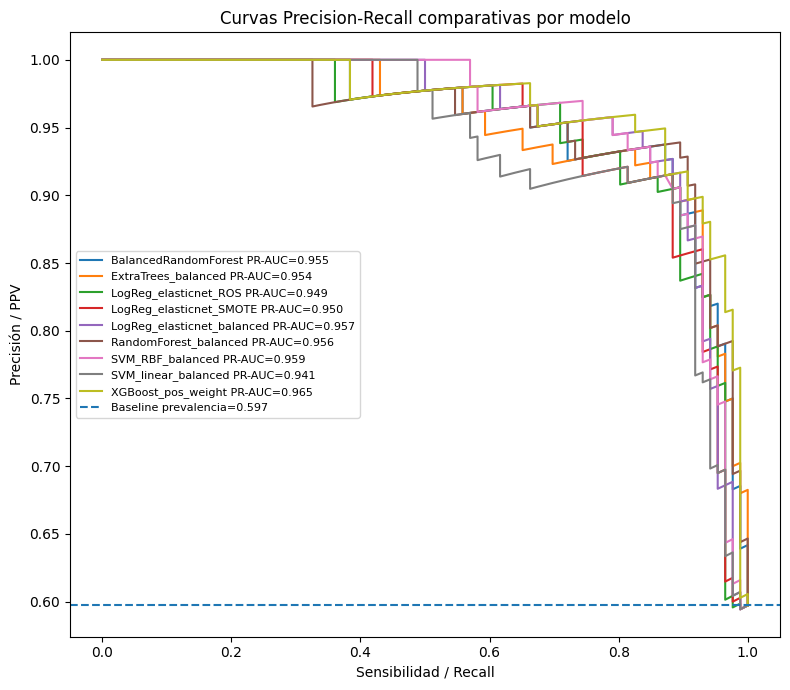

,model,optimized_metric,best_threshold,best_metric_value,sensitivity,specificity,precision,f1,f2,mcc,c_index,pr_auc
0,BalancedRandomForest,balanced_accuracy,0.52,0.892943,0.872093,0.913793,0.937500,0.903614,0.884434,0.775689,0.932839,0.955192
1,BalancedRandomForest,f1,0.48,0.904762,0.883721,0.896552,0.926829,0.904762,0.892019,0.772871,0.932839,0.955192
2,BalancedRandomForest,f2,0.32,0.924276,0.965116,0.620690,0.790476,0.869110,0.924276,0.646532,0.932839,0.955192
3,BalancedRandomForest,mcc,0.52,0.775689,0.872093,0.913793,0.937500,0.903614,0.884434,0.775689,0.932839,0.955192
4,ExtraTrees_balanced,balanced_accuracy,0.46,0.881516,0.883721,0.879310,0.915663,0.899408,0.889930,0.757359,0.932638,0.954259
5,ExtraTrees_balanced,f1,0.41,0.903955,0.930233,0.810345,0.879121,0.903955,0.919540,0.753139,0.932638,0.954259
6,ExtraTrees_balanced,f2,0.30,0.921053,0.976744,0.517241,0.750000,0.848485,0.921053,0.582765,0.932638,0.954259
7,ExtraTrees_balanced,mcc,0.46,0.757359,0.883721,0.879310,0.915663,0.899408,0.889930,0.757359,0.932638,0.954259
8,LogReg_elasticnet_ROS,balanced_accuracy,0.41,0.878709,0.895349,0.862069,0.905882,0.900585,0.897436,0.755376,0.916800,0.949283
9,LogReg_elasticnet_ROS,f1,0.41,0.900585,0.895349,0.862069,0.905882,0.900585,0.897436,0.755376,0.916800,0.949283


In [ ]:
# ============================================================
# 19.6) CURVAS ROC, PR Y MÉTRICAS POR UMBRAL CON OOF
# ============================================================

from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

if "X_final" not in globals() or "y_final" not in globals():
    raise ValueError("Necesitas X_final y y_final. Ejecuta primero la preparación del dataset.")

if "final_model_objects" not in globals() or len(final_model_objects) == 0:
    raise ValueError("Necesitas final_model_objects. Entrena o recarga modelos primero.")

min_class_count_oof = min(int((y_final == 0).sum()), int((y_final == 1).sum()))
N_SPLITS_OOF = min(5, min_class_count_oof)

cv_oof = StratifiedKFold(n_splits=N_SPLITS_OOF, shuffle=True, random_state=RANDOM_STATE)


def get_oof_score(model, X, y):
    if hasattr(model, "predict_proba"):
        return cross_val_predict(clone(model), X, y, cv=cv_oof, method="predict_proba", n_jobs=-1)[:, 1]
    if hasattr(model, "decision_function"):
        scores = cross_val_predict(clone(model), X, y, cv=cv_oof, method="decision_function", n_jobs=-1)
        return 1 / (1 + np.exp(-np.asarray(scores)))
    return cross_val_predict(clone(model), X, y, cv=cv_oof, method="predict", n_jobs=-1)

oof_path = THRESHOLD_DIR_ENTREGA / "oof_predictions_por_modelo.csv"

if oof_path.exists():
    oof_predictions_table = pd.read_csv(oof_path)
else:
    oof_rows = []
    for model_name, model in final_model_objects.items():
        print("Calculando OOF:", model_name)
        try:
            scores = get_oof_score(model, X_final, y_final)
            for i, s in enumerate(scores):
                oof_rows.append({
                    "row_index": i,
                    "model": model_name,
                    "y_true": int(np.asarray(y_final)[i]),
                    "score": float(s)
                })
        except Exception as e:
            print("Error en modelo:", model_name, e)
    oof_predictions_table = pd.DataFrame(oof_rows)
    oof_predictions_table.to_csv(oof_path, index=False)

display(oof_predictions_table.head())

# Curvas ROC
plt.figure(figsize=(8, 7))
for model_name in oof_predictions_table["model"].unique():
    tmp = oof_predictions_table[oof_predictions_table["model"] == model_name]
    y_true = tmp["y_true"].values
    score = tmp["score"].values
    fpr, tpr, _ = roc_curve(y_true, score)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} AUC={roc_auc_val:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("1 - Especificidad / False Positive Rate")
plt.ylabel("Sensibilidad / True Positive Rate")
plt.title("Curvas ROC comparativas por modelo")
plt.legend(fontsize=8)
plt.tight_layout()
roc_curve_path = FIGURES_DIR_ENTREGA / "curvas_roc_todos_modelos.png"
plt.savefig(roc_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# Curvas PR
plt.figure(figsize=(8, 7))
for model_name in oof_predictions_table["model"].unique():
    tmp = oof_predictions_table[oof_predictions_table["model"] == model_name]
    y_true = tmp["y_true"].values
    score = tmp["score"].values
    precision, recall, _ = precision_recall_curve(y_true, score)
    pr_auc_val = average_precision_score(y_true, score)
    plt.plot(recall, precision, label=f"{model_name} PR-AUC={pr_auc_val:.3f}")
baseline = oof_predictions_table["y_true"].mean()
plt.axhline(baseline, linestyle="--", label=f"Baseline prevalencia={baseline:.3f}")
plt.xlabel("Sensibilidad / Recall")
plt.ylabel("Precisión / PPV")
plt.title("Curvas Precision-Recall comparativas por modelo")
plt.legend(fontsize=8)
plt.tight_layout()
pr_curve_path = FIGURES_DIR_ENTREGA / "curvas_precision_recall_todos_modelos.png"
plt.savefig(pr_curve_path, dpi=300, bbox_inches="tight")
plt.show()

# Métricas por umbral
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, precision_score, f1_score, fbeta_score, matthews_corrcoef


def metrics_at_threshold(y_true, score, threshold):
    y_pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return {
        "threshold": threshold,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "sensitivity": sens,
        "specificity": spec,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred) if len(np.unique(y_pred)) > 1 else 0
    }

threshold_grid = np.linspace(0.01, 0.99, 99)
all_threshold_rows = []

for model_name in oof_predictions_table["model"].unique():
    tmp = oof_predictions_table[oof_predictions_table["model"] == model_name]
    y_true = tmp["y_true"].values
    score = tmp["score"].values
    c_index = roc_auc_score(y_true, score)
    pr_auc_val = average_precision_score(y_true, score)
    for thr in threshold_grid:
        row = metrics_at_threshold(y_true, score, thr)
        row["model"] = model_name
        row["c_index"] = c_index
        row["roc_auc"] = c_index
        row["pr_auc"] = pr_auc_val
        all_threshold_rows.append(row)

threshold_metrics_table = pd.DataFrame(all_threshold_rows)
threshold_metrics_table.to_csv(THRESHOLD_DIR_ENTREGA / "metricas_por_umbral_todos_modelos.csv", index=False)

# Mejor umbral por métrica
best_threshold_rows = []
for model_name in threshold_metrics_table["model"].unique():
    tmp = threshold_metrics_table[threshold_metrics_table["model"] == model_name].copy()
    for metric in ["balanced_accuracy", "f1", "f2", "mcc"]:
        best_row = tmp.sort_values(metric, ascending=False).iloc[0]
        best_threshold_rows.append({
            "model": model_name,
            "optimized_metric": metric,
            "best_threshold": best_row["threshold"],
            "best_metric_value": best_row[metric],
            "sensitivity": best_row["sensitivity"],
            "specificity": best_row["specificity"],
            "precision": best_row["precision"],
            "f1": best_row["f1"],
            "f2": best_row["f2"],
            "mcc": best_row["mcc"],
            "c_index": best_row["c_index"],
            "pr_auc": best_row["pr_auc"]
        })

best_threshold_table = pd.DataFrame(best_threshold_rows)
display(best_threshold_table)
best_threshold_table.to_csv(THRESHOLD_DIR_ENTREGA / "mejores_umbrales_por_modelo_y_metrica.csv", index=False)

In [ ]:
# ============================================================
# 19.7) FUNCIÓN PARA PREDECIR CASOS NUEVOS
# ============================================================


def get_score_model(model, X_new):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_new)[:, 1]
    if hasattr(model, "decision_function"):
        score = model.decision_function(X_new)
        return 1 / (1 + np.exp(-np.asarray(score)))
    return model.predict(X_new)


def preparar_casos_nuevos(df_new):
    df_new = df_new.copy()
    df_new.columns = [str(c).strip() for c in df_new.columns]

    for c in df_new.columns:
        df_new[c] = pd.to_numeric(df_new[c], errors="ignore")

    missing_cols = [c for c in feature_cols if c not in df_new.columns]
    extra_cols = [c for c in df_new.columns if c not in feature_cols]

    print("Features esperadas por el modelo:", len(feature_cols))
    print("Features recibidas:", df_new.shape[1])
    print("Features extra que se ignorarán:", len(extra_cols))
    print("Features faltantes:", len(missing_cols))

    if len(missing_cols) > 0:
        print("Primeras columnas faltantes:")
        print(missing_cols[:20])
        raise ValueError("Faltan características usadas en entrenamiento. No se debe predecir hasta completarlas.")

    X_new = df_new[feature_cols].copy()
    return X_new, extra_cols, missing_cols


def predecir_casos_nuevos(df_new):
    X_new, extra_cols, missing_cols = preparar_casos_nuevos(df_new)
    all_rows = []

    for model_name, model in final_model_objects.items():
        threshold = get_model_threshold(model_name)
        scores = get_score_model(model, X_new)

        for i, score in enumerate(scores):
            pred = int(score >= threshold)
            all_rows.append({
                "fila_caso_nuevo": i,
                "model": model_name,
                "score_probabilidad_caso": float(score),
                "threshold_umbral": float(threshold),
                "prediccion": pred,
                "interpretacion": "CASO / target 1" if pred == 1 else "CONTROL / target 0"
            })

    pred_table = pd.DataFrame(all_rows)

    resumen = (
        pred_table
        .groupby("fila_caso_nuevo")
        .agg(
            n_modelos=("model", "count"),
            modelos_predicen_caso=("prediccion", "sum"),
            score_promedio=("score_probabilidad_caso", "mean")
        )
        .reset_index()
    )
    resumen["modelos_predicen_control"] = resumen["n_modelos"] - resumen["modelos_predicen_caso"]
    resumen["decision_por_votacion"] = np.where(
        resumen["modelos_predicen_caso"] > resumen["modelos_predicen_control"],
        "CASO / target 1",
        "CONTROL / target 0"
    )
    return pred_table, resumen


print("Funciones listas. Para predecir un caso nuevo, usa la siguiente celda opcional.")

Funciones listas. Para predecir un caso nuevo, usa la siguiente celda opcional.


In [ ]:
# ============================================================
# 19.8) OPCIONAL: SUBIR CSV CON CASOS NUEVOS Y PREDECIR
# ============================================================

# Descomenta y ejecuta si tienes un CSV de casos nuevos.
# El archivo puede tener más columnas que el entrenamiento; las extras se ignoran.
# Pero NO deben faltar columnas usadas por el modelo.

# from google.colab import files
# uploaded_new = files.upload()
# new_csv = list(uploaded_new.keys())[0]
#
# try:
#     df_new = pd.read_csv(new_csv, sep=None, engine="python")
# except Exception:
#     df_new = pd.read_csv(new_csv, sep=";")
#
# if df_new.shape[1] == 1:
#     df_new = pd.read_csv(new_csv, sep=";")
#
# print("Dimensiones del archivo nuevo:", df_new.shape)
# display(df_new.head())
#
# predicciones_modelos, resumen_casos = predecir_casos_nuevos(df_new)
#
# print("Predicción por modelo:")
# display(predicciones_modelos)
#
# print("Resumen por votación:")
# display(resumen_casos)
#
# predicciones_modelos.to_csv(RESULTS_DIR_ENTREGA / "predicciones_casos_nuevos_por_modelo.csv", index=False)
# resumen_casos.to_csv(RESULTS_DIR_ENTREGA / "resumen_predicciones_casos_nuevos.csv", index=False)

In [ ]:
# ============================================================
# 19.9) ENTREGA FINAL: 5 CORRIDAS, TABLA FINAL, EXCEL Y README
# ============================================================

# Las 5 corridas corresponden a los 5 folds de validación cruzada estratificada.
metricas_5_corridas = fold_metrics_ok.copy()

if "fold" in metricas_5_corridas.columns:
    metricas_5_corridas = metricas_5_corridas.rename(columns={"fold": "corrida"})

if "corrida" not in metricas_5_corridas.columns:
    metricas_5_corridas["corrida"] = metricas_5_corridas.groupby("model").cumcount() + 1

cols_corridas = [
    "model", "corrida",
    "roc_auc", "pr_auc", "accuracy", "balanced_accuracy",
    "precision_ppv", "sensitivity_recall", "specificity",
    "f1", "f2", "mcc", "threshold",
    "tn", "fp", "fn", "tp"
]
cols_corridas = [c for c in cols_corridas if c in metricas_5_corridas.columns]
metricas_5_corridas = metricas_5_corridas[cols_corridas]

conteo_corridas = (
    metricas_5_corridas
    .groupby("model")
    .agg(n_corridas=("corrida", "count"))
    .reset_index()
)

print("Métricas de 5 corridas/folds:")
display(metricas_5_corridas)
print("Conteo de corridas por modelo:")
display(conteo_corridas)

tabla_resultados_final = model_comparison_table.copy()
cols_finales = [
    "model",
    "pr_auc_mean", "pr_auc_std",
    "roc_auc_mean", "roc_auc_std",
    "accuracy_mean", "accuracy_std",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "precision_ppv_mean", "precision_ppv_std",
    "sensitivity_recall_mean", "sensitivity_recall_std",
    "specificity_mean", "specificity_std",
    "f1_mean", "f1_std",
    "f2_mean", "f2_std",
    "mcc_mean", "mcc_std",
    "brier_mean", "brier_std"
]
cols_finales = [c for c in cols_finales if c in tabla_resultados_final.columns]
tabla_resultados_final = tabla_resultados_final[cols_finales]

if "pr_auc_mean" in tabla_resultados_final.columns:
    tabla_resultados_final = tabla_resultados_final.sort_values("pr_auc_mean", ascending=False)

metricas_5_corridas.to_csv(TABLES_DIR_ENTREGA / "metricas_5_corridas.csv", index=False)
tabla_resultados_final.to_csv(TABLES_DIR_ENTREGA / "tabla_resultados_final_modelos.csv", index=False)

excel_final = RESULTS_DIR_ENTREGA / "entrega_completa_radiomica.xlsx"

with pd.ExcelWriter(excel_final, engine="openpyxl") as writer:
    # Tablas básicas si existen
    for sheet, obj_name in [
        ("balance_original", "balance_table"),
        ("calidad_datos", "quality_table"),
        ("familias_features", "family_count_table"),
        ("univariado", "univar_table"),
        ("univariado_familia", "family_univar_summary"),
    ]:
        if obj_name in globals() and isinstance(globals()[obj_name], pd.DataFrame) and len(globals()[obj_name]) > 0:
            globals()[obj_name].to_excel(writer, sheet_name=sheet[:31], index=False)

    metricas_5_corridas.to_excel(writer, sheet_name="metricas_5_corridas", index=False)
    conteo_corridas.to_excel(writer, sheet_name="conteo_corridas", index=False)
    tabla_resultados_final.to_excel(writer, sheet_name="resultados_modelos", index=False)

    for sheet, obj_name in [
        ("mejores_params_folds", "best_params_table"),
        ("params_finales", "final_params_table"),
        ("features_por_modelo", "features_by_model_table"),
        ("modelo_familia", "model_family_importance_table"),
        ("frecuencia_features", "feature_frequency_table"),
        ("ecuaciones_latex", "latex_equations_table"),
        ("c_index", "cindex_table"),
        ("umbrales", "threshold_table"),
        ("mejores_umbrales", "best_threshold_table"),
        ("metricas_comparativas", "metrics_plot_table"),
        ("modelo_familia_matriz", "model_family_count_matrix"),
    ]:
        if obj_name in globals() and isinstance(globals()[obj_name], pd.DataFrame) and len(globals()[obj_name]) > 0:
            globals()[obj_name].to_excel(writer, sheet_name=sheet[:31], index=False)

print("Excel final guardado en:", excel_final)

resumen_texto = f"""
# Resumen de entrega - Actividad práctica en clase

## Proyecto
Radiomics - Semana 1

## Estructura de carpetas
- data/
- results/
- figures/
- models/
- tables/
- reports/

## Reproducibilidad
Se implementó una función `set_seed()` para fijar la semilla aleatoria.

## Pipeline
El pipeline incluyó carga de datos, limpieza, imputación, escalado, selección de características, filtro de correlación, manejo del desbalance, entrenamiento de modelos, validación cruzada estratificada, registro de métricas, gráficos y exportación.

## 5 corridas
Las cinco corridas corresponden a los cinco folds de la validación cruzada estratificada.

## Métricas principales
PR-AUC, ROC-AUC/C-index, Balanced Accuracy, Sensibilidad, Especificidad, Precisión, F1, F2 y MCC.

## Nota metodológica
Debido al desbalance de clases, la accuracy no fue considerada como métrica principal. Se priorizó PR-AUC, sensibilidad, especificidad, balanced accuracy y MCC.
"""

readme_path = REPORTS_DIR_ENTREGA / "resumen_entrega_actividad.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(resumen_texto)

print("Resumen guardado en:", readme_path)
print(resumen_texto)

Métricas de 5 corridas/folds:


,model,corrida,roc_auc,pr_auc,accuracy,balanced_accuracy,precision_ppv,sensitivity_recall,specificity,f1,f2,mcc,threshold,tn,fp,fn,tp
0,BalancedRandomForest,1,0.904040,0.932781,0.862069,0.835859,0.850000,0.944444,0.727273,0.894737,0.923913,0.704503,0.357300,8,3,1,17
1,BalancedRandomForest,2,0.928922,0.956777,0.862069,0.857843,0.882353,0.882353,0.833333,0.882353,0.882353,0.715686,0.312000,10,2,2,15
2,BalancedRandomForest,3,0.990196,0.993808,0.827586,0.791667,0.772727,1.000000,0.583333,0.871795,0.944444,0.671385,0.277627,7,5,0,17
3,BalancedRandomForest,4,0.931373,0.955227,0.827586,0.791667,0.772727,1.000000,0.583333,0.871795,0.944444,0.671385,0.319667,7,5,0,17
4,BalancedRandomForest,5,0.903743,0.953326,0.750000,0.697861,0.727273,0.941176,0.454545,0.820513,0.888889,0.471003,0.262141,5,6,1,16
5,ExtraTrees_balanced,1,0.898990,0.931356,0.862069,0.835859,0.850000,0.944444,0.727273,0.894737,0.923913,0.704503,0.357816,8,3,1,17
6,ExtraTrees_balanced,2,0.950980,0.970110,0.862069,0.870098,0.933333,0.823529,0.916667,0.875000,0.843373,0.729545,0.441813,11,1,3,14
7,ExtraTrees_balanced,3,0.995098,0.996732,0.827586,0.791667,0.772727,1.000000,0.583333,0.871795,0.944444,0.671385,0.356991,7,5,0,17
8,ExtraTrees_balanced,4,0.916667,0.944926,0.827586,0.803922,0.800000,0.941176,0.666667,0.864865,0.909091,0.647098,0.402684,8,4,1,16
9,ExtraTrees_balanced,5,0.860963,0.903715,0.785714,0.759358,0.789474,0.882353,0.636364,0.833333,0.862069,0.542441,0.490000,7,4,2,15


Conteo de corridas por modelo:


,model,n_corridas
0,BalancedRandomForest,5
1,ExtraTrees_balanced,5
2,LogReg_elasticnet_ROS,5
3,LogReg_elasticnet_SMOTE,5
4,LogReg_elasticnet_balanced,5
5,RandomForest_balanced,5
6,SVM_RBF_balanced,5
7,SVM_linear_balanced,5
8,XGBoost_pos_weight,5


Excel final guardado en: /content/drive/MyDrive/radiomica_semana_1/results/entrega_completa_radiomica.xlsx
Resumen guardado en: /content/drive/MyDrive/radiomica_semana_1/reports/resumen_entrega_actividad.md

# Resumen de entrega - Actividad práctica en clase

## Proyecto
Radiomics - Semana 1

## Estructura de carpetas
- data/
- results/
- figures/
- models/
- tables/
- reports/

## Reproducibilidad
Se implementó una función `set_seed()` para fijar la semilla aleatoria.

## Pipeline
El pipeline incluyó carga de datos, limpieza, imputación, escalado, selección de características, filtro de correlación, manejo del desbalance, entrenamiento de modelos, validación cruzada estratificada, registro de métricas, gráficos y exportación.

## 5 corridas
Las cinco corridas corresponden a los cinco folds de la validación cruzada estratificada.

## Métricas principales
PR-AUC, ROC-AUC/C-index, Balanced Accuracy, Sensibilidad, Especificidad, Precisión, F1, F2 y MCC.

## Nota metodológica
Debido al des

In [ ]:
# ============================================================
# 19.10) DESCARGAR ARCHIVOS PRINCIPALES
# ============================================================

from google.colab import files

files.download(str(excel_final))
files.download(str(fig_auc_path))
files.download(str(fig_heatmap_path))

if "fig_sens_path" in globals() and fig_sens_path is not None:
    files.download(str(fig_sens_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Interpretación rápida para el informe

- Las **5 corridas** son los 5 folds de validación cruzada estratificada.  
- En clasificación binaria, el **C-index** es equivalente al **ROC-AUC**.  
- En datos desbalanceados, la métrica principal debe ser **PR-AUC**, no accuracy.  
- Para modelos no lineales, la predicción se reporta como score/probabilidad comparada con un umbral:  

```latex
\hat{y}=1 \quad 	ext{si} \quad p_{modelo}(x) \geq 	au
```

In [ ]:
# ============================================================
# AUDITORÍA: NÚMERO REAL DE VARIABLES USADAS POR CADA MODELO
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

def get_feature_names_after_pipeline_safe(fitted_pipe, original_feature_names):
    """
    Recupera los nombres de features que llegan realmente al modelo
    después de VarianceThreshold, SelectKBest y CorrelationFilter.
    """
    names = np.array(original_feature_names)

    if "variance" in fitted_pipe.named_steps:
        vt = fitted_pipe.named_steps["variance"]
        if hasattr(vt, "get_support"):
            names = names[vt.get_support()]

    if "select" in fitted_pipe.named_steps:
        sel = fitted_pipe.named_steps["select"]
        if hasattr(sel, "get_support"):
            names = names[sel.get_support()]

    if "corr" in fitted_pipe.named_steps:
        corr = fitted_pipe.named_steps["corr"]
        if hasattr(corr, "keep_mask_"):
            names = names[corr.keep_mask_]

    return list(names)


audit_rows = []

for model_name, pipe in final_model_objects.items():

    selected_k = None
    corr_threshold = None

    if "select" in pipe.named_steps:
        selected_k = pipe.named_steps["select"].k

    if "corr" in pipe.named_steps:
        corr_threshold = pipe.named_steps["corr"].threshold

    final_features = get_feature_names_after_pipeline_safe(pipe, feature_cols)

    audit_rows.append({
        "model": model_name,
        "features_originales": len(feature_cols),
        "select_k_elegido": selected_k,
        "corr_threshold_elegido": corr_threshold,
        "features_finales_usadas": len(final_features),
        "features_finales": ", ".join(final_features)
    })

audit_features_table = pd.DataFrame(audit_rows)

display(audit_features_table)

,model,features_originales,select_k_elegido,corr_threshold_elegido,features_finales_usadas,features_finales
0,BalancedRandomForest,107,75,0.85,29,"1_shape_elongation, 1_shape_flatness, 1_shape_..."
1,ExtraTrees_balanced,107,75,0.90,38,"1_shape_elongation, 1_shape_flatness, 1_shape_..."
2,LogReg_elasticnet_ROS,107,30,0.95,19,"1_shape_flatness, 1_shape_majoraxislength, 1_s..."
3,LogReg_elasticnet_SMOTE,107,30,0.90,14,"1_shape_flatness, 1_shape_majoraxislength, 1_s..."
4,LogReg_elasticnet_balanced,107,50,0.90,22,"1_shape_elongation, 1_shape_flatness, 1_shape_..."
5,RandomForest_balanced,107,75,0.90,38,"1_shape_elongation, 1_shape_flatness, 1_shape_..."
6,SVM_RBF_balanced,107,50,0.90,22,"1_shape_elongation, 1_shape_flatness, 1_shape_..."
7,SVM_linear_balanced,107,30,0.95,19,"1_shape_flatness, 1_shape_majoraxislength, 1_s..."
8,XGBoost_pos_weight,107,75,0.90,38,"1_shape_elongation, 1_shape_flatness, 1_shape_..."


In [ ]:
# ============================================================
# CORRELACIÓN ENTRE FEATURES ANTES Y DESPUÉS DEL FILTRO
# ============================================================

corr_audit_rows = []

for model_name, pipe in final_model_objects.items():

    final_features = get_feature_names_after_pipeline_safe(pipe, feature_cols)

    # Correlación en todas las features originales
    corr_original = X_final[feature_cols].corr().abs()
    upper_original = corr_original.where(
        np.triu(np.ones(corr_original.shape), k=1).astype(bool)
    )

    n_corr_original_090 = int((upper_original > 0.90).sum().sum())
    n_corr_original_095 = int((upper_original > 0.95).sum().sum())

    # Correlación en features finales del modelo
    if len(final_features) > 1:
        corr_final = X_final[final_features].corr().abs()
        upper_final = corr_final.where(
            np.triu(np.ones(corr_final.shape), k=1).astype(bool)
        )

        n_corr_final_090 = int((upper_final > 0.90).sum().sum())
        n_corr_final_095 = int((upper_final > 0.95).sum().sum())
        max_corr_final = upper_final.max().max()
    else:
        n_corr_final_090 = 0
        n_corr_final_095 = 0
        max_corr_final = np.nan

    corr_audit_rows.append({
        "model": model_name,
        "n_features_finales": len(final_features),
        "pares_corr_original_mayor_090": n_corr_original_090,
        "pares_corr_original_mayor_095": n_corr_original_095,
        "pares_corr_final_mayor_090": n_corr_final_090,
        "pares_corr_final_mayor_095": n_corr_final_095,
        "max_corr_final": max_corr_final
    })

corr_audit_table = pd.DataFrame(corr_audit_rows)

display(corr_audit_table)

,model,n_features_finales,pares_corr_original_mayor_090,pares_corr_original_mayor_095,pares_corr_final_mayor_090,pares_corr_final_mayor_095,max_corr_final
0,BalancedRandomForest,29,189,111,0,0,0.826748
1,ExtraTrees_balanced,38,189,111,0,0,0.893505
2,LogReg_elasticnet_ROS,19,189,111,7,0,0.944014
3,LogReg_elasticnet_SMOTE,14,189,111,0,0,0.899100
4,LogReg_elasticnet_balanced,22,189,111,0,0,0.884473
5,RandomForest_balanced,38,189,111,0,0,0.893505
6,SVM_RBF_balanced,22,189,111,0,0,0.884473
7,SVM_linear_balanced,19,189,111,7,0,0.944014
8,XGBoost_pos_weight,38,189,111,0,0,0.893505


#uzziell

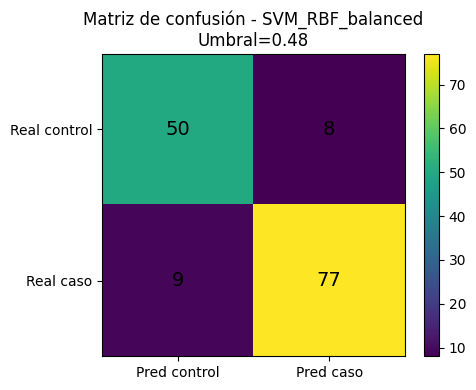

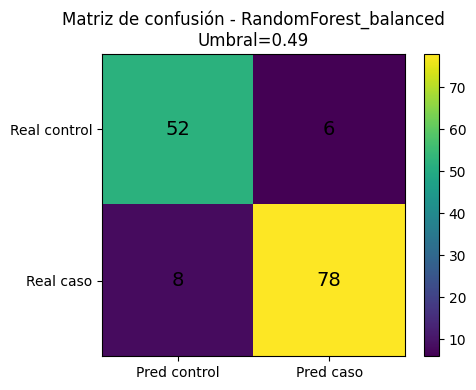

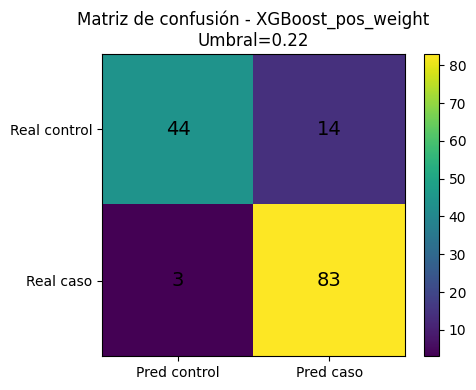

array([[44, 14],
       [ 3, 83]])

In [ ]:
# ============================================================
# MATRIZ DE CONFUSIÓN POR MODELO Y UMBRAL
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_from_oof(model_name, threshold):
    tmp = oof_predictions_table[oof_predictions_table["model"] == model_name].copy()

    y_true = tmp["y_true"].values
    score = tmp["score"].values
    y_pred = (score >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.xticks([0, 1], ["Pred control", "Pred caso"])
    plt.yticks([0, 1], ["Real control", "Real caso"])
    plt.title(f"Matriz de confusión - {model_name}\nUmbral={threshold:.2f}")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

    plt.colorbar()
    plt.tight_layout()
    plt.show()

    return cm

# Ejemplos según tus resultados:
plot_confusion_from_oof("SVM_RBF_balanced", 0.48)
plot_confusion_from_oof("RandomForest_balanced", 0.49)
plot_confusion_from_oof("XGBoost_pos_weight", 0.22)

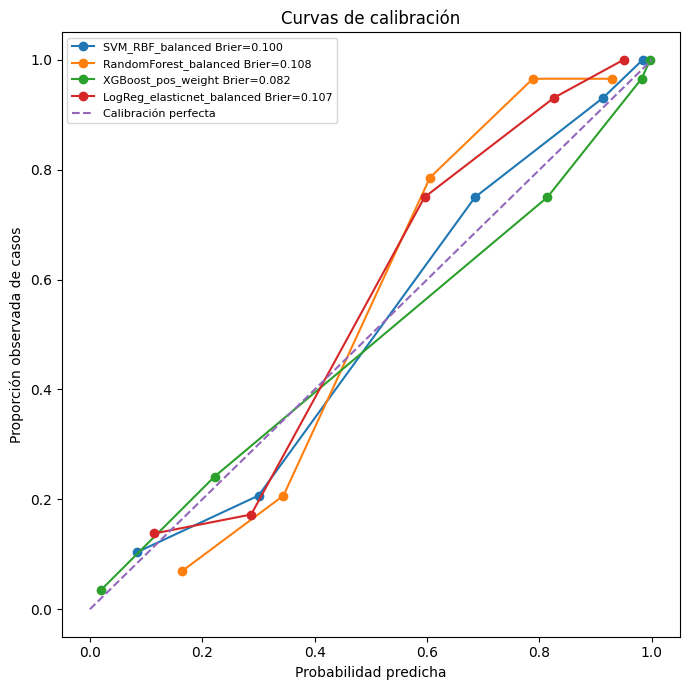

In [ ]:
# ============================================================
# CURVAS DE CALIBRACIÓN POR MODELO
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

modelos_calibracion = [
    "SVM_RBF_balanced",
    "RandomForest_balanced",
    "XGBoost_pos_weight",
    "LogReg_elasticnet_balanced"
]

plt.figure(figsize=(7, 7))

for model_name in modelos_calibracion:
    tmp = oof_predictions_table[oof_predictions_table["model"] == model_name]

    if len(tmp) == 0:
        continue

    y_true = tmp["y_true"].values
    score = tmp["score"].values

    prob_true, prob_pred = calibration_curve(y_true, score, n_bins=5, strategy="quantile")
    brier = brier_score_loss(y_true, score)

    plt.plot(prob_pred, prob_true, marker="o", label=f"{model_name} Brier={brier:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Proporción observada de casos")
plt.title("Curvas de calibración")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TOP FEATURES MÁS ESTABLES ENTRE MODELOS
# ============================================================

top_stable_features = feature_frequency_table.sort_values(
    ["n_models", "max_importance"],
    ascending=[False, False]
).head(20)

display(top_stable_features)

,feature,family,radiomic_characteristic,n_models,models,mean_importance,max_importance
41,6_gldm_dependenceentropy,gldm,dependenceentropy,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.721326,3.575185
1,1_shape_flatness,shape,flatness,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.604442,2.234392
11,2_firstorder_90percentile,firstorder,90percentile,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.424319,1.808021
30,4_glrlm_longrunlowgraylevelemphasis,glrlm,longrunlowgraylevelemphasis,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.339908,1.774400
5,1_shape_maximum2ddiameterslice,shape,maximum2ddiameterslice,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.343304,1.451571
10,2_firstorder_10percentile,firstorder,10percentile,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.390911,1.316076
3,1_shape_majoraxislength,shape,majoraxislength,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.251197,0.974981
22,3_glcm_correlation,glcm,correlation,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.198591,0.627803
12,2_firstorder_energy,firstorder,energy,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.136225,0.476289
38,5_glszm_sizezonenonuniformitynormalized,glszm,sizezonenonuniformitynormalized,8,"BalancedRandomForest, ExtraTrees_balanced, Log...",0.057889,0.142855


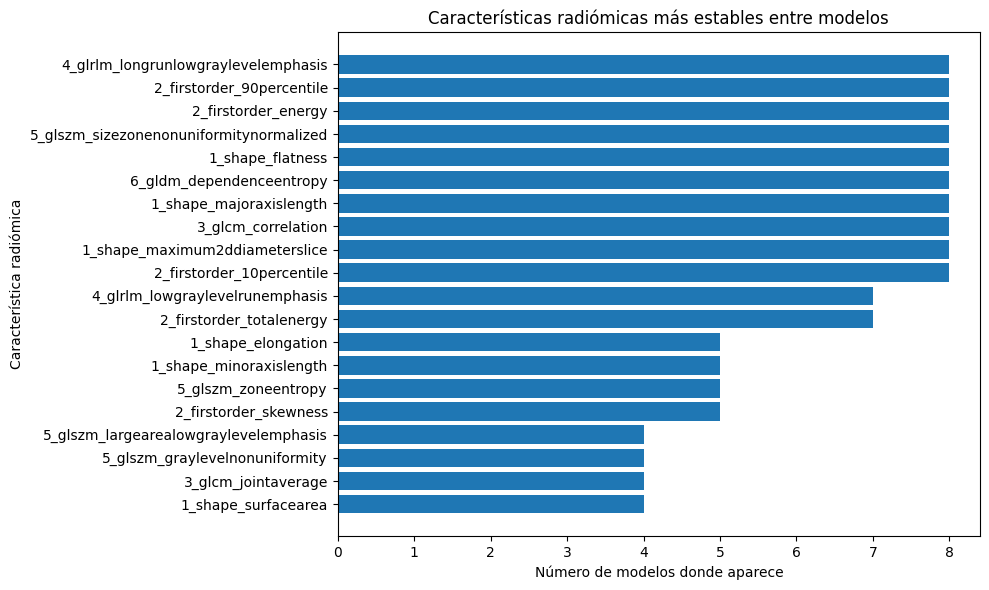

In [ ]:
plt.figure(figsize=(10, 6))
plot_df = top_stable_features.sort_values("n_models", ascending=True)

plt.barh(plot_df["feature"], plot_df["n_models"])
plt.xlabel("Número de modelos donde aparece")
plt.ylabel("Característica radiómica")
plt.title("Características radiómicas más estables entre modelos")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ESTABILIDAD GLOBAL DE FAMILIAS RADIÓMICAS
# ============================================================

family_stability_table = (
    family_counts_per_model_table
    .groupby("family")
    .agg(
        total_apariciones_top20=("n_features", "sum"),
        n_modelos_donde_aparece=("model", "nunique"),
        importancia_media=("mean_importance", "mean"),
        importancia_maxima=("max_importance", "max")
    )
    .reset_index()
    .sort_values(["n_modelos_donde_aparece", "total_apariciones_top20"], ascending=[False, False])
)

display(family_stability_table)

,family,total_apariciones_top20,n_modelos_donde_aparece,importancia_media,importancia_maxima
6,shape,46,8,0.373806,2.234392
0,firstorder,36,8,0.317109,2.035669
1,glcm,23,8,0.168094,1.582220
4,glszm,19,8,0.169091,2.337395
3,glrlm,17,8,0.351851,2.407996
2,gldm,8,8,0.721326,3.575185
5,ngtdm,3,3,0.016544,0.019170


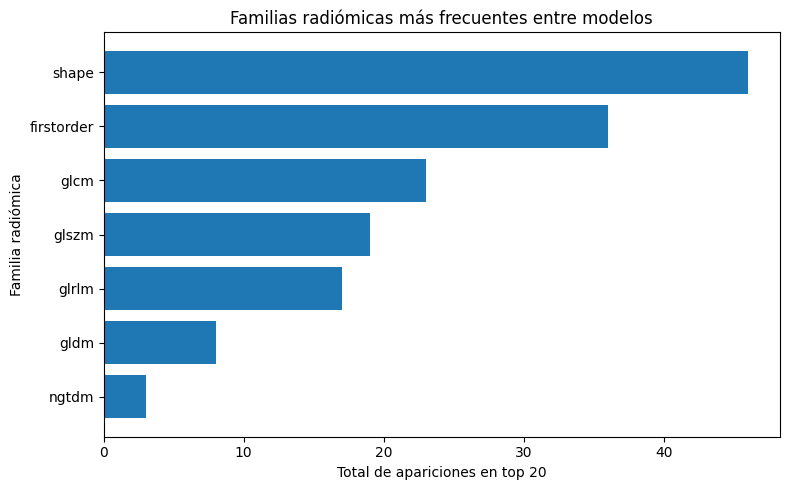

In [ ]:
plt.figure(figsize=(8, 5))
plot_df = family_stability_table.sort_values("total_apariciones_top20", ascending=True)

plt.barh(plot_df["family"], plot_df["total_apariciones_top20"])
plt.xlabel("Total de apariciones en top 20")
plt.ylabel("Familia radiómica")
plt.title("Familias radiómicas más frecuentes entre modelos")
plt.tight_layout()
plt.show()


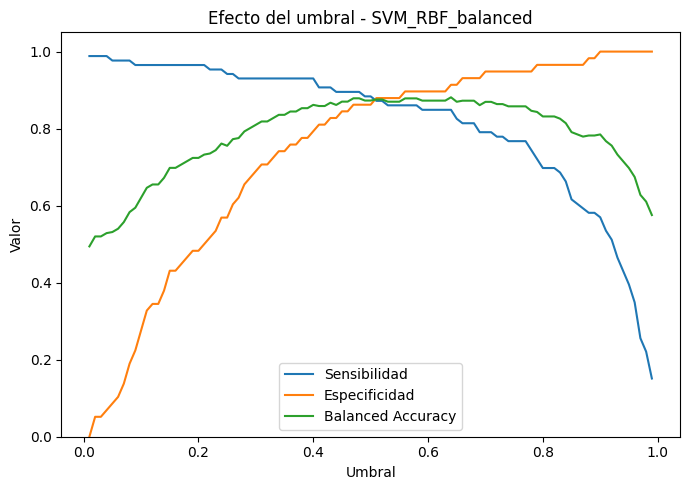

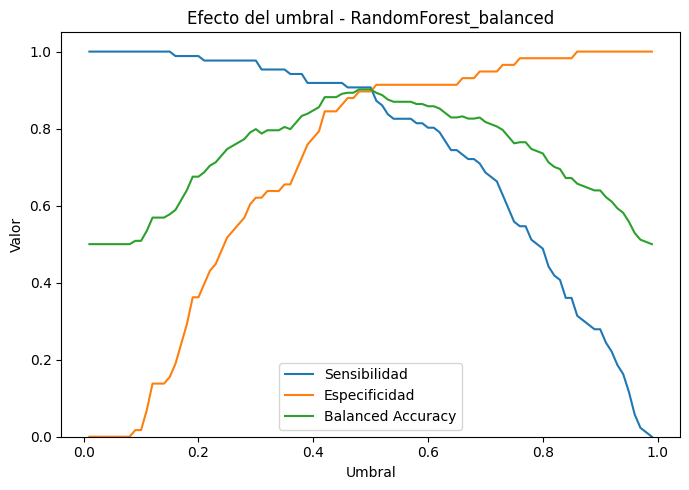

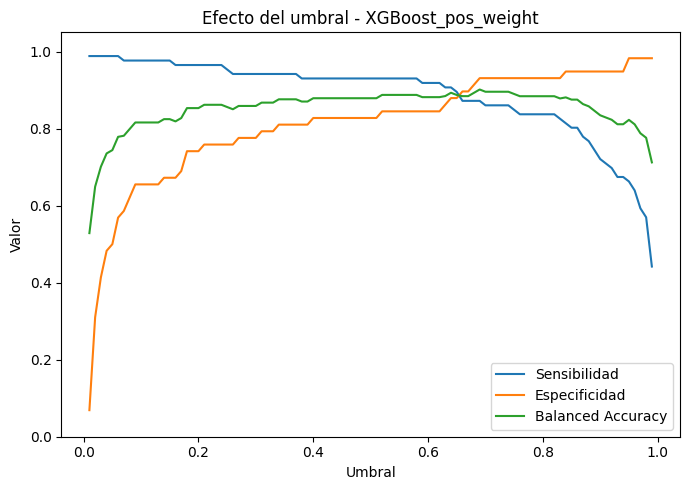

In [ ]:
# ============================================================
# SENSIBILIDAD Y ESPECIFICIDAD SEGÚN UMBRAL
# ============================================================

modelos_umbral = [
    "SVM_RBF_balanced",
    "RandomForest_balanced",
    "XGBoost_pos_weight"
]

for model_name in modelos_umbral:
    tmp = threshold_metrics_table[threshold_metrics_table["model"] == model_name]

    plt.figure(figsize=(7, 5))
    plt.plot(tmp["threshold"], tmp["sensitivity"], label="Sensibilidad")
    plt.plot(tmp["threshold"], tmp["specificity"], label="Especificidad")
    plt.plot(tmp["threshold"], tmp["balanced_accuracy"], label="Balanced Accuracy")

    plt.xlabel("Umbral")
    plt.ylabel("Valor")
    plt.title(f"Efecto del umbral - {model_name}")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
tabla_recomendacion = pd.DataFrame([
    {
        "objetivo": "Máxima detección de casos",
        "modelo_recomendado": "XGBoost_pos_weight",
        "umbral": 0.22,
        "justificacion": "Alta sensibilidad y F2; útil si se prioriza no perder casos."
    },
    {
        "objetivo": "Mejor equilibrio clínico",
        "modelo_recomendado": "RandomForest_balanced",
        "umbral": 0.49,
        "justificacion": "Buen balance entre sensibilidad, especificidad, F1 y MCC."
    },
    {
        "objetivo": "Mejor discriminación global",
        "modelo_recomendado": "SVM_RBF_balanced",
        "umbral": 0.48,
        "justificacion": "Mayor C-index/ROC-AUC promedio."
    },
    {
        "objetivo": "Mayor interpretabilidad",
        "modelo_recomendado": "LogReg_elasticnet_balanced",
        "umbral": 0.43,
        "justificacion": "Modelo lineal regularizado con coeficientes interpretables."
    }
])

display(tabla_recomendacion)

,objetivo,modelo_recomendado,umbral,justificacion
0,Máxima detección de casos,XGBoost_pos_weight,0.22,Alta sensibilidad y F2; útil si se prioriza no...
1,Mejor equilibrio clínico,RandomForest_balanced,0.49,"Buen balance entre sensibilidad, especificidad..."
2,Mejor discriminación global,SVM_RBF_balanced,0.48,Mayor C-index/ROC-AUC promedio.
3,Mayor interpretabilidad,LogReg_elasticnet_balanced,0.43,Modelo lineal regularizado con coeficientes in...


# SEMANA 3 — Validación y Consistencias Técnicas

Estas celdas completan específicamente los puntos solicitados en Semana 3 sin rehacer el pipeline base:
1. auditoría de data leakage;
2. consistencia entre particiones y semillas;
3. learning curve para diagnóstico de ajuste;
4. boxplot de métricas por fold;
5. explicabilidad SHAP;
6. auditoría de fairness (solo si existen variables sensibles);
7. exportación de evidencias para el reporte y peer review.

**Importante:** `seg_id` es un identificador de segmentación, no necesariamente un identificador de paciente. Si un paciente puede aparecer en más de una fila, se debe agregar `patient_id` y usar GroupKFold/StratifiedGroupKFold para evitar fuga entre pacientes.


In [ ]:
# ============================================================
# S3.1) AUDITORÍA DE DATASET Y DATA LEAKAGE
# ============================================================
import hashlib
from pathlib import Path
import pandas as pd
import numpy as np

# Hash de integridad del dataset
sha256 = hashlib.sha256()
with open(DATA_PATH, "rb") as f:
    for block in iter(lambda: f.read(1024 * 1024), b""):
        sha256.update(block)

dataset_audit = pd.DataFrame([
    {"control": "archivo", "resultado": DATA_PATH.name, "estado": "OK"},
    {"control": "SHA-256", "resultado": sha256.hexdigest(), "estado": "OK"},
    {"control": "filas", "resultado": int(df_raw.shape[0]), "estado": "OK"},
    {"control": "columnas", "resultado": int(df_raw.shape[1]), "estado": "OK"},
    {"control": "target", "resultado": TARGET_COL, "estado": "OK" if TARGET_COL in df_raw.columns else "REVISAR"},
    {"control": "faltantes totales", "resultado": int(df_raw.isna().sum().sum()), "estado": "OK"},
    {"control": "filas duplicadas exactas", "resultado": int(df_raw.duplicated().sum()), "estado": "OK" if int(df_raw.duplicated().sum()) == 0 else "REVISAR"},
])

if ID_COL is not None:
    dataset_audit.loc[len(dataset_audit)] = {
        "control": f"IDs únicos ({ID_COL})",
        "resultado": f"{df_raw[ID_COL].nunique()} / {len(df_raw)}",
        "estado": "OK" if df_raw[ID_COL].nunique() == len(df_raw) else "REVISAR"
    }

display(dataset_audit)

leakage_checklist = pd.DataFrame([
    {
        "verificacion": "Imputación ajustada solo en train",
        "evidencia": "SimpleImputer está dentro del Pipeline evaluado dentro de cada fold.",
        "estado": "CUMPLE"
    },
    {
        "verificacion": "Escalado ajustado solo en train",
        "evidencia": "RobustScaler está dentro del Pipeline evaluado dentro de cada fold.",
        "estado": "CUMPLE"
    },
    {
        "verificacion": "Selección de variables dentro del fold",
        "evidencia": "VarianceThreshold, SelectKBest y CorrelationFilter están dentro del Pipeline.",
        "estado": "CUMPLE"
    },
    {
        "verificacion": "Muestreo/desbalance dentro del fold",
        "evidencia": "Los samplers se ejecutan mediante imblearn Pipeline sobre el conjunto de entrenamiento.",
        "estado": "CUMPLE"
    },
    {
        "verificacion": "Optimización de hiperparámetros sin usar test externo",
        "evidencia": "Grid/RandomizedSearch se ejecuta en la CV interna del conjunto train.",
        "estado": "CUMPLE"
    },
    {
        "verificacion": "Umbral elegido sin usar el test externo",
        "evidencia": "El umbral se selecciona con predicciones del conjunto train/CV interna.",
        "estado": "CUMPLE"
    },
    {
        "verificacion": "Separación por paciente",
        "evidencia": "El dataset actual contiene seg_id, pero no se identificó una columna patient_id.",
        "estado": "VERIFICAR: si un paciente tiene varias filas, usar GroupKFold/StratifiedGroupKFold"
    }
])

display(leakage_checklist)

S3_DIR = Path(BASE_RESULTS_DIR) / "semana3"
S3_DIR.mkdir(parents=True, exist_ok=True)
dataset_audit.to_csv(S3_DIR / "auditoria_dataset.csv", index=False)
leakage_checklist.to_csv(S3_DIR / "evidencia_ausencia_leakage.csv", index=False)
print("Evidencias guardadas en:", S3_DIR)


In [ ]:
# ============================================================
# S3.2) CONSISTENCIA ENTRE SEMILLAS (5 seeds x 5 folds)
# ============================================================
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef,
    confusion_matrix
)

if "best_final_model" not in globals():
    if best_model_name in final_model_objects:
        best_final_model = final_model_objects[best_model_name]
    else:
        raise ValueError("No encuentro el mejor modelo final. Ejecuta entrenamiento o recarga checkpoints.")

SEEDS_S3 = [42, 52, 62, 72, 82]
seed_rows = []

for seed in SEEDS_S3:
    cv_seed = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    for fold, (tr_idx, te_idx) in enumerate(cv_seed.split(X_final, y_final), start=1):
        est = clone(best_final_model)

        # Cambiar random_state cuando exista en el estimador final.
        params = est.get_params(deep=True)
        random_state_params = {k: seed for k in params if k.endswith("random_state")}
        if random_state_params:
            est.set_params(**random_state_params)

        est.fit(X_final.iloc[tr_idx], y_final.iloc[tr_idx])
        scores = get_scores(est, X_final.iloc[te_idx])
        preds = (np.asarray(scores) >= 0.5).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_final.iloc[te_idx], preds, labels=[0, 1]
        ).ravel()

        seed_rows.append({
            "seed": seed,
            "fold": fold,
            "roc_auc": roc_auc_score(y_final.iloc[te_idx], scores),
            "pr_auc": average_precision_score(y_final.iloc[te_idx], scores),
            "balanced_accuracy": balanced_accuracy_score(y_final.iloc[te_idx], preds),
            "precision": precision_score(y_final.iloc[te_idx], preds, zero_division=0),
            "recall": recall_score(y_final.iloc[te_idx], preds, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "f1": f1_score(y_final.iloc[te_idx], preds, zero_division=0),
            "mcc": matthews_corrcoef(y_final.iloc[te_idx], preds),
        })

seed_stability_table = pd.DataFrame(seed_rows)

seed_summary_table = (
    seed_stability_table
    .groupby("seed")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        mcc_mean=("mcc", "mean"),
        mcc_std=("mcc", "std"),
    )
    .reset_index()
)

print("Consistencia del mejor modelo entre 5 semillas:")
display(seed_summary_table)

seed_stability_table.to_csv(S3_DIR / "estabilidad_5_seeds_x_5_folds.csv", index=False)
seed_summary_table.to_csv(S3_DIR / "resumen_estabilidad_por_seed.csv", index=False)


In [ ]:
# ============================================================
# S3.3) LEARNING CURVE — diagnóstico de overfitting/underfitting
# ============================================================
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.base import clone
import matplotlib.pyplot as plt

cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

sizes, train_scores, val_scores = learning_curve(
    clone(best_final_model),
    X_final,
    y_final,
    train_sizes=[0.60, 0.75, 0.90, 1.00],
    cv=cv_lc,
    scoring="average_precision",
    n_jobs=-1,
    error_score="raise"
)

learning_curve_table = pd.DataFrame({
    "n_train": sizes,
    "train_mean": train_scores.mean(axis=1),
    "train_std": train_scores.std(axis=1),
    "validation_mean": val_scores.mean(axis=1),
    "validation_std": val_scores.std(axis=1)
})

display(learning_curve_table)

plt.figure(figsize=(7, 5))
plt.plot(learning_curve_table["n_train"], learning_curve_table["train_mean"], marker="o", label="Train")
plt.plot(learning_curve_table["n_train"], learning_curve_table["validation_mean"], marker="o", label="Validación")
plt.fill_between(
    learning_curve_table["n_train"],
    learning_curve_table["train_mean"] - learning_curve_table["train_std"],
    learning_curve_table["train_mean"] + learning_curve_table["train_std"],
    alpha=0.15
)
plt.fill_between(
    learning_curve_table["n_train"],
    learning_curve_table["validation_mean"] - learning_curve_table["validation_std"],
    learning_curve_table["validation_mean"] + learning_curve_table["validation_std"],
    alpha=0.15
)
plt.xlabel("Número de muestras de entrenamiento")
plt.ylabel("PR-AUC")
plt.title(f"Learning curve — {best_model_name}")
plt.legend()
plt.tight_layout()

learning_curve_path = S3_DIR / "learning_curve_pr_auc.png"
plt.savefig(learning_curve_path, dpi=200, bbox_inches="tight")
plt.show()

gap_final = learning_curve_table.iloc[-1]["train_mean"] - learning_curve_table.iloc[-1]["validation_mean"]
if gap_final >= 0.10:
    ajuste_texto = "Se observa una brecha relevante train-validación, compatible con posible sobreajuste."
elif learning_curve_table.iloc[-1]["train_mean"] < 0.65 and learning_curve_table.iloc[-1]["validation_mean"] < 0.65:
    ajuste_texto = "Train y validación son bajos, compatible con posible subajuste."
else:
    ajuste_texto = "No se observa una brecha marcada entre train y validación; el ajuste es razonablemente consistente."

print("Interpretación:", ajuste_texto)
learning_curve_table.to_csv(S3_DIR / "learning_curve_pr_auc.csv", index=False)
with open(S3_DIR / "interpretacion_learning_curve.txt", "w", encoding="utf-8") as f:
    f.write(ajuste_texto)


In [ ]:
# ============================================================
# S3.4) BOXPLOT DE MÉTRICAS POR FOLD
# ============================================================
import matplotlib.pyplot as plt

if "fold_metrics_ok" not in globals() or len(fold_metrics_ok) == 0:
    raise ValueError("No se encontraron métricas por fold. Ejecuta entrenamiento o recarga checkpoints.")

best_fold_metrics = fold_metrics_ok[fold_metrics_ok["model"] == best_model_name].copy()

metrics_box = [c for c in ["roc_auc", "pr_auc", "balanced_accuracy", "f1", "mcc"] if c in best_fold_metrics.columns]
box_data = [best_fold_metrics[c].dropna().values for c in metrics_box]

plt.figure(figsize=(9, 5))
plt.boxplot(box_data, tick_labels=metrics_box)
plt.ylabel("Valor de la métrica")
plt.title(f"Variabilidad de métricas por fold — {best_model_name}")
plt.xticks(rotation=25)
plt.tight_layout()

boxplot_path = S3_DIR / "boxplot_metricas_por_fold.png"
plt.savefig(boxplot_path, dpi=200, bbox_inches="tight")
plt.show()

best_fold_metrics.to_csv(S3_DIR / "metricas_mejor_modelo_por_fold.csv", index=False)


In [ ]:
# ============================================================
# S3.5) EXPLICABILIDAD SHAP DEL MEJOR MODELO
# ============================================================
import shap
from sklearn.base import clone
import matplotlib.pyplot as plt

# El modelo final ya está ajustado con todos los datos.
model_for_shap = best_final_model

# Muestra pequeña para que la explicación sea reproducible y rápida.
background = X_final.sample(n=min(20, len(X_final)), random_state=42)
X_explain = X_final.sample(n=min(20, len(X_final)), random_state=52)

masker = shap.maskers.Independent(background, max_samples=min(20, len(background)))

def predict_positive_probability(arr):
    tmp = pd.DataFrame(arr, columns=X_final.columns)
    return model_for_shap.predict_proba(tmp)[:, 1]

explainer = shap.Explainer(
    predict_positive_probability,
    masker,
    algorithm="permutation",
    feature_names=list(X_final.columns)
)

shap_values = explainer(
    X_explain,
    max_evals=2 * X_final.shape[1] + 1
)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance_table = (
    pd.DataFrame({
        "feature": X_final.columns,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance_table.head(20))
shap_importance_table.to_csv(S3_DIR / "shap_importancia_global.csv", index=False)

plt.figure()
shap.plots.bar(shap_values, max_display=20, show=False)
plt.tight_layout()
shap_bar_path = S3_DIR / "shap_importancia_global.png"
plt.savefig(shap_bar_path, dpi=200, bbox_inches="tight")
plt.show()

print("Frase para el reporte:")
print(
    "El análisis SHAP identificó las variables con mayor contribución global a las predicciones; "
    "la figura resume la magnitud media de la contribución absoluta de cada característica."
)


In [ ]:
# ============================================================
# S3.6) FAIRNESS — auditoría básica si hay variables sensibles
# ============================================================
# Este dataset radiomics contiene seg_id, features radiómicas y target.
# No se deben inventar variables sensibles que no existen.

SENSITIVE_CANDIDATES = [
    "sex", "sexo", "gender", "genero", "género",
    "age", "edad", "ethnicity", "etnia"
]
sensitive_cols = [c for c in df_raw.columns if str(c).strip().lower() in SENSITIVE_CANDIDATES]

if len(sensitive_cols) == 0:
    fairness_table = pd.DataFrame([{
        "estado": "NO EVALUABLE CON EL DATASET ACTUAL",
        "motivo": (
            "El archivo analizado no contiene variables sensibles como sexo, edad o etnia. "
            "No es metodológicamente válido inventarlas. Para una auditoría de fairness por subgrupos, "
            "se requiere vincular metadatos clínicos anonimizados mediante un identificador permitido."
        ),
        "accion": (
            "Documentar esta limitación. Si se dispone de metadata clínica aprobada, "
            "evaluar sensibilidad/TPR y tasa de predicción favorable por subgrupo."
        )
    }])
else:
    fairness_table = pd.DataFrame([{
        "estado": "VARIABLES SENSIBLES DISPONIBLES",
        "motivo": ", ".join(sensitive_cols),
        "accion": "Ejecutar auditoría por subgrupos antes de la entrega."
    }])

display(fairness_table)
fairness_table.to_csv(S3_DIR / "fairness_auditoria.csv", index=False)


In [ ]:
# ============================================================
# S3.7) RESUMEN AUTOMÁTICO DE SEMANA 3
# ============================================================
summary_s3 = f"""
SEMANA 3 — VALIDACIÓN Y CONSISTENCIAS TÉCNICAS

Modelo principal: {best_model_name}

1. Validación cruzada:
   Se empleó validación cruzada estratificada y se reportaron métricas por fold con promedio y desviación estándar.

2. Data leakage:
   Imputación, escalado, selección de variables, filtrado por correlación y manejo del desbalance se encuentran dentro del pipeline.
   La optimización y la selección de umbral se realizan sobre datos de entrenamiento/CV interna.
   Debe verificarse que no existan múltiples filas del mismo paciente; el archivo actual solo expone seg_id.

3. Consistencia:
   Se añadió análisis de estabilidad con 5 semillas y 5 folds por semilla para el mejor modelo.

4. Diagnóstico de ajuste:
   {ajuste_texto}

5. Explicabilidad:
   Se generó importancia global SHAP del modelo principal.

6. Fairness:
   {fairness_table.iloc[0]['estado']}. {fairness_table.iloc[0]['motivo']}

7. Limitación:
   La validación actual es interna. Una validación externa multicéntrica debe considerarse como trabajo futuro cuando exista un dataset independiente.
"""

print(summary_s3)

with open(S3_DIR / "resumen_semana3.txt", "w", encoding="utf-8") as f:
    f.write(summary_s3)
